<a href="https://colab.research.google.com/github/BogdanT54/data-viz/blob/main/Proiect_Vizualizarea_Datelor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Analiza Macroeconomică a României în Context European (2000–2026)
### Disciplina: Vizualizarea Datelor
---
**Autor:** *Tofan Bogdan*  
**An universitar:** 2024–2025  

> *"România a crescut economic spectaculos în 25 de ani, dar această creștere este fragilă, inegală și demografic nesustenabilă."*


---
## 📌 PUNCTUL 1 - Semnificația temei, organizarea, relevanța și coerența datelor *(1.5p)*

### 1.1 Motivația alegerii temei

România a parcurs în ultimii 25 de ani una dintre cele mai spectaculoase transformări economice din Europa Centrală și de Est: de la o economie cu inflație de **45% în 2001** la una cu inflație sub 5% în 2024, de la un PIB/cap de **~$1.600** la peste **$20.000**. Această temă este relevantă din multiple perspective:

- **Istorică:** surprinde traiectoria de la tranziția post-comunistă la statutul de stat UE și convergența europeană
- **Financiară:** evidențiază stabilitatea monetară (EUR/RON), politica BNR, piața de capital și sustenabilitatea fiscală
- **Demografică:** radiografiază bomba cu ceas demografică - îmbătrânire + emigrație - care amenință tot restul

### 1.2 Structura narativă: 4 acte

| Act | Perioadă | Tema centrală |
|-----|----------|---------------|
| **I**   | 2000–2007 | Tranziția și pregătirea pentru UE - inflație mare, creștere rapidă |
| **II**  | 2007–2012 | Aderare UE, boom și criză financiară globală |
| **III** | 2012–2021 | Consolidare cu vulnerabilități - deficit, deficit, deficit |
| **IV**  | 2021–2026 | Inflație record, presiune demografică, piață de capital în expansiune |

### 1.3 Seturile de date utilizate

| Nr. | Fișier CSV | Conținut | Frecvență | Perioadă | Sursă |
|-----|-----------|----------|-----------|----------|-------|
| 1 | `pib_nominal_anual.csv` | PIB nominal USD, creștere %, PIB/cap | Anuală | 2000–2025 | World Bank |
| 2 | `pib_trimestrial.csv` | Indice volum PIB RO + Euro Area (2020=100) | Trimestrială | 2000–2026 | Eurostat |
| 3 | `ipc_lunar.csv` | IPC lunar față de luna anterioară (%) | Lunară | 2000–2026 | INS |
| 4 | `inflatie_anuala.csv` | Rata inflației anuale (%) | Anuală | 2000–2025 | INS |
| 5 | `dobanzi_bnr.csv` | Dobânda de politică monetară BNR (%) | Lunară | 2003–2026 | BNR |
| 6 | `hicp_lunar.csv` | HICP lunar RO și UE-27 (%) | Lunară | 2000–2025 | Eurostat |
| 7 | `curs_valutar.csv` | EUR/RON, EUR/PLN, EUR/HUF zilnic + indici | Zilnică | 2005–2026 | ECB / BNR |
| 8 | `somaj_trimestrial.csv` | Rata șomajului BIM pe trimestre (%) | Trimestrială | 2000–2026 | INS |
| 9 | `salariu_minim.csv` | Salariul minim brut/net (RON) | La modificare | 2005–2026 | Legislație |
| 10 | `castig_salarial_total.csv` | Câștigul salarial mediu net lunar (RON) | Lunară | 2000–2025 | INS |
| 11 | `deficit_bugetar.csv` | Deficit bugetar RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 12 | `datorie_publica.csv` | Datorie publică RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 13 | `randament_10y.csv` | Randament obligațiuni stat 10Y RO și UE | Lunară | 2005–2026 | Eurostat |
| 14 | `rezerve_bnr.csv` | Rezerve internaționale totale BNR (mil. EUR) | Lunară | 2005–2026 | BNR |
| 15 | `bet_zilnic.csv` | Indicele BET - prețuri zilnice (puncte) | Zilnică | 2010–2026 | BVB |
| 16 | `capitalizare_bvb.csv` | Capitalizare bursieră BVB (mld. RON) | Anuală | 2000–2026 | BVB |
| 17 | `pmi_lunar.csv` | PMI Manufacturing Eurozonă | Lunară | 2005–2025 | S&P Global |
| 18 | `natalitate.csv` | Rata natalității (‰) | Anuală | 2000–2024 | INS |
| 19 | `populatie_grupe_varsta.csv` | Populație pe grupe de vârstă și sex | Anuală | 2003–2025 | INS |
| 20 | `emigranti.csv` | Emigranți definitivi (nr. persoane) | Anuală | 2000–2024 | INS |
| 21 | `migratie_neta.csv` | Migrație netă anuală (nr. persoane) | Anuală | 2000–2024 | Eurostat |

### 1.4 Organizarea notebook-ului

Notebook-ul urmează o structură **tematică** cu 7 capitole analitice + 1 dashboard interactiv, totalizând **15 grafice**. Toate datele sunt reale, descărcate din surse oficiale (INS, BNR, Eurostat, BVB, ECB) și pre-procesate în format CSV uniform.

> **⚠️ Notă:** Plasați toate fișierele CSV în același director cu notebook-ul înainte de rulare.


---
## ⚙️ Setup - Biblioteci și Configurare Globală


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import ipywidgets as pyw
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("✓ Biblioteci importate cu succes.")

✓ Biblioteci importate cu succes.


In [ ]:
# ── Culori globale ──────────────────────────────────────────────
CUL = {
    'ro':      '#CC0000',
    'ue':      '#003399',
    'ea':      '#0066CC',
    'pln':     '#003087',
    'huf':     '#477050',
    'verde':   '#2E7D32',
    'rosu':    '#CC0000',
    'gri':     '#757575',
    'galben':  '#F9A825',
    'portoc':  '#E67E22',
}

# ── Ere istorice (pentru axele X anuale) ────────────────────────
ERE = [
    (2000, 2004, '#FFF3E0', 'Pre-UE'),
    (2004, 2007, '#E8F5E9', 'Negocieri'),
    (2007, 2009, '#E3F2FD', 'Post-aderare'),
    (2009, 2012, '#FFEBEE', 'Criză'),
    (2012, 2020, '#F3E5F5', 'Consolidare'),
    (2020, 2026, '#FFF8E1', 'Post-pandemic'),
]

FIGSIZE_W  = (18, 6)   # wide
FIGSIZE_SQ = (16, 7)   # standard

def adauga_ere(ax, ere=ERE, ymin=None, ymax=None):
    ylim = ax.get_ylim()
    y0 = ymin if ymin else ylim[0]
    y1 = ymax if ymax else ylim[1]
    for start, end, culoare, label in ere:
        ax.axvspan(start, end, alpha=0.25, color=culoare, zorder=0)
        ax.text((start+end)/2, y1, label, ha='center', va='top',
                fontsize=6.5, color='#555555', style='italic')

print("✓ Constante și funcții globale definite.")

✓ Constante și funcții globale definite.


---
## 📌 PUNCTUL 2 - Procesarea datelor în vederea vizualizării *(2p)*

Toate fișierele sunt în format CSV uniform - `pd.read_csv()` direct, fără procesare suplimentară. Coloanele de dată sunt parsate explicit, valorile numerice sunt verificate pentru NaN.


In [ ]:
# ── PIB ─────────────────────────────────────────────────────────
df_pib_nom = pd.read_csv('pib_nominal_anual.csv')
df_pib_nom = df_pib_nom.sort_values('an').reset_index(drop=True)

df_pib_trim = pd.read_csv('pib_trimestrial.csv')
df_pib_trim['data'] = pd.to_datetime(df_pib_trim['an'].astype(str) + '-' +
    df_pib_trim['q'].map({'Q1':'01','Q2':'04','Q3':'07','Q4':'10'}))
df_pib_trim = df_pib_trim.sort_values('data').reset_index(drop=True)

# Calculăm variația trimestrială față de același trimestru al anului anterior
df_pib_trim['crestere_ro_yoy'] = df_pib_trim['pib_romania_idx'].pct_change(4) * 100
df_pib_trim['crestere_ea_yoy'] = df_pib_trim['pib_euroarea_idx'].pct_change(4) * 100

print(f"✓ PIB nominal: {df_pib_nom.shape[0]} ani | PIB trimestrial: {df_pib_trim.shape[0]} trimestre")
print(f"  PIB nominal 2024: ${df_pib_nom[df_pib_nom['an']==2024]['pib_nominal_usd'].values[0]/1e9:.1f} mld USD")
print(f"  PIB trimestrial: {df_pib_trim['trimestru'].iloc[0]} → {df_pib_trim['trimestru'].iloc[-1]}")

✓ PIB nominal: 26 ani | PIB trimestrial: 105 trimestre
  PIB nominal 2024: $382.9 mld USD
  PIB trimestrial: 2000-Q1 → 2026-Q1


In [ ]:
# ── Inflație & BNR ──────────────────────────────────────────────
df_ipc = pd.read_csv('ipc_lunar.csv', parse_dates=['data'])
df_inflatie = pd.read_csv('inflatie_anuala.csv')
df_inflatie = df_inflatie[df_inflatie['an'] >= 2000].reset_index(drop=True)

df_bnr = pd.read_csv('dobanzi_bnr.csv', parse_dates=['data'])
df_bnr = df_bnr.sort_values('data').reset_index(drop=True)

df_hicp = pd.read_csv('hicp_lunar.csv', parse_dates=['data'])
df_hicp = df_hicp.sort_values('data').reset_index(drop=True)

# Merge IPC + BNR pe an-lună pentru graficul dual-axis
df_ipc['an']  = df_ipc['data'].dt.year
df_ipc['luna'] = df_ipc['data'].dt.month
df_bnr['an']  = df_bnr['data'].dt.year
df_bnr['luna'] = df_bnr['data'].dt.month
df_inf_merged = df_ipc.merge(df_bnr[['an','luna','dobanda_pm']], on=['an','luna'], how='left')

print(f"✓ IPC lunar: {df_ipc.shape[0]} luni | BNR dobânzi: {df_bnr.shape[0]} luni | HICP: {df_hicp.shape[0]} luni")
print(f"  Inflație maximă (anual): {df_inflatie['rata_inflatie_pct'].max():.1f}% în {int(df_inflatie.loc[df_inflatie['rata_inflatie_pct'].idxmax(),'an'])}")
print(f"  Dobândă BNR curentă: {df_bnr['dobanda_pm'].iloc[-1]:.2f}%")

✓ IPC lunar: 315 luni | BNR dobânzi: 280 luni | HICP: 312 luni
  Inflație maximă (anual): 45.7% în 2000
  Dobândă BNR curentă: 6.50%


In [ ]:
# ── Curs Valutar ────────────────────────────────────────────────
df_curs = pd.read_csv('curs_valutar.csv', parse_dates=['data'])
df_curs = df_curs.sort_values('data').reset_index(drop=True)

# Versiune lunară (medie) pentru grafice mai clare
df_curs['an']  = df_curs['data'].dt.year
df_curs['luna'] = df_curs['data'].dt.month
df_curs_lunar = df_curs.groupby(['an','luna'])[['eur_ron','eur_pln','eur_huf','ron_idx','pln_idx','huf_idx']].mean().reset_index()
df_curs_lunar['data'] = pd.to_datetime(df_curs_lunar['an'].astype(str) + '-' + df_curs_lunar['luna'].astype(str).str.zfill(2))

print(f"✓ Curs valutar zilnic: {df_curs.shape[0]} zile | Lunar: {df_curs_lunar.shape[0]} luni")
print(f"  EUR/RON: {df_curs['eur_ron'].iloc[0]:.4f} (2005-07) → {df_curs['eur_ron'].iloc[-1]:.4f} (2026)")
print(f"  Variație EUR/RON: {((df_curs['eur_ron'].iloc[-1]/df_curs['eur_ron'].iloc[0])-1)*100:+.1f}% față de baza 2005")

✓ Curs valutar zilnic: 5342 zile | Lunar: 251 luni
  EUR/RON: 3.6030 (2005-07) → 5.2166 (2026)
  Variație EUR/RON: +44.8% față de baza 2005


In [ ]:
# ── Piața Muncii ────────────────────────────────────────────────
df_somaj_trim = pd.read_csv('somaj_trimestrial.csv')
df_somaj_trim['data'] = pd.to_datetime(
    df_somaj_trim['an'].astype(str) + '-' +
    df_somaj_trim['trimestru'].map({1:'01',2:'04',3:'07',4:'10'}))
df_somaj_trim = df_somaj_trim.sort_values('data').reset_index(drop=True)

df_somaj_an = pd.read_csv('somaj_anual.csv')

df_sal_min = pd.read_csv('salariu_minim.csv')
df_sal_min = df_sal_min.sort_values(['an','luna']).reset_index(drop=True)
df_sal_min['data'] = pd.to_datetime(df_sal_min['an'].astype(str) + '-' + df_sal_min['luna'].astype(str).str.zfill(2))

df_castig = pd.read_csv('castig_salarial_total.csv')
df_castig['data'] = pd.to_datetime(df_castig['an'].astype(str) + '-' + df_castig['luna'].astype(str).str.zfill(2))
df_castig = df_castig.sort_values('data').reset_index(drop=True)

print(f"✓ Șomaj trimestrial: {df_somaj_trim.shape[0]} | Salariu minim: {df_sal_min.shape[0]} modificări")
print(f"  Câștig salarial: {df_castig.shape[0]} luni | {df_castig['data'].iloc[0].strftime('%Y-%m')} → {df_castig['data'].iloc[-1].strftime('%Y-%m')}")
print(f"  Câștig net mediu: {df_castig['castig_net_total_ron'].iloc[-1]:.0f} RON (ultima lună)")

✓ Șomaj trimestrial: 104 | Salariu minim: 21 modificări
  Câștig salarial: 312 luni | 2000-01 → 2025-12
  Câștig net mediu: 5914 RON (ultima lună)


In [ ]:
# ── Finanțe Publice ─────────────────────────────────────────────
df_deficit = pd.read_csv('deficit_bugetar.csv')
df_datorie = pd.read_csv('datorie_publica.csv')
df_rand = pd.read_csv('randament_10y.csv', parse_dates=['data'])
df_rand = df_rand.sort_values('data').reset_index(drop=True)
df_rezerve = pd.read_csv('rezerve_bnr.csv', parse_dates=['data'])
df_rezerve = df_rezerve.sort_values('data').reset_index(drop=True)
df_rezerve['rezerve_mld_eur'] = df_rezerve['rezerve_total_mil_eur'] / 1000

# Merge randament + rezerve pe an-lună
df_rand['an']  = df_rand['data'].dt.year
df_rand['luna'] = df_rand['data'].dt.month
df_rezerve['an']  = df_rezerve['data'].dt.year
df_rezerve['luna'] = df_rezerve['data'].dt.month
df_rand_rez = df_rand.merge(df_rezerve[['an','luna','rezerve_mld_eur']], on=['an','luna'], how='left')

print(f"✓ Deficit: {df_deficit.shape[0]} ani | Datorie: {df_datorie.shape[0]} ani | Randament 10Y: {df_rand.shape[0]} luni")
print(f"  Deficit RO 2024: {df_deficit[df_deficit['an']==2024]['deficit_ro_pct'].values[0]}% PIB")
print(f"  Datorie RO 2024: {df_datorie[df_datorie['an']==2024]['datorie_ro_pct'].values[0]}% PIB")
print(f"  Rezerve BNR actuale: {df_rezerve['rezerve_mld_eur'].iloc[-1]:.1f} mld EUR")

✓ Deficit: 26 ani | Datorie: 26 ani | Randament 10Y: 316 luni
  Deficit RO 2024: -9.3% PIB
  Datorie RO 2024: 54.8% PIB
  Rezerve BNR actuale: 78.0 mld EUR


In [ ]:
# ── Piața de Capital & PMI ───────────────────────────────────────
df_bet = pd.read_csv('bet_zilnic.csv', parse_dates=['data'])
df_bet = df_bet.sort_values('data').reset_index(drop=True)
df_bet_lunar = df_bet.set_index('data').resample('ME')['bet_pret'].mean().reset_index()

df_bvb = pd.read_csv('capitalizare_bvb.csv')
df_bvb = df_bvb.sort_values('an').reset_index(drop=True)

df_pmi = pd.read_csv('pmi_lunar.csv', parse_dates=['data'])
df_pmi = df_pmi.sort_values('data').dropna().reset_index(drop=True)
df_pmi['an'] = df_pmi['data'].dt.year
df_pmi_an = df_pmi.groupby('an')['pmi_eurozona'].mean().reset_index()

# Merge BVB + PMI anual
df_bvb_pmi = df_bvb.merge(df_pmi_an, on='an', how='left')

print(f"✓ BET zilnic: {df_bet.shape[0]} zile | Capitalizare BVB: {df_bvb.shape[0]} ani | PMI: {df_pmi.shape[0]} luni")
print(f"  BET: {df_bet['bet_pret'].iloc[0]:.0f} (mai 2010) → {df_bet['bet_pret'].iloc[-1]:.0f} puncte (mai 2026)")
print(f"  Cap. BVB 2024: {df_bvb[df_bvb['an']==2024]['capitalizare_mld_ron'].values[0]:.1f} mld RON")

✓ BET zilnic: 4006 zile | Capitalizare BVB: 27 ani | PMI: 245 luni
  BET: 4979 (mai 2010) → 30497 puncte (mai 2026)
  Cap. BVB 2024: 350.3 mld RON


In [ ]:
# ── Demografie ──────────────────────────────────────────────────
df_natal = pd.read_csv('natalitate.csv')
df_pop   = pd.read_csv('populatie_grupe_varsta.csv')
df_emig  = pd.read_csv('emigranti.csv')
df_mig   = pd.read_csv('migratie_neta.csv')

# Merge demografie anuală
df_demo = df_natal.merge(df_mig, on='an', how='outer').merge(df_emig, on='an', how='outer')
df_demo = df_demo.sort_values('an').reset_index(drop=True)
df_demo['emigranti_mii'] = df_demo['emigranti_nr'] / 1000

# Piramida: date pentru 2003 și 2024
ani_piramida = [2003, 2024]
ORDINE_GRUPE = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
                '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80-84','85sipeste']

print(f"✓ Natalitate: {df_natal.shape[0]} ani | Populație grupe: {df_pop.shape[0]} rânduri")
print(f"  Ani disponibili pentru piramidă: {sorted(df_pop['an'].unique())[:3]}...{sorted(df_pop['an'].unique())[-1]}")
print(f"  Grupe de vârstă: {df_pop['grupa_varsta'].nunique()} grupe")
print(f"  Emigranți 2007: {df_emig[df_emig['an']==2007]['emigranti_nr'].values[0]:,} persoane")

✓ Natalitate: 25 ani | Populație grupe: 828 rânduri
  Ani disponibili pentru piramidă: [np.int64(2003), np.int64(2004), np.int64(2005)]...2025
  Grupe de vârstă: 18 grupe
  Emigranți 2007: 8,830 persoane


---
## 📌 PUNCTUL 3 - Tipuri de diagrame și vizualizări *(2p)*

| # | Grafic | Capitol | Tip vizualizare | Date |
|---|--------|---------|-----------------|------|
| G1.1 | PIB nominal anual | PIB | Bare colorate (verde/roșu) | `pib_nominal_anual.csv` |
| G1.2 | PIB trimestrial RO vs Euro Area | PIB | Linie multi-serie | `pib_trimestrial.csv` |
| G2.1 | Inflație IPC + Dobândă BNR | Inflație | Linie ax dual | `ipc_lunar.csv` + `dobanzi_bnr.csv` |
| G2.2 | HICP lunar RO vs UE | Inflație | Linie multi-serie | `hicp_lunar.csv` |
| G3.1 | Cursuri indexate RON/PLN/HUF | Curs | Linie multi-serie | `curs_valutar.csv` |
| G4.1 | Șomaj BIM trimestrial | Muncă | Linie cu fill | `somaj_trimestrial.csv` |
| G4.2 | Salariu minim (step chart) | Muncă | Step chart | `salariu_minim.csv` |
| G4.3 | Câștig salarial net lunar | Muncă | Linie + fill | `castig_salarial_total.csv` |
| G5.1 | Deficit bugetar RO + UE + Maastricht | Finanțe | Bare grupate + linie prag | `deficit_bugetar.csv` |
| G5.2 | Datorie publică RO + UE + limita 60% | Finanțe | Linie + linie prag | `datorie_publica.csv` |
| G5.3 | Randament 10Y + Rezerve BNR | Finanțe | Linie ax dual | `randament_10y.csv` + `rezerve_bnr.csv` |
| G6.1 | Indicele BET cu crize adnotate | Capital | Linie cu adnotări | `bet_zilnic.csv` |
| G6.2 | Capitalizare BVB + PMI Eurozonă | Capital | Bare + linie ax dual | `capitalizare_bvb.csv` + `pmi_lunar.csv` |
| G7.1 | Piramida vârstelor 2003 vs 2024 | Demo | Barh back-to-back | `populatie_grupe_varsta.csv` |
| G7.2 | Natalitate + Migrație netă | Demo | Linie ax dual | `natalitate.csv` + `migratie_neta.csv` |


---
### 🏦 Capitol 1 - Produsul Intern Brut

PIB-ul nominal în USD surprinde magnitudinea creșterii absolute, iar indicele trimestrial față de Euro Area arată sincronizarea ciclică cu zona euro - inclusiv șocurile comune (2009, 2020).


#### G1.1 - PIB nominal anual România (mld. USD, 2000–2025)
**Tipul graficului:** Grafic cu bare colorate - verde pentru creștere, roșu pentru contracție  
**Mesajul:** PIB-ul s-a înzecit în 25 de ani - de la ~40 mld. USD la ~383 mld. USD.


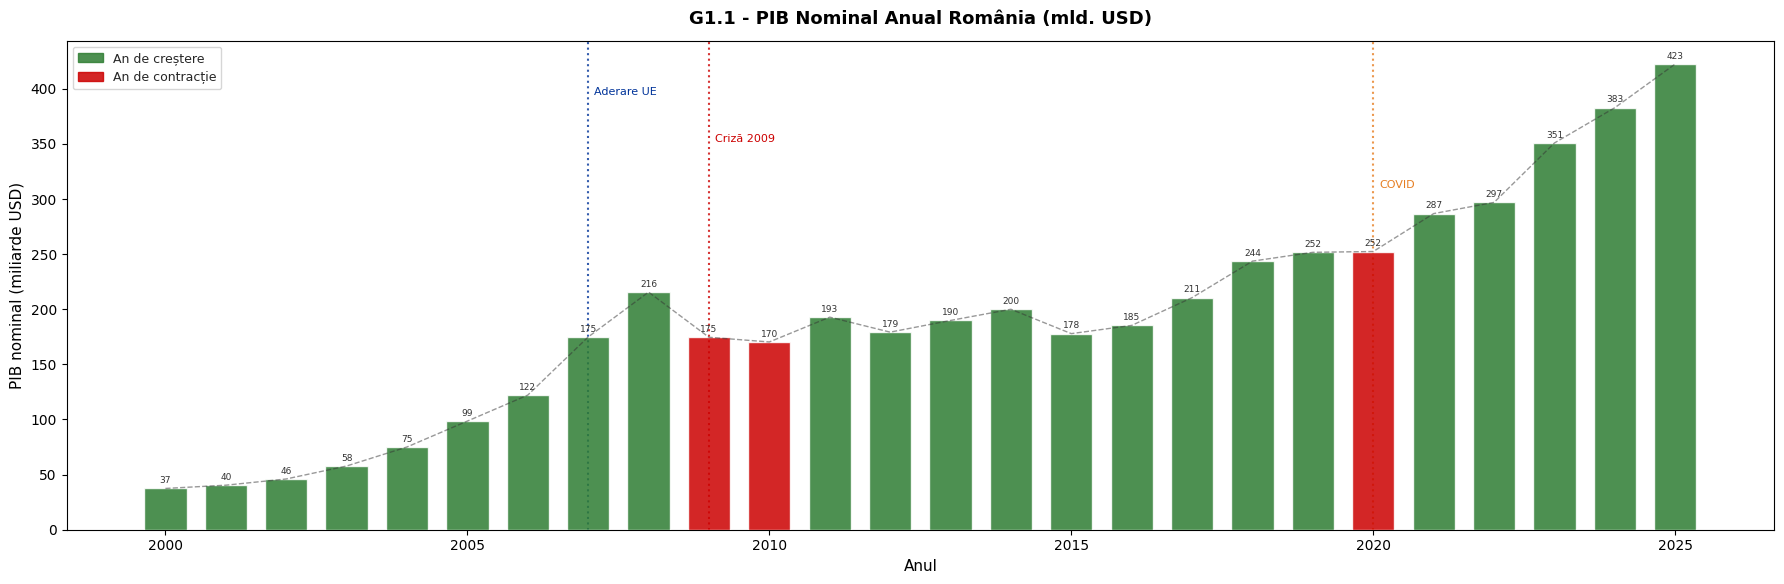

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_p = df_pib_nom.copy()
df_p['pib_mld'] = df_p['pib_nominal_usd'] / 1e9
culori_bare = [CUL['verde'] if v > 0 else CUL['rosu'] for v in df_p['crestere_pib_pct'].fillna(1)]

ax.bar(df_p['an'], df_p['pib_mld'], color=culori_bare, alpha=0.85, width=0.7, zorder=3)

# Etichete pe bare
for _, row in df_p.iterrows():
    if not pd.isna(row['pib_mld']):
        ax.text(row['an'], row['pib_mld'] + 3, f"{row['pib_mld']:.0f}",
                ha='center', va='bottom', fontsize=6.5, color='#333333')

# Linie de tendință
ax.plot(df_p['an'], df_p['pib_mld'], color='#333333', linewidth=1, linestyle='--', alpha=0.5, zorder=4)

ax.axvline(x=2007, color=CUL['ue'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2007.1, df_p['pib_mld'].max() * 0.95, 'Aderare UE', color=CUL['ue'], fontsize=8, va='top')
ax.axvline(x=2009, color=CUL['rosu'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2009.1, df_p['pib_mld'].max() * 0.85, 'Criză 2009', color=CUL['rosu'], fontsize=8, va='top')
ax.axvline(x=2020, color=CUL['portoc'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2020.1, df_p['pib_mld'].max() * 0.75, 'COVID', color=CUL['portoc'], fontsize=8, va='top')

ax.set_xlabel('Anul', fontsize=11)
ax.set_ylabel('PIB nominal (miliarde USD)', fontsize=11)
ax.set_title('G1.1 - PIB Nominal Anual România (mld. USD)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

patch_v = mpatches.Patch(color=CUL['verde'], alpha=0.85, label='An de creștere')
patch_r = mpatches.Patch(color=CUL['rosu'], alpha=0.85, label='An de contracție')
ax.legend(handles=[patch_v, patch_r], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretare G1.1 – PIB Nominal Anual România (mld. USD)

PIB-ul nominal al României a crescut de peste **11 ori** în perioada 2000–2025,
de la **37 mld. USD** la **423 mld. USD**, reflectând atât creșterea economică reală,
cât și efectele inflației și aprecierea leului față de dolar în anumite perioade.

**Trei momente de contracție** sunt vizibile:
- **2009–2010** – criza financiară globală a redus PIB-ul de la 216 la 170 mld. USD
  (-21%), cea mai severă corecție din intervalul analizat;
- **2020** – pandemia COVID a menținut PIB-ul la același nivel nominal ca în 2019
  (252 mld. USD), contracția reală fiind mascată parțial de deprecierea leului.

**Aderarea la UE (2007)** coincide cu accelerarea creșterii: de la 122 mld. USD în 2006
la 175 mld. USD în 2008, susținută de influxuri de capital și fonduri europene.

**Perioada 2020–2025** marchează cea mai rapidă expansiune consecutivă, PIB-ul
crescând cu **~68%** în doar cinci ani, pe fondul redresării post-COVID, inflației
ridicate și deprecierii accentuate a leului față de dolar.

#### G1.2 - PIB trimestrial: România vs. Euro Area (indice volum, 2020=100)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România crește mai rapid decât zona euro - dar și cade mai abrupt în crize.


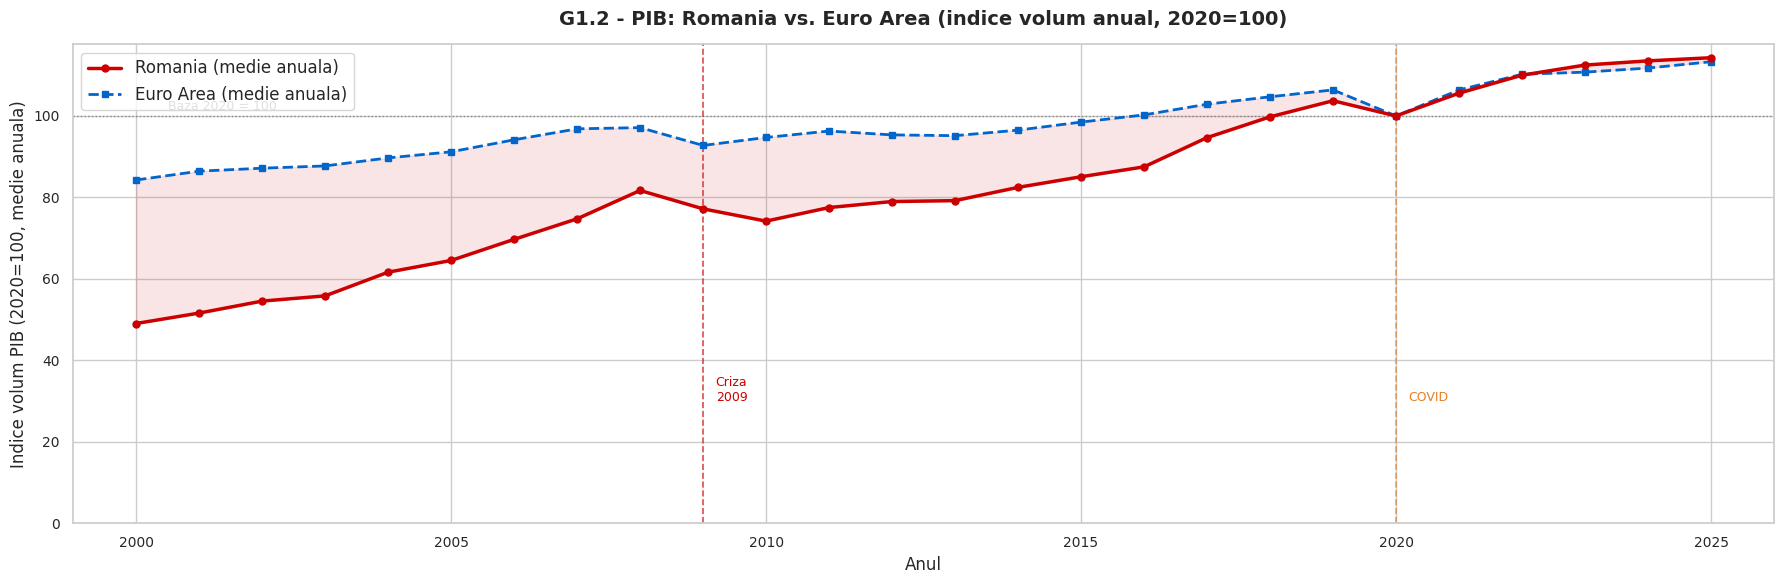

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

# Agregam la nivel anual pentru a elimina sezonalitatea puternica
df_pib_an = df_pib_trim.groupby('an')[['pib_romania_idx','pib_euroarea_idx']].mean().reset_index()
df_pib_an = df_pib_an[df_pib_an['an'] <= 2025]

ax.plot(df_pib_an['an'], df_pib_an['pib_romania_idx'],
        color=CUL['ro'], linewidth=2.5, marker='o', markersize=5,
        label='Romania (medie anuala)', zorder=4)
ax.plot(df_pib_an['an'], df_pib_an['pib_euroarea_idx'],
        color=CUL['ea'], linewidth=2, linestyle='--', marker='s', markersize=4,
        label='Euro Area (medie anuala)', zorder=3)
ax.fill_between(df_pib_an['an'], df_pib_an['pib_romania_idx'],
                df_pib_an['pib_euroarea_idx'], alpha=0.1, color=CUL['ro'])

ax.axhline(y=100, color='#666666', linewidth=1, linestyle=':', alpha=0.7)
ax.text(2000.5, 101.5, 'Baza 2020 = 100', fontsize=9, color='#666666')

ax.axvline(x=2009, color=CUL['rosu'], linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(2009.2, 30, 'Criza\n2009', color=CUL['rosu'], fontsize=9)
ax.axvline(x=2020, color=CUL['portoc'], linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(2020.2, 30, 'COVID', color=CUL['portoc'], fontsize=9)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Indice volum PIB (2020=100, medie anuala)', fontsize=12)
ax.set_title('G1.2 - PIB: Romania vs. Euro Area (indice volum anual, 2020=100)', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(1999, 2026)
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G1.2 – PIB: România vs. Euro Area (indice volum, 2020=100)

Spre deosebire de graficul anterior (PIB nominal în USD), acest grafic elimină
efectele inflației și ale cursului de schimb, surprinzând **creșterea reală a volumului
economic** și, implicit, procesul de **convergență** față de zona euro.

**Decalajul inițial (2000)** era semnificativ: indicele de volum al României (~49)
reprezenta aproximativ **58%** din cel al zonei euro (~84), zona roz ilustrând
grafic această diferență de dezvoltare.

**Perioada 2000–2008** a fost cea mai dinamică pentru România: creștere reală
accelerată, decalajul față de zona euro reducându-se vizibil în fiecare an.
Zona euro, prin contrast, a crescut modest și relativ uniform.

**Criza din 2009** a afectat disproporționat România – indicele a scăzut brusc
de la ~82 la ~74 –, în timp ce zona euro a absorbit șocul mai lin (~93).
Recuperarea post-criză a fost lentă: România a avut nevoie de aproape un deceniu
pentru a reveni la traiectoria pre-criză.

**Convergența** s-a realizat în jurul anului **2019–2020**: pentru prima dată,
România atinge și depășește ușor nivelul de volum al zonei euro (ambele la 100
în 2020, prin construcție). Zona roz dispare, semnalând închiderea decalajului
structural acumulat pe parcursul anilor 2000.

**Post-COVID (2020–2025)**, cele două economii evoluează aproape în paralel,
România menținând un avantaj marginal, sugerând că potențialul de convergență
rapidă s-a diminuat față de perioada pre-criză.

#### G1.3 -  PIB, Inflație, Creștere simultane

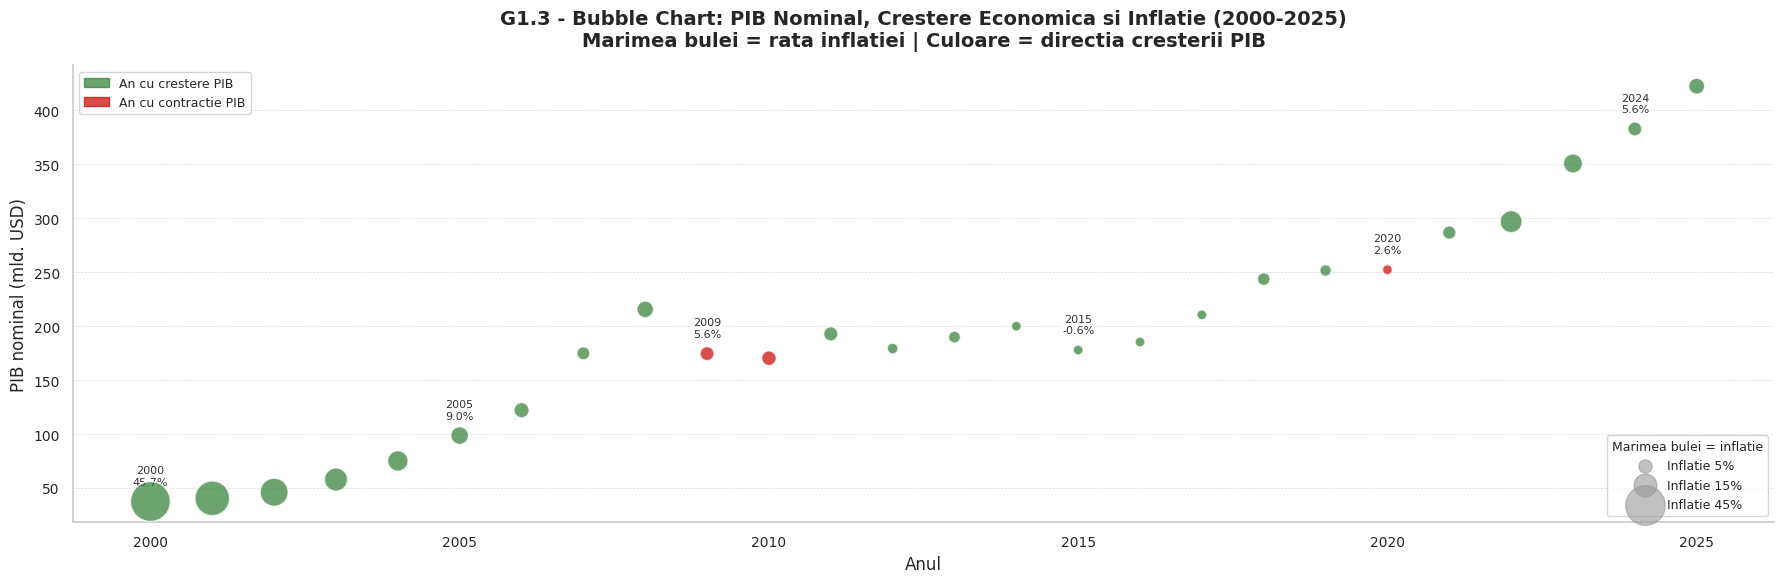

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_bubble = df_pib_nom.merge(df_inflatie, on='an')
df_bubble = df_bubble.dropna(subset=['pib_nominal_usd',
                                     'rata_inflatie_pct',
                                     'crestere_pib_pct'])

culori_bule = [CUL['verde'] if v > 0 else CUL['ro']
               for v in df_bubble['crestere_pib_pct']]

marimi = df_bubble['rata_inflatie_pct'].abs() * 18
marimi = marimi.clip(lower=50)

ax.scatter(df_bubble['an'], df_bubble['pib_nominal_usd'] / 1e9,
           s=marimi, c=culori_bule, alpha=0.7,
           edgecolors='white', linewidths=1, zorder=4)

for _, row in df_bubble.iterrows():
    if row['an'] in [2000, 2005, 2009, 2015, 2020, 2024]:
        ax.annotate(
            f"{int(row['an'])}\n{row['rata_inflatie_pct']:.1f}%",
            xy=(row['an'], row['pib_nominal_usd']/1e9),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=8, color='#333333',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', edgecolor='none', alpha=0.8))

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Legenda 1: culori
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.7, label='An cu crestere PIB')
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.7, label='An cu contractie PIB')
leg1 = ax.legend(handles=[p_v, p_r], loc='upper left', fontsize=9)
ax.add_artist(leg1)

# Legenda 2: dimensiuni bule — construita corect
h_dim = [
    ax.scatter([], [], s=5*18,  color='#999999', alpha=0.6, label='Inflatie 5%'),
    ax.scatter([], [], s=15*18, color='#999999', alpha=0.6, label='Inflatie 15%'),
    ax.scatter([], [], s=45*18, color='#999999', alpha=0.6, label='Inflatie 45%'),
]
leg2 = ax.legend(handles=h_dim, loc='lower right', fontsize=9,
                 title='Marimea bulei = inflatie', title_fontsize=9)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('PIB nominal (mld. USD)', fontsize=12)
ax.set_title('G1.3 - Bubble Chart: PIB Nominal, Crestere Economica si Inflatie (2000-2025)\n'
             'Marimea bulei = rata inflatiei | Culoare = directia cresterii PIB',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G1.3 – Bubble Chart: PIB Nominal, Creștere Economică și Inflație (2000–2025)

Acest grafic adaugă o a treia dimensiune față de G1.1: **rata inflației** (mărimea bulei),
oferind o imagine mai completă a calității creșterii economice nominale.

**Perioada 2000–2003** se remarcă prin bule foarte mari – inflația depășea **45%** în 2000,
una dintre cele mai ridicate din Europa post-comunistă. Creșterea nominală a PIB-ului
din această perioadă era, prin urmare, puternic distorsionată de prețuri, nu de
expansiune economică reală.

**Dezinflația 2003–2007** este vizibilă în micșorarea progresivă a bulelor:
România a reușit să reducă inflația de la niveluri extreme la cifre de o singură
cifră, o condiție esențială pentru aderarea la UE și pentru credibilitatea
macroeconomică.

**Criza 2009–2010** combină două semnale negative: bule roșii (contracție PIB)
cu inflație încă prezentă (~5.6% în 2009) – un episod de **stagflație moderată**,
în care economia se contracta, dar prețurile continuau să crească.

**2015** apare ca o anomalie: o ușoară contracție nominală (-0.6%) însoțită de
o bulă mică, reflectând probabil episodul de **deflație/inflație negativă** din
acea perioadă (reducerea TVA și prețuri scăzute la energie).

**2020 (COVID)**: bulă roșie de dimensiune moderată (2.6% inflație) – contracție
reală, dar presiune inflaționistă încă limitată, înainte de explozia post-pandemică.

**2022–2024**: bulele redevin vizibile (5.6% inflație în 2024), indicând că
expansiunea recentă a PIB-ului nominal este parțial alimentată din nou de inflație,
nu exclusiv din creștere reală – un semnal de prudență în interpretarea valorilor absolute.

---
### 📈 Capitol 2 - Inflație și Politică Monetară BNR

România a traversat trei episoade inflaționiste distincte: tranziția (2000–2004), șocul energetic pre-criză (2007–2008) și șocul post-pandemic (2022–2023, vârf 16.4%).


#### G2.1 - Inflație IPC lunar + Dobânda BNR (ax dual, 2003–2026)
**Tipul graficului:** Linie cu două axe Y (`twinx`)  
**Mesajul:** BNR reacționează cu creșteri de dobândă la fiecare episod inflaționist - lag vizibil de 2–3 trimestre.


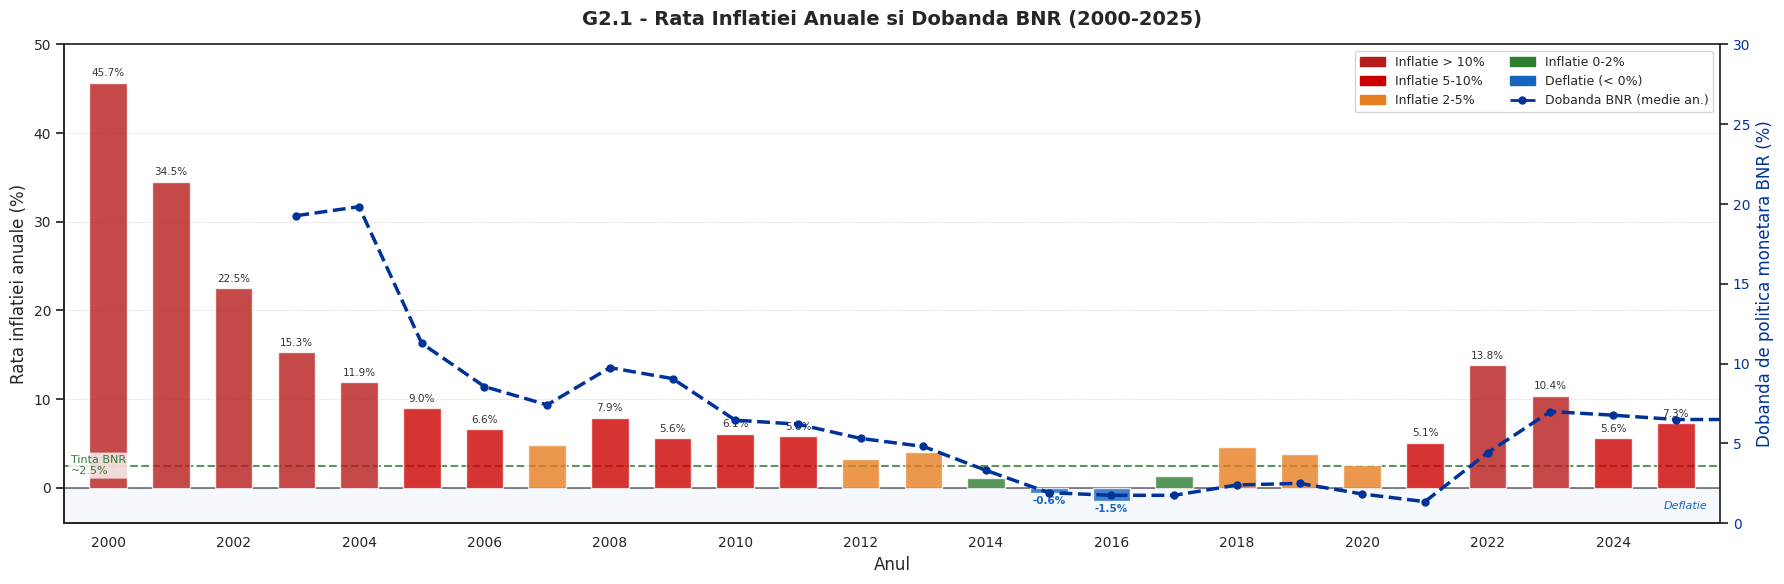

In [ ]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')  # fara grid implicit

df_inf = df_inflatie.copy()

culori_inf = []
for v in df_inf['rata_inflatie_pct']:
    if v > 10:   culori_inf.append('#B71C1C')
    elif v > 5:  culori_inf.append(CUL['ro'])
    elif v > 2:  culori_inf.append(CUL['portoc'])
    elif v >= 0: culori_inf.append(CUL['verde'])
    else:        culori_inf.append('#1565C0')

ax1.bar(df_inf['an'], df_inf['rata_inflatie_pct'],
        color=culori_inf, alpha=0.80, width=0.6, zorder=3)

# Doar grid orizontal, subtil
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.axhline(y=0,   color='#333333', linewidth=1.2, linestyle='-',  alpha=0.7)
ax1.axhline(y=2.5, color=CUL['verde'], linewidth=1.5, linestyle='--', alpha=0.8)
ax1.text(1999.4, 2.5, 'Tinta BNR\n~2.5%', fontsize=8, color=CUL['verde'],
         va='center', ha='left',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

ax1.set_ylabel('Rata inflatiei anuale (%)', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_ylim(-4, 50)

for _, row in df_inf.iterrows():
    if row['rata_inflatie_pct'] > 5:
        ax1.text(row['an'], row['rata_inflatie_pct'] + 0.5,
                 f"{row['rata_inflatie_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=7.5, color='#333333')

for _, row in df_inf.iterrows():
    if row['rata_inflatie_pct'] < 0:
        ax1.text(row['an'], row['rata_inflatie_pct'] - 0.3,
                 f"{row['rata_inflatie_pct']:.1f}%",
                 ha='center', va='top', fontsize=7.5,
                 color='#1565C0', fontweight='bold')

ax1.axhspan(-4, 0, alpha=0.04, color='#1565C0', zorder=0)
ax1.text(2025.5, -2, 'Deflatie', fontsize=8, color='#1565C0',
         style='italic', ha='right', va='center')

ax2 = ax1.twinx()
df_bnr_an = df_bnr.copy()
df_bnr_an['an'] = df_bnr_an['data'].dt.year
df_bnr_anual = df_bnr_an.groupby('an')['dobanda_pm'].mean().reset_index()
df_bnr_anual = df_bnr_anual[df_bnr_anual['an'] >= 2000]

ax2.plot(df_bnr_anual['an'], df_bnr_anual['dobanda_pm'],
         color=CUL['ue'], linewidth=2.5, marker='o', markersize=5,
         linestyle='--', zorder=5)
ax2.set_ylabel('Dobanda de politica monetara BNR (%)', color=CUL['ue'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=10)
ax2.set_ylim(0, 30)
ax2.yaxis.grid(False)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
p1 = mpatches.Patch(color='#B71C1C', label='Inflatie > 10%')
p2 = mpatches.Patch(color=CUL['ro'],     label='Inflatie 5-10%')
p3 = mpatches.Patch(color=CUL['portoc'], label='Inflatie 2-5%')
p4 = mpatches.Patch(color=CUL['verde'],  label='Inflatie 0-2%')
p5 = mpatches.Patch(color='#1565C0',    label='Deflatie (< 0%)')
l1 = Line2D([0],[0], color=CUL['ue'], linewidth=2, linestyle='--',
            marker='o', markersize=5, label='Dobanda BNR (medie an.)')
ax1.legend(handles=[p1, p2, p3, p4, p5, l1], loc='upper right', fontsize=9, ncol=2)

ax1.set_xlabel('Anul', fontsize=12)
ax1.set_title('G2.1 - Rata Inflatiei Anuale si Dobanda BNR (2000-2025)',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(1999.3, 2025.7)
ax1.set_xticks(range(2000, 2026, 2))
ax1.tick_params(axis='x', labelsize=10)

# Spine curate
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretare G2.1 – Rata Inflației Anuale și Dobânda BNR (2000–2025)

Graficul surprinde două cicluri inflaționiste distincte și răspunsul politicii
monetare a BNR de-a lungul a 25 de ani.

**Primul ciclu (2000–2006): dezinflația structurală**
România pornea de la o inflație de **45.7%** în 2000 – un nivel caracteristic
economiilor în tranziție cu dezechilibre fiscale și monetare profunde. BNR a
menținut dobânzi de politică monetară extrem de ridicate (peste 20% în 2003–2004,
axa dreaptă) pentru a ancora așteptările inflaționiste. Reducerea treptată până
la ~6.6% în 2006 a reprezentat una dintre cele mai rapide dezinflații din regiune,
condiție necesară pentru aderarea la UE.

**Episodul 2008–2010: reinflație ciclică**
Cererea internă accelerată pre-criză a împins inflația înapoi spre 7.9% în 2008.
Criza a temperat presiunile, dar dezechilibrele structurale au menținut inflația
deasupra țintei BNR (~2.5%, linia verde punctată) până în 2012.

**Episodul 2014–2015: deflație**
Un moment singular în istoria recentă a României: inflație negativă (-0.6% și
-1.5%), cauzată de reducerea TVA la alimente și prețuri scăzute la energie.
BNR a răspuns cu dobânzi la minime istorice (~1.75%), apropiindu-se de politica
de relaxare cantitativă practicată în zona euro.

**Al doilea ciclu inflaționist (2021–2025): șocul post-pandemic**
Combinația dintre redresarea cererii post-COVID, criza energetică și perturbările
lanțurilor de aprovizionare a dus inflația la **13.8% în 2022** – cel mai ridicat
nivel din ultimii 15 ani. BNR a reacționat cu creșteri succesive ale dobânzii
(până la ~7%), dar cu o întârziere față de BCE și față de alte bănci centrale din
regiune. Dezinflația a fost graduală: 10.4% în 2023, 5.6% în 2024, însă **ținta
de 2.5% rămâne departe**, inflația reaccelând ușor la 7.3% în 2025.

**Concluzie:** Politica monetară a BNR a fost eficientă în primul ciclu, dar
al doilea ciclu inflationist evidențiază vulnerabilitatea structurală a economiei
române la șocuri externe și dependența de importuri energetice.

#### G2.2 - HICP lunar: România vs. UE-27 (variație lunară %, 2000–2025)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România înregistrează constant volatilitate mai mare față de media UE - structural, nu conjunctural.


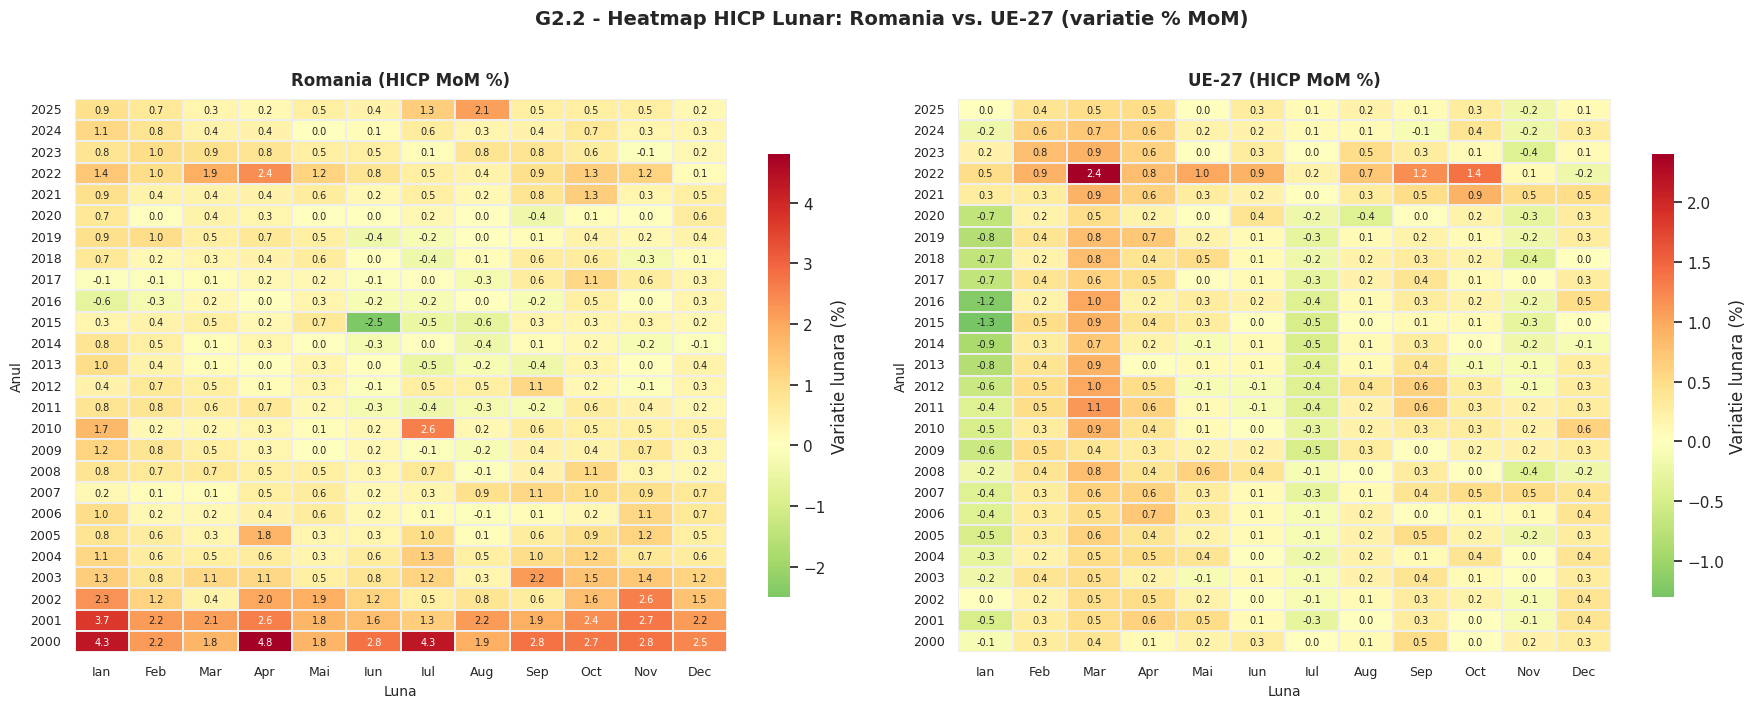

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set(style='white')

df_h = df_hicp.copy()
df_h['an']   = df_h['data'].dt.year
df_h['luna'] = df_h['data'].dt.month

luni_label = ['Ian','Feb','Mar','Apr','Mai','Iun',
              'Iul','Aug','Sep','Oct','Nov','Dec']

for idx, (col, titlu, cmap) in enumerate([
    ('hicp_ro', 'Romania (HICP MoM %)', 'RdYlGn_r'),
    ('hicp_ue', 'UE-27 (HICP MoM %)',  'RdYlGn_r'),
]):
    ax = axes[idx]
    pivot = df_h.pivot_table(index='an', columns='luna', values=col, aggfunc='mean')
    pivot.columns = luni_label
    pivot = pivot.sort_index(ascending=False)

    sns.heatmap(pivot, ax=ax, cmap=cmap, center=0,
                annot=True, fmt='.1f', annot_kws={'size': 7},
                linewidths=0.3, linecolor='#eeeeee',
                cbar_kws={'label': 'Variatie lunara (%)', 'shrink': 0.8})

    ax.set_title(titlu, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Luna', fontsize=10)
    ax.set_ylabel('Anul', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

fig.suptitle('G2.2 - Heatmap HICP Lunar: Romania vs. UE-27 (variatie % MoM)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretare G2.2 – Heatmap HICP Lunar: România vs. UE-27 (variație % MoM)

Acest heatmap comparativ relevă nu doar **intensitatea inflației lunare**, ci și
**structura sa sezonieră și sensibilitatea la șocuri de politică fiscală** –
aspecte invizibile în indicatorii anuali.

**Scalele sunt diferite** – un detaliu esențial: România folosește o scală până
la ±4-5%, în timp ce UE-27 se încadrează în ±2%. Această asimetrie vizuală
rezumă, în sine, diferența de volatilitate structurală dintre cele două economii.

**România anilor 2000–2003: roșu intens**
Variații lunare de 4-5% (Ianuarie 2000: **+4.3%**, Aprilie 2000: **+4.8%**)
arată o economie în care prețurile se recalibrau lunar, fără ancorare credibilă.
UE-27 în aceeași perioadă: variații sub 0.5% – o diferență de un ordin de mărime.

**Tipare sezoniere clare în România:**
- **Ianuarie** apare sistematic ca lună de creșteri (ajustări de tarife reglementate,
  prețuri energie, actualizări contractuale la început de an).
- **Iulie** este luna cu cele mai mari **șocuri de politică fiscală**: creșterea
  TVA de la 19% la 24% în iulie 2010 (+2.6% MoM) și reducerea TVA la alimente
  în iulie 2015 (-2.5% MoM) sunt vizibile cu claritate în heatmap.

**UE-27: stabilitate remarcabilă**
Heatmap-ul drept este dominant verde-gălbui, cu excepția lui **Martie 2022**
(+2.4% MoM) – apogeul șocului energetic post-invazie Ucraina. Această uniformitate
reflectă ancorarea așteptărilor inflaționiste prin politica BCE și structuri
economice mai mature.

**Convergența recentă (2019–2021)**
Ambele heatmap-uri devin similar de pale, semnalând o perioadă de inflație
redusă și sincronizare ciclică între România și UE – efect al integrării
economice profunde și al politicii fiscale relativ prudente din acea perioadă.

**2022: resincronizare în șoc**
Ambele țări/blocuri reintră simultan în zone roșii, cu România depășind UE-27
ca intensitate lunară, confirmând vulnerabilitatea mai ridicată a economiei
române la importul de inflație (energie, alimente, cursul de schimb).

#### G2.3 - Distribuția Inflației Lunare

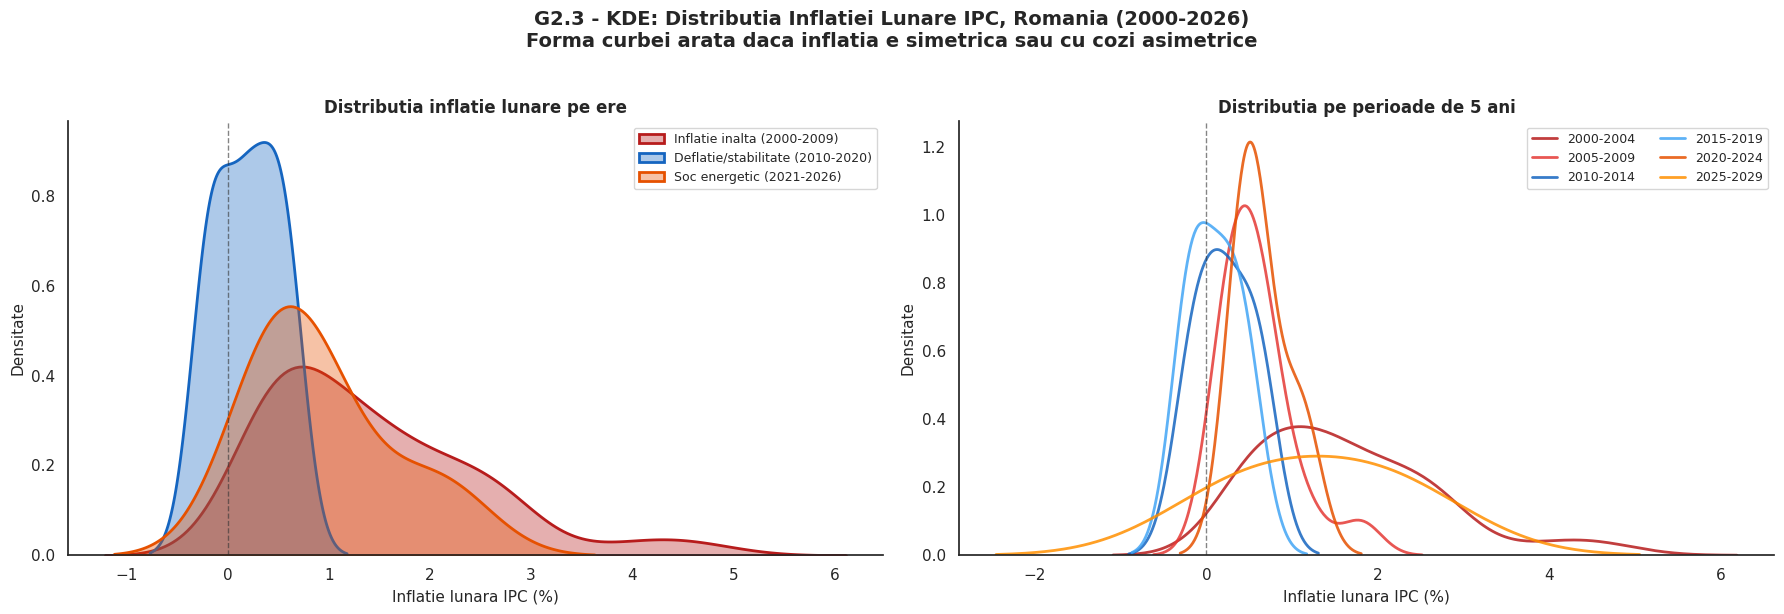

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set(style='white')

df_kde = df_ipc.copy()
df_kde['ipc_pct'] = (df_kde['ipc_mom'] / 10.0) - 100.0
df_kde = df_kde[(df_kde['ipc_pct'] > -5) & (df_kde['ipc_pct'] < 15)]
df_kde['era'] = df_kde['data'].dt.year.apply(
    lambda x: 'Inflatie inalta (2000-2009)' if x < 2010
    else ('Deflatie/stabilitate (2010-2020)' if x < 2021
          else 'Soc energetic (2021-2026)'))

culori_era = {
    'Inflatie inalta (2000-2009)':      '#B71C1C',
    'Deflatie/stabilitate (2010-2020)': '#1565C0',
    'Soc energetic (2021-2026)':        '#E65100'
}

# Stanga: KDE per era
ax1 = axes[0]
for era, culoare in culori_era.items():
    subset = df_kde[df_kde['era'] == era]['ipc_pct']
    sns.kdeplot(subset, ax=ax1, fill=True, alpha=0.35,
                color=culoare, label=era, linewidth=2)

ax1.axvline(x=0, color='#333333', linewidth=1, linestyle='--', alpha=0.6)
ax1.set_xlabel('Inflatie lunara IPC (%)', fontsize=11)
ax1.set_ylabel('Densitate', fontsize=11)
ax1.set_title('Distributia inflatie lunare pe ere', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# Dreapta: KDE per decada cu rugplot
ax2 = axes[1]
df_kde['decada'] = (df_kde['data'].dt.year // 5 * 5).astype(str)
palette_dec = {'2000': '#B71C1C', '2005': '#E53935', '2010': '#1565C0',
               '2015': '#42A5F5', '2020': '#E65100', '2025': '#FF8F00'}

for decada in sorted(df_kde['decada'].unique()):
    subset = df_kde[df_kde['decada'] == decada]['ipc_pct']
    c = palette_dec.get(decada, '#888888')
    sns.kdeplot(subset, ax=ax2, color=c, linewidth=2,
                label=f'{decada}-{int(decada)+4}', alpha=0.85)

ax2.axvline(x=0, color='#333333', linewidth=1, linestyle='--', alpha=0.6)
ax2.set_xlabel('Inflatie lunara IPC (%)', fontsize=11)
ax2.set_ylabel('Densitate', fontsize=11)
ax2.set_title('Distributia pe perioade de 5 ani', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, ncol=2)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.suptitle('G2.3 - KDE: Distributia Inflatiei Lunare IPC, Romania (2000-2026)\n'
             'Forma curbei arata daca inflatia e simetrica sau cu cozi asimetrice',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretare G2.3 – KDE: Distribuția Inflației Lunare IPC, România (2000–2026)

Spre deosebire de graficele anterioare care arătau *niveluri*, acest grafic
statistică **forma distribuției** inflației lunare – adică cât de previzibilă,
simetrică sau volatilă a fost inflația în diferite perioade.

**Panoul stâng – trei ere distincte:**

- **Era inflației înalte (2000–2009, roșu):** Distribuție **largă, aplatizată,
  cu coadă dreaptă masivă** – inflația lunară ajungea frecvent la 2–6%.
  Moda (~0.5%) este înșelătoare: valorile extreme erau comune, nu excepții.
  O economie în care prețurile erau imprevizibile lunar.

- **Era stabilității (2010–2020, albastru):** Distribuție **îngustă, înaltă,
  centrată aproape de zero** – cea mai concentrată dintre toate. Inflația lunară
  era mică și previzibilă, cu episoade rare de deflație (coada stângă ușoară).
  Aceasta este "normalitatea" la care BNR aspira să revină.

- **Șocul energetic (2021–2026, portocaliu):** Distribuție **intermediară**,
  mai largă decât era stabilității, cu coadă dreaptă reapărută. Volatilitatea
  lunară a crescut, dar nu a atins amplitudinea anilor 2000 – un semn că
  mecanismele de ancorare funcționează parțial.

**Panoul drept – granularitate pe perioade de 5 ani:**

Confirmă tranziția treptată: curbele se *îngustează și se deplasează spre stânga*
de la 2000–2004 (roșu închis, lată) până la 2015–2019 (albastru deschis, cea mai
concentrată), după care **2020–2024 și 2025–2029** revin spre dreapta cu cozi
mai late – un pas înapoi în maturizarea inflaționistă.

**Concluzie statistică:** România a parcurs un drum de la o distribuție
*leptokurtică asimetrică* (cozi groase, șocuri frecvente) spre una
*aproape normală* (stabilitate 2015–2019), dar șocurile recente riscă să
inverseze parțial această convergență structurală.

---
### 💱 Capitol 3 - Curs Valutar

EUR/RON a rămas remarcabil de stabil față de PLN și HUF - o anomalie regională care generează atât avantaje (predictibilitate) cât și întrebări despre supraevaluare și flexibilitate economică.


#### G3.1 - Cursuri indexate EUR/RON, EUR/PLN, EUR/HUF (baza iulie 2005=100)
**Tipul graficului:** Linie multi-serie pe date lunare  
**Mesajul:** RON s-a depreciat moderat față de EUR, în timp ce PLN și HUF au oscilat violent - mai ales HUF după 2022.


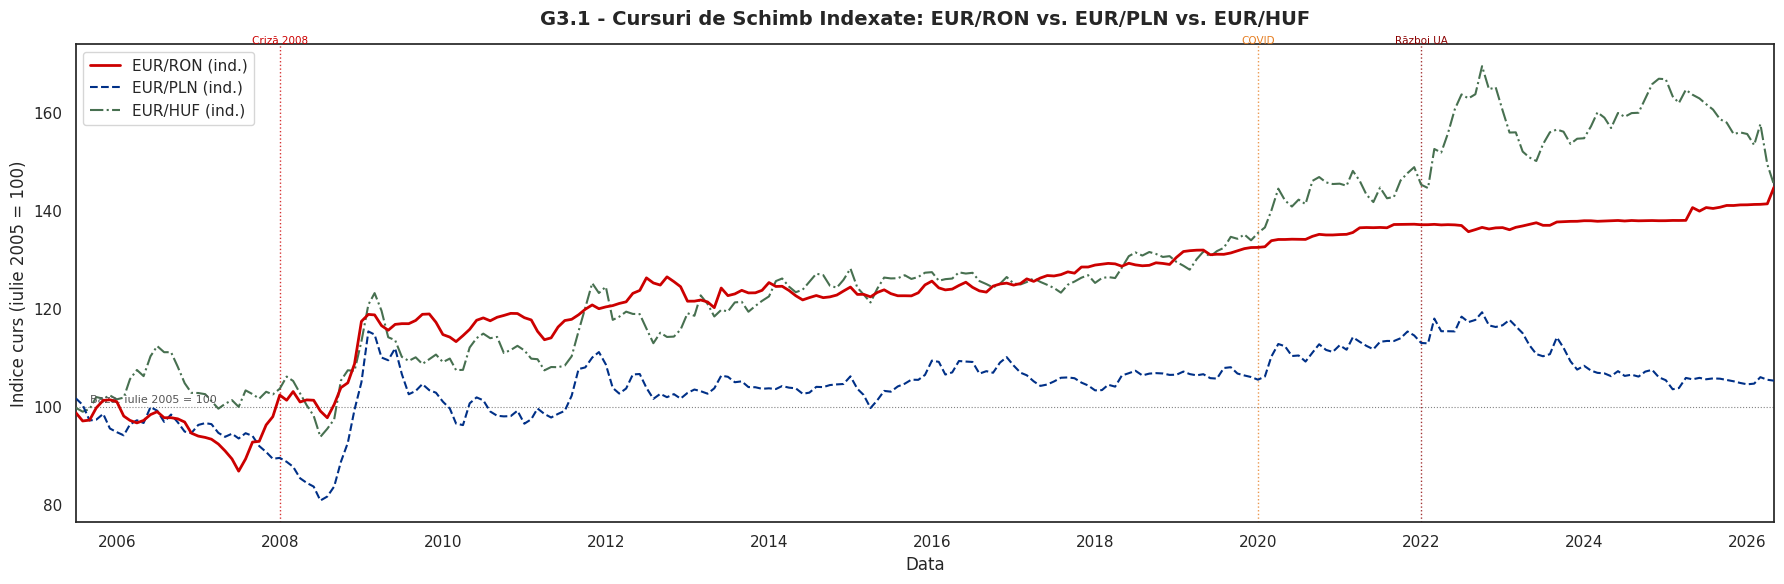

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

ax.plot(df_curs_lunar['data'], df_curs_lunar['ron_idx'],
        color=CUL['ro'], linewidth=2, label='EUR/RON (ind.)', zorder=5)
ax.plot(df_curs_lunar['data'], df_curs_lunar['pln_idx'],
        color=CUL['pln'], linewidth=1.5, linestyle='--', label='EUR/PLN (ind.)', zorder=4)
ax.plot(df_curs_lunar['data'], df_curs_lunar['huf_idx'],
        color=CUL['huf'], linewidth=1.5, linestyle='-.', label='EUR/HUF (ind.)', zorder=3)

ax.axhline(y=100, color='#333333', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(df_curs_lunar['data'].iloc[2], 101, 'Baza: iulie 2005 = 100', fontsize=8, color='#555555')

for an, label, culoare in [(2008, 'Criză 2008', CUL['rosu']),
                            (2020, 'COVID', CUL['portoc']),
                            (2022, 'Război UA', '#8B0000')]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1, linestyle=':', alpha=0.8)
    ax.text(pd.Timestamp(str(an)), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 160,
            label, ha='center', fontsize=7.5, color=culoare)

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Indice curs (iulie 2005 = 100)', fontsize=12)
ax.set_title('G3.1 - Cursuri de Schimb Indexate: EUR/RON vs. EUR/PLN vs. EUR/HUF', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(df_curs_lunar['data'].min(), df_curs_lunar['data'].max())

plt.tight_layout()
plt.show()

### Interpretare G3.1 – Cursuri de Schimb Indexate: EUR/RON vs. EUR/PLN vs. EUR/HUF

Indexarea la iulie 2005 = 100 permite o comparație directă a **deprecierii cumulate**
față de euro, eliminând diferențele de nivel absolut între cele trei valute.
Un indice mai mare înseamnă depreciere mai accentuată față de euro.

**Trei strategii de politică monetară, trei traiectorii:**

- **EUR/RON (roșu, continuu) – depreciere graduală și controlată:**
  Linia cea mai netedă dintre cele trei. BNR practică un *float administrat*
  (managed float), intervenind activ pentru a preveni volatilitatea bruscă.
  Deprecierea cumulată față de euro în 20 de ani este de ~**42%**, dar realizată
  aproape liniar – predictibilă pentru companii și investitori. Absența oricărui
  spike major confirmă că BNR a sacrificat flexibilitatea în favoarea stabilității.

- **EUR/PLN (albastru, punctat) – cea mai bună performanță relativă:**
  Zlotul a depreciat semnificativ în criza 2008–2009 (de la 95 la 120 index),
  dar a recuperat ulterior și a evoluat în intervalul 100–115 pentru aproape un
  deceniu. Este singura valută din grafic care a revenit aproape de nivelul
  de referință post-criză. Sfârșitul perioadei (105–108) indică o depreciere
  cumulată de doar **~7%** față de euro – performanță remarcabilă față de celelalte două.

- **EUR/HUF (verde, punctat-linie) – cea mai mare volatilitate:**
  Forintul a urmat un traseu opus: depreciere severă în 2008–2009, recuperare
  parțială, apoi **colaps accelerat post-2020**, atingând un vârf de ~170+ după
  declanșarea războiului din Ucraina (2022). Deprecierea cumulată de ~**60–70%**
  reflectă politica monetară neconvențională a Băncii Naționale a Ungariei
  (dobânzi negative reale prelungite) și vulnerabilitățile fiscale structurale.

**Momentele de stres vizibile în toate cele trei valute:**
- **Criza 2008:** spike comun, cel mai acut la HUF și PLN; RON mai temperat.
- **COVID 2020:** divergența se adâncește – HUF începe să se desprindă în sus.
- **Războiul din Ucraina 2022:** HUF atinge maximul istoric; RON rămâne stabil;
  PLN fluctuează moderat.

**Concluzie:** Graficul ilustrează că stabilitatea cursului EUR/RON nu este
un fenomen de piață, ci rezultatul unei **intervenții deliberate și costisitoare**
din rezervele BNR. Comparația cu HUF arată ce s-ar fi putut întâmpla în absența
acestei politici, iar comparația cu PLN ridică întrebarea dacă flexibilitatea
controlată ar fi putut aduce beneficii pe termen lung.

#### **G3.2 - Distribuția anuală EUR/RON (volatilitate zilnică pe ani)**

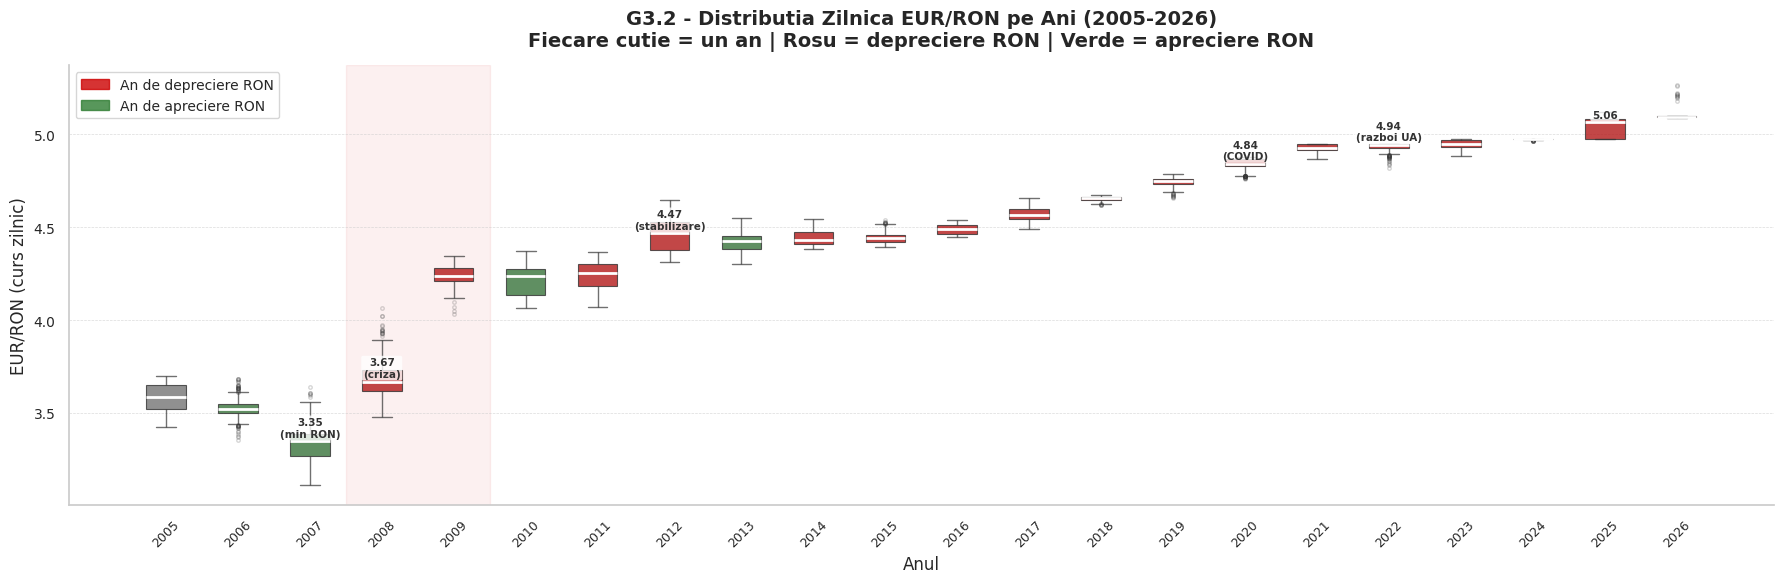

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_box = df_curs.copy()
df_box['an'] = df_box['data'].dt.year

# Culori: verde pentru ani de apreciere RON, rosu pentru depreciere
ani_unici = sorted(df_box['an'].unique())
mediane = df_box.groupby('an')['eur_ron'].median()
culori_box = []
for i, an in enumerate(ani_unici):
    if i == 0:
        culori_box.append(CUL['gri'])
    else:
        culori_box.append(CUL['ro'] if mediane[an] > mediane[ani_unici[i-1]]
                          else CUL['verde'])

sns.boxplot(data=df_box, x='an', y='eur_ron', ax=ax,
            palette=culori_box, width=0.55, fliersize=1.5,
            flierprops=dict(marker='o', alpha=0.2, markersize=2.5),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(linewidth=1, alpha=0.7),
            capprops=dict(linewidth=1, alpha=0.7),
            boxprops=dict(alpha=0.8),
            linewidth=0.8)

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Etichete mediana doar la ani cheie cu valori semnificative
ani_cheie = {2007: 'min RON', 2008: 'criza', 2012: 'stabilizare',
             2020: 'COVID', 2022: 'razboi UA', 2025: None}
for an_ref, nota in ani_cheie.items():
    if an_ref not in mediane.index: continue
    med = mediane[an_ref]
    pos = ani_unici.index(an_ref)
    eticheta = f'{med:.2f}' if nota is None else f'{med:.2f}\n({nota})'
    ax.text(pos, med + 0.015, eticheta,
            ha='center', va='bottom', fontsize=7.5,
            color='#333333', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='none', alpha=0.8))

# Zona crizei 2008
ax.axvspan(ani_unici.index(2008) - 0.5,
           ani_unici.index(2009) + 0.5,
           alpha=0.06, color=CUL['ro'], zorder=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

import matplotlib.patches as mpatches
p_dep = mpatches.Patch(color=CUL['ro'],    alpha=0.8, label='An de depreciere RON')
p_apr = mpatches.Patch(color=CUL['verde'], alpha=0.8, label='An de apreciere RON')
ax.legend(handles=[p_dep, p_apr], fontsize=10, loc='upper left')

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('EUR/RON (curs zilnic)', fontsize=12)
ax.set_title('G3.2 - Distributia Zilnica EUR/RON pe Ani (2005-2026)\n'
             'Fiecare cutie = un an | Rosu = depreciere RON | Verde = apreciere RON',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G3.2 – Distribuția Zilnică EUR/RON pe Ani (2005–2026)

Box plot-ul anual transformă cursul zilnic într-un instrument de analiză a
**volatilității și direcției deprecierii**, nu doar a nivelului.
Cutiile înguste = BNR intervine activ; cutiile largi = episoade de stres.

**2007 – minimul istoric al EUR/RON (≈ 3.35):**
Singurul an verde semnificativ: leul s-a apreciat față de euro, alimentat de
euforia post-aderare UE, intrări masive de capital și optimism investițional.
Cutia este îngustă – aprecierea a fost ordonată, nu speculativă.

**2008–2009 – criza: cea mai mare cutie din grafic:**
Trecerea bruscă de la ≈ 3.35 la ≈ 4.25 în mai puțin de doi ani. Cutiile largi
și whisker-ele extinse indică **volatilitate ridicată zilnică** – perioada în care
BNR a pierdut temporar controlul asupra ritmului deprecierii.
Mediana 2008 (≈ 3.67) arată că șocul principal s-a produs în a doua jumătate a anului.

**2010–2018 – stabilizare remarcabilă:**
Cutiile devin progresiv mai **înguste și orizontale** – BNR reușește să mențină
EUR/RON într-un tunel extrem de strâns, de regulă ±0.05 RON față de mediană.
Această perioadă ilustrează cel mai clar politica de *float administrat*:
cursul urca treptat (de la ≈ 4.20 la ≈ 4.65), dar fără nicio zi de panică.

**2020 (COVID, ≈ 4.84) și 2022 (Război UA, ≈ 4.94):**
Ambele șocuri produc deprecieri punctuale, dar cutiile rămân **surprinzător de înguste**
față de 2008–2009. BNR a intervenit masiv din rezerve valutare pentru a amortiza
impactul – confirmare directă a costului stabilității cursului.

**2024–2026: pragul de 5 RON/EUR depășit:**
Cutia din 2025 (≈ 5.06) este aproape invizibil de îngustă – variație zilnică
sub 0.01 RON – iar 2026 arată primele outlier-e deasupra lui 5.15.
Depășirea barierei psihologice de 5 RON/EUR, deși graduală, marchează o nouă
etapă a deprecierii structurale a leului.

**Concluzie:** Graficul confirmă că stabilitatea EUR/RON este **construită, nu naturală**.
Dimensiunea cutiilor este invers proporțională cu intensitatea intervenției BNR –
și direct proporțională cu costul acesteia în rezerve valutare.

---
### 👷 Capitol 4 - Piața Muncii

O poveste în trei acte: șomaj ridicat la tranziție, scădere după aderarea UE (cu milioane de emigranți), și o piață a muncii tensionată post-2017 - salarii în creștere rapidă, șomaj structural scăzut.


#### G4.1 - Rata Șomajului BIM trimestrial (%, 2000–2025)
**Tipul graficului:** Linie cu fill sub curbă  
**Mesajul:** Șomajul a scăzut constant după 2013 - dar emigrația a contribuit la această reducere, nu doar crearea de locuri de muncă.


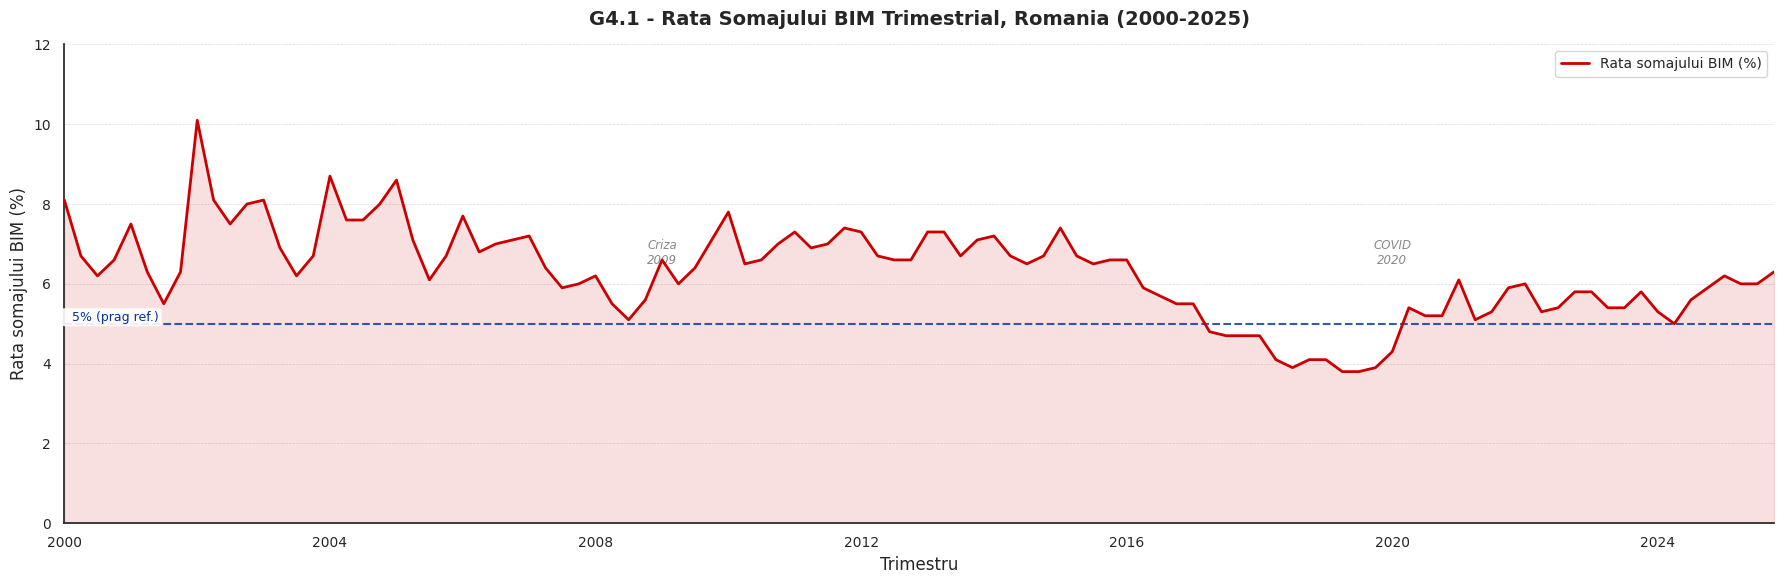

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

ax.plot(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
        color=CUL['ro'], linewidth=2, zorder=4, label='Rata somajului BIM (%)')
ax.fill_between(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
                alpha=0.12, color=CUL['ro'])

# Grid orizontal subtil, fara vertical
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Prag 5% cu text pe marginea stanga
ax.axhline(y=5, color=CUL['ue'], linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(df_somaj_trim['data'].iloc[0], 5, '  5% (prag ref.)',
        ha='left', va='bottom', fontsize=9, color=CUL['ue'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# Fara linii verticale - doar adnotare text simpla
ax.annotate('Criza\n2009', xy=(pd.Timestamp('2009-01-01'), 6.5),
            fontsize=8.5, color='#888888', ha='center', style='italic')
ax.annotate('COVID\n2020', xy=(pd.Timestamp('2020-01-01'), 6.5),
            fontsize=8.5, color='#888888', ha='center', style='italic')

ax.set_xlabel('Trimestru', fontsize=12)
ax.set_ylabel('Rata somajului BIM (%)', fontsize=12)
ax.set_title('G4.1 - Rata Somajului BIM Trimestrial, Romania (2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(df_somaj_trim['data'].min(), df_somaj_trim['data'].max())
ax.set_ylim(0, 12)
ax.tick_params(axis='both', labelsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretare G4.1 – Rata Șomajului BIM Trimestrial, România (2000–2025)

Rata șomajului BIM (metodologie ILO) oferă o imagine mai fidelă a pieței muncii
decât șomajul înregistrat la ANOFM, incluzând persoanele care caută activ un loc
de muncă indiferent dacă sunt înregistrate oficial.

**Sezonalitatea puternică – un pattern structural:**
Dinții de fierăstrău vizibili de-a lungul întregii serii reflectă **sezonalitatea
pronunțată** a economiei române: șomajul crește în T1 (iarnă – construcții și
agricultură în pauză) și scade în T3–T4 (vară–toamnă – reabsorbție sezonieră).
Această structură nu dispare nici în perioadele de boom, indicând o piață a muncii
cu flexibilitate redusă și dependență de sectoarele ciclice.

**2001 – vârful istoric (≈ 10.2%):**
Restructurările industriale post-comuniste și privatizările forțate din această
perioadă au produs cel mai ridicat șomaj din seria analizată. Economia nu crease
încă suficiente locuri de muncă în sectoarele private pentru a absorbi forța de
muncă disponibilizată din industria de stat.

**2005–2008 – prima coborâre sub pragul de referință de 5%:**
Boom-ul economic pre-aderare a absorbit rapid forța de muncă disponibilă.
Paradoxal, tocmai în această perioadă **emigrația masivă** post-2007 a început
să reducă presiunea pe piața muncii – scăzând rata șomajului nu prin crearea de
locuri de muncă, ci prin reducerea ofertei de forță de muncă.

**Criza 2009–2013 – rebound moderat (≈ 7.5–8%):**
Spre deosebire de alte economii din regiune, șomajul românesc nu a explodat
spectaculos în criză. Explicația: o parte din ajustare s-a făcut prin **reducerea
salariilor reale** și prin migrația suplimentară, nu prin concedieri masive.

**2017–2019 – minimul historic sub 4%:**
Economia supraîncălzită, creșterile salariale în sectorul public și construcțiile
au dus rata la minimele absolute ale seriei. O piață a muncii aproape de ocupare
deplină – dar alimentată și de îmbătrânirea și emigrarea populației active, nu
doar de crearea de locuri de muncă productive.

**COVID 2020 – șoc surprinzător de mic (≈ +1.5 pp):**
România a evitat o creștere dramatică a șomajului prin schemele de șomaj tehnic
subvenționate de stat și prin structura economiei (pondere ridicată a agriculturii
de subzistență și a lucrului informal care nu apare în statistici).

**2023–2025 – tendință ascendentă îngrijorătoare (≈ 6–6.5%):**
Reaccelerarea spre 6% în condițiile unei economii nominale în creștere sugerează
o **deteriorare a calității creșterii**: investițiile productive nu generează locuri
de muncă suficiente, iar consolidarea fiscală din 2024–2025 a redus angajările în
sectorul public – unul dintre motoarele principale ale ocupării din ultimii ani.

#### G4.2 - Salariul Minim pe Economie (RON brut, step chart)
**Tipul graficului:** Step chart - fiecare modificare legislativă e vizibilă ca salt  
**Mesajul:** Salariul minim a crescut de ~14× în 20 de ani - de la 310 RON (2005) la 4.325 RON (2026).


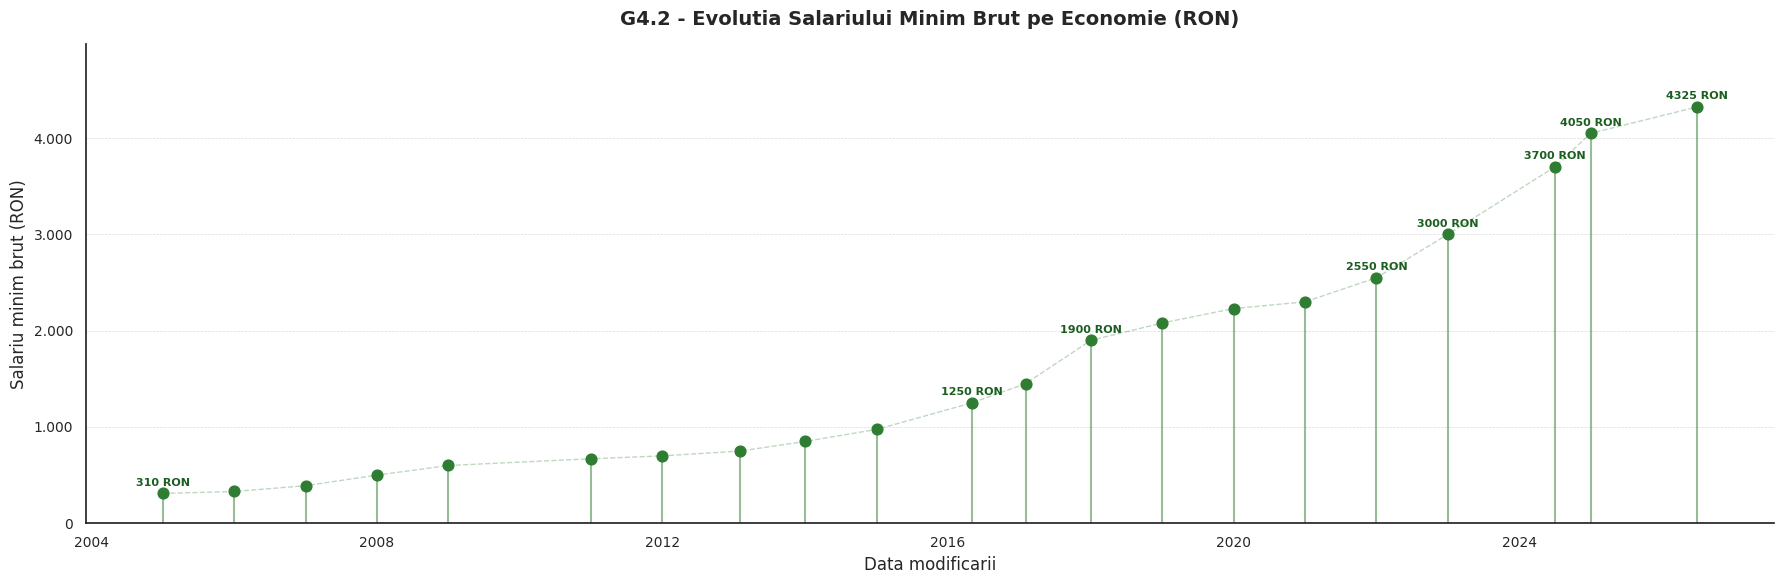

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_s = df_sal_min.dropna(subset=['salariu_minim_brut_ron']).sort_values('data')

# Linii verticale de la 0 la valoare
ax.vlines(df_s['data'], 0, df_s['salariu_minim_brut_ron'],
          color=CUL['verde'], linewidth=1.5, alpha=0.5)

# Puncte
ax.scatter(df_s['data'], df_s['salariu_minim_brut_ron'],
           color=CUL['verde'], s=60, zorder=5)

# Linie de conectare subtila
ax.plot(df_s['data'], df_s['salariu_minim_brut_ron'],
        color=CUL['verde'], linewidth=1, linestyle='--', alpha=0.3, zorder=3)

# Etichete doar la salturi > 200 RON
prev = 0
for _, row in df_s.iterrows():
    val = row['salariu_minim_brut_ron']
    if val - prev > 200:
        ax.text(row['data'], val + 60,
                f"{int(val)} RON",
                ha='center', va='bottom', fontsize=8, color='#1B5E20', fontweight='bold')
    prev = val

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Data modificarii', fontsize=12)
ax.set_ylabel('Salariu minim brut (RON)', fontsize=12)
ax.set_title('G4.2 - Evolutia Salariului Minim Brut pe Economie (RON)',
             fontsize=14, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.set_ylim(0, df_s['salariu_minim_brut_ron'].max() * 1.15)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G4.2 – Evoluția Salariului Minim Brut pe Economie (RON)

Graficul tip *lollipop* surprinde fiecare **decizie discreționară de majorare**,
evidențiind atât ritmul creșterilor, cât și frecvența intervențiilor politice
pe piața muncii.

**Creștere nominală de ≈ 14 ori în 20 de ani:**
De la **310 RON** în 2005 la **4.325 RON** în 2026 – o creștere impresionantă
în termeni nominali. Ajustat cu inflația cumulată din această perioadă, câștigul
real este semnificativ, dar mai modest – estimat la ≈ 3–4 ori în putere de cumpărare.

**Faza 1 (2005–2012): creșteri mici și regulate**
Tulpinile sunt scurte și echidistante – majorări anuale de ordinul 50–100 RON,
în linie cu productivitatea și inflația. Logica era graduală și relativ predictibilă
pentru angajatori.

**Faza 2 (2013–2017): accelerarea politică**
Saltul de la ≈ 750 RON la **1.900 RON** în svârful anului 2017 marchează
intrarea salariului minim în sfera deciziei politice populiste. Tulpinile devin
brusc mai lungi – creșterile depășesc cu mult ritmul productivității, generând
presiuni inflaționiste și comprimând diferențialul față de salariile medii.

**Faza 3 (2018–2022): consolidare și noi impulsuri**
Ritmul se moderează ușor după șocul 2017, dar rămâne susținut. Ajungerea la
**2.550 RON** în 2022 coincide cu presiunile inflaționiste post-COVID – majorările
devin parțial o reacție la erodarea puterii de cumpărare, nu doar o decizie
redistributivă.

**Faza 4 (2023–2026): salt spre convergența europeană**
Cele mai lungi tulpini din grafic: **3.000 → 3.700 → 4.050 → 4.325 RON** în
numai trei ani. Această accelerare este parțial susținută de **Directiva UE
privind salariile minime adecvate** (2022), care împinge statele membre spre
un nivel de cel puțin 50% din salariul median național.

În termeni europeni, salariul minim românesc a depășit **865 EUR/lună** (la
cursul actual), apropiindu-se de Bulgaria și depășind unele state non-euro din
regiune – o schimbare semnificativă față de statutul de *cea mai ieftină forță
de muncă din UE* din anii 2000.

**Risc structural:** Creșterile frecvente și ample ale salariului minim, dacă
depășesc ritmul productivității, pot eroda competitivitatea exporturilor,
alimenta inflația prin costuri și accelera înlocuirea forței de muncă cu
automatizare în sectoarele cu marjă redusă.

#### G4.3 - Câștigul Salarial Mediu Net Lunar (RON, 2000–2025)
**Tipul graficului:** Linie cu fill și medie mobilă  
**Mesajul:** Salariul net mediu a crescut de ~34× în 25 de ani - de la 173 RON (2000) la ~5.900 RON (2025).


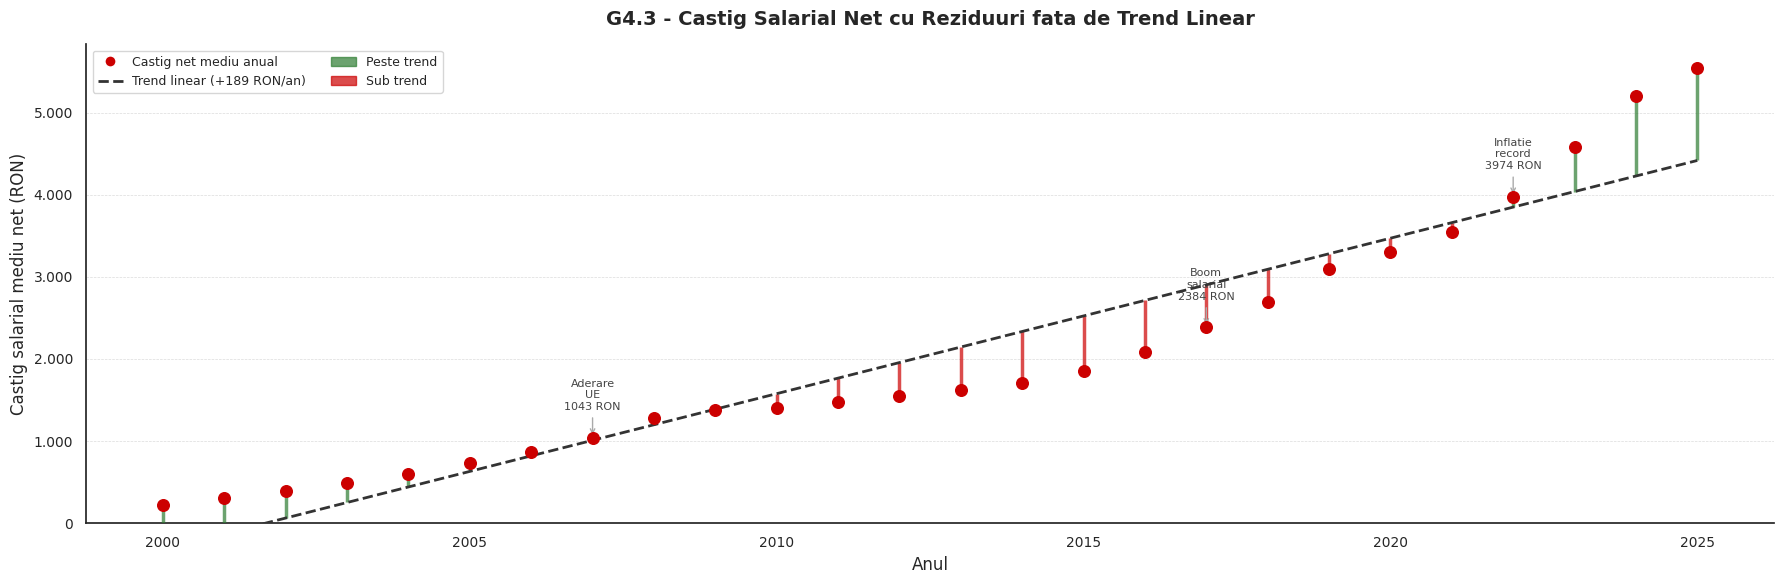

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

import numpy as np

df_c = df_castig.copy()
df_c['an'] = df_c['data'].dt.year
df_an = df_c.groupby('an')['castig_net_total_ron'].mean().reset_index()
df_an.columns = ['an', 'medie']

# Regresia liniara
z = np.polyfit(df_an['an'], df_an['medie'], 1)
p = np.poly1d(z)
df_an['trend'] = p(df_an['an'])
df_an['reziduu'] = df_an['medie'] - df_an['trend']

# Linii de reziduu: de la valoarea reala la trend
for _, row in df_an.iterrows():
    culoare = CUL['verde'] if row['reziduu'] > 0 else CUL['ro']
    ax.vlines(row['an'], row['trend'], row['medie'],
              color=culoare, linewidth=2.5, alpha=0.7, zorder=3)

# Trend
x_reg = np.linspace(df_an['an'].min(), df_an['an'].max(), 100)
ax.plot(x_reg, p(x_reg), color='#333333', linewidth=2,
        linestyle='--', label=f'Trend linear (+{z[0]:.0f} RON/an)', zorder=4)

# Puncte
ax.scatter(df_an['an'], df_an['medie'],
           color=CUL['ro'], s=70, zorder=6, label='Castig net mediu anual')

# Grid subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Etichete la ani cheie
for an_ref, label in [(2007,'Aderare\nUE'), (2017,'Boom\nsalarial'), (2022,'Inflatie\nrecord')]:
    val = df_an[df_an['an']==an_ref]['medie'].values
    if len(val):
        ax.annotate(f'{label}\n{val[0]:.0f} RON',
                    xy=(an_ref, val[0]),
                    xytext=(0, 20), textcoords='offset points',
                    ha='center', fontsize=8, color='#444444',
                    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))

import matplotlib.patches as mpatches
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.7, label='Peste trend')
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.7, label='Sub trend')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Castig salarial mediu net (RON)', fontsize=12)
ax.set_title('G4.3 - Castig Salarial Net cu Reziduuri fata de Trend Linear',
             fontsize=14, fontweight='bold', pad=14)

from matplotlib.lines import Line2D
l_trend = Line2D([0],[0], color='#333333', linewidth=2,
                 linestyle='--', label=f'Trend linear (+{z[0]:.0f} RON/an)')
l_punct = Line2D([0],[0], marker='o', color='w', markerfacecolor=CUL['ro'],
                 markersize=8, label='Castig net mediu anual')
ax.legend(handles=[l_punct, l_trend, p_v, p_r],
          fontsize=9, loc='upper left', ncol=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

### Interpretare G4.3 – Câștig Salarial Net cu Reziduuri față de Trend Linear

Graficul suprapune **evoluția salariului net mediu** peste un trend linear de
**+189 RON/an** – ritmul mediu structural de creștere pe 25 de ani.
Tulpinile verzi arată anii când salariile au depășit trendul; cele roșii, când
au rămas în urmă. Este, în esență, o hartă a **câștigurilor și pierderilor
de putere de cumpărare relativă**.

**Trendul de +189 RON/an: o referință utilă, dar limitată**
Valoarea de 189 RON/an reprezintă media creșterilor nominale pe întreaga
perioadă. Întrucât inflația nu a fost constantă, un an cu reziduu pozitiv
nu înseamnă neapărat câștig real – poate fi pur nominal. Totuși, trendul
servește ca **linie de bază** pentru detectarea accelerărilor și decelerărilor.

**2000–2007: oscilații în jurul trendului**
Salariile alternau între ușor peste și ușor sub trend – o perioadă de creștere
relativ echilibrată față de traiectoria istorică. Aderarea UE (2007, ≈ 1.043 RON)
coincide cu o mică depășire pozitivă, reflectând optimismul și presiunile salariale
din acel moment.

**2008–2016: o decadă sub trend (reziduuri roșii persistente)**
Cea mai lungă perioadă de reziduuri negative consecutive. Criza a comprimat
salariile reale, iar recuperarea a fost lentă. Graficul arată că, deși salariile
creșteau în termeni absoluți, **nu țineau pasul cu ritmul istoric** – o pierdere
structurală de putere de cumpărare față de trendul pe termen lung.

**2017: ruptura – "Boom salarial" (≈ 2.384 RON)**
Prima tulpină verde semnificativă după un deceniu. Majorările masive din sectorul
public și creșterea salariului minim impuse politic au împins salariul mediu
brusc peste trend. Reziduu pozitiv mare, dar generat prin decizie administrativă,
nu prin creștere de productivitate – de aceea, sustenabilitatea era discutabilă.

**2018–2021: revenire sub trend**
Inflația accelerată post-2017 a erodat câștigurile nominale, iar salariile au
revenit sub linia de trend – confirmând că "boomul" a fost parțial absorbit de
creșterea prețurilor.

**2022–2025: cele mai mari reziduuri pozitive din serie**
Tulpinile verzi din 2024–2025 sunt cele mai lungi din grafic. Salariul net mediu
(≈ 5.400 RON în 2025) depășește dramatic trendul linear. Paradoxal, eticheta
"Inflație record" (2022, ≈ 3.974 RON) sugerează că o parte din acest "surplus"
față de trend este **compensație nominală pentru inflație** – nu neapărat
creștere reală a puterii de cumpărare.

**Concluzie:** România se află la sfârșitul unui ciclu în care salariile nominale
au crescut spectaculos, dar calitatea acestei creșteri – câtă este reală vs.
nominală – rămâne întrebarea esențială pentru

#### G4.4 - Șomaj vs. Câștig Salarial

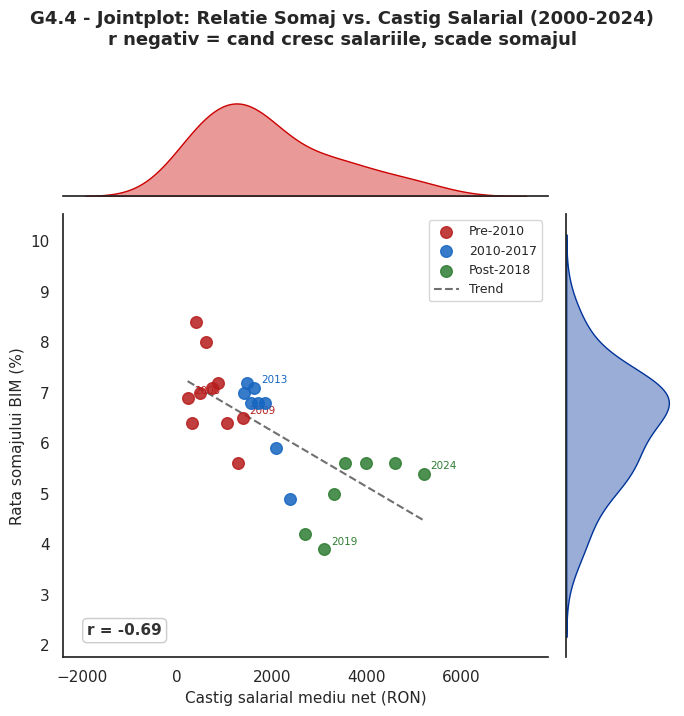

In [ ]:
import numpy as np

# Merge somaj anual + castig anual
df_c_an = df_castig.copy()
df_c_an['an'] = df_c_an['data'].dt.year
df_c_an = df_c_an.groupby('an')['castig_net_total_ron'].mean().reset_index()

df_joint = df_somaj_an.merge(df_c_an, on='an')
df_joint.columns = ['an', 'somaj_pct', 'castig_ron']

# Coloram punctele dupa era
df_joint['era'] = df_joint['an'].apply(
    lambda x: 'Pre-2010' if x < 2010
    else ('2010-2017' if x < 2018 else 'Post-2018'))

culori_joint = {'Pre-2010': '#B71C1C', '2010-2017': '#1565C0', 'Post-2018': '#2E7D32'}

g = sns.JointGrid(data=df_joint, x='castig_ron', y='somaj_pct',
                  height=7, ratio=4)

# Scatter central cu culori per era
for era, culoare in culori_joint.items():
    subset = df_joint[df_joint['era'] == era]
    g.ax_joint.scatter(subset['castig_ron'], subset['somaj_pct'],
                       color=culoare, s=70, alpha=0.85,
                       label=era, zorder=5)

    # Eticheta an
    for _, row in subset.iterrows():
        if row['an'] in [2000, 2009, 2013, 2019, 2024]:
            g.ax_joint.annotate(str(int(row['an'])),
                               xy=(row['castig_ron'], row['somaj_pct']),
                               xytext=(5, 3), textcoords='offset points',
                               fontsize=7.5, color=culoare)

# Linie de regresie
z = np.polyfit(df_joint['castig_ron'], df_joint['somaj_pct'], 1)
p = np.poly1d(z)
x_reg = np.linspace(df_joint['castig_ron'].min(),
                    df_joint['castig_ron'].max(), 100)
g.ax_joint.plot(x_reg, p(x_reg), color='#333333',
                linewidth=1.5, linestyle='--', alpha=0.7,
                label='Trend')

corr = df_joint['castig_ron'].corr(df_joint['somaj_pct'])
g.ax_joint.text(0.05, 0.05, f'r = {corr:.2f}',
                transform=g.ax_joint.transAxes,
                fontsize=11, color='#333333', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='white', edgecolor='#cccccc'))

# Distributii marginale
sns.kdeplot(data=df_joint, x='castig_ron', ax=g.ax_marg_x,
            fill=True, color=CUL['ro'], alpha=0.4)
sns.kdeplot(data=df_joint, y='somaj_pct', ax=g.ax_marg_y,
            fill=True, color=CUL['ue'], alpha=0.4)

g.ax_joint.set_xlabel('Castig salarial mediu net (RON)', fontsize=11)
g.ax_joint.set_ylabel('Rata somajului BIM (%)', fontsize=11)
g.ax_joint.legend(fontsize=9, loc='upper right')

g.fig.suptitle('G4.4 - Jointplot: Relatie Somaj vs. Castig Salarial (2000-2024)\n'
               'r negativ = cand cresc salariile, scade somajul',
               fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretare G4.4 – Jointplot: Relație Șomaj vs. Câștig Salarial (2000–2024)

Jointplot-ul combină **scatterplot-ul** (relația bivariată) cu **distribuțiile
marginale** (histogramele de pe axe), oferind simultan informații despre corelație
și despre cum sunt distribuite individual cele două variabile.

**Corelația r = -0.69: moderată și semnificativă**
Un coeficient de -0.69 confirmă relația inversă așteptată – când salariile cresc,
șomajul tinde să scadă – dar imperfect. Cei ≈ 30% din variație neexplicați de
această relație indică influența altor factori: politici fiscale, emigrație,
structura sectoarelor economice, ciclul european.

**Trei clustere temporale cu logici diferite:**

- **Pre-2010 (roșu):** Concentrat în stânga sus – salarii mici (sub 1.000 RON),
  șomaj ridicat (6–8.5%). Economia era la începutul tranziției spre piața muncii
  modernă; salariile creșteau lent, iar restructurarea industrială menținea
  șomajul ridicat.

- **2010–2017 (albastru):** Deplasare spre dreapta și jos – salarii în creștere
  (1.000–2.500 RON), șomaj în scădere treptată (4.5–7%). Punctul **2013** apare
  ca outlier: șomaj mai ridicat decât ar sugera nivelul salarial, reflectând
  efectele reziduale ale crizei și recuperarea lentă a pieței muncii.

- **Post-2018 (verde):** Clustrul cel mai dispersat pe axa salariilor (2.000–6.000 RON),
  cu șomaj în intervalul 3.8–5.5%. **2019** este punctul optim al seriei – cel mai
  jos șomaj (≈ 3.9%) la un nivel salarial mediu. **2024** se situează la capătul
  drept al graficului: salariu maxim, dar șomaj de ≈ 5.5% – *deasupra* liniei
  de trend, sugerând o decuplare parțială a relației.

**Distribuțiile marginale:**
- **Sus (distribuția salariilor):** Asimetrică la dreapta – majoritatea observațiilor
  se concentrează la salarii mici (anii 2000), cu o coadă lungă spre valorile recente.
- **Dreapta (distribuția șomajului):** Mai simetrică, centrată în jurul a 5–7%,
  confirmând că România a oscilat în acest interval pentru cea mai mare parte
  a perioadei analizate.

**Concluzie – o corelație reală, dar cu limite:**
Relația negativă reflectă în principal **ciclul economic comun**: boom-urile
creează simultan locuri de muncă și presiuni salariale, nu neapărat că salariile
mari *cauzează* scăderea șomajului. Decuplarea din 2024 – salarii record cu
șomaj în creștere – sugerează că mecanismul clasic poate fi perturbat de
emigrație, automatizare sau contracție fiscală.

---
### 🏛️ Capitol 5 - Finanțe Publice

România a depășit limita Maastricht de -3% deficit bugetar în 7 din ultimii 10 ani. Datoria publică rămâne sub 60%, dar traiectoria e ascendentă. Randamentul obligațiunilor reflectă percepția de risc - în creștere față de media UE.


#### G5.1 - Deficit Bugetar: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Bare grupate + linie prag Maastricht (-3%)  
**Mesajul:** România a depășit limita de -3% repetat - și în 2024 a atins -9.3% PIB, cel mai mare din UE.


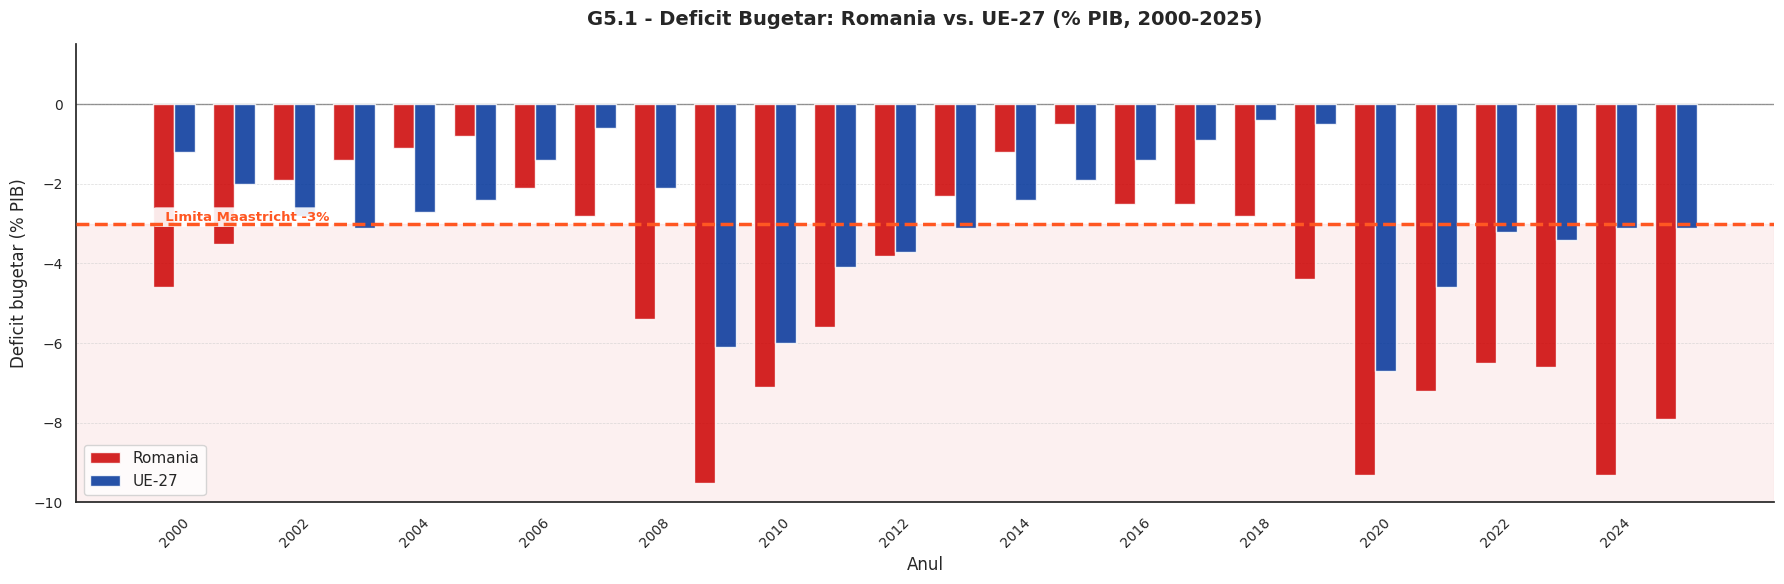

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_d = df_deficit.copy()
x = df_d['an'].values
width = 0.35

bars_ro = ax.bar(x - width/2, df_d['deficit_ro_pct'], width, label='Romania',
                 color=CUL['ro'], alpha=0.85, zorder=3)
bars_ue = ax.bar(x + width/2, df_d['deficit_ue_pct'], width, label='UE-27',
                 color=CUL['ue'], alpha=0.85, zorder=3)

# Zona de incalcare Maastricht (sub -3%) - fundal rosu pal
y_min = min(df_d['deficit_ro_pct'].min(), df_d['deficit_ue_pct'].min()) - 0.5
ax.axhspan(y_min, -3, alpha=0.06, color=CUL['ro'], zorder=0)

# Linia Maastricht mai groasa si mai vizibila
ax.axhline(y=-3, color='#FF5722', linewidth=2.5, linestyle='--', zorder=5)
ax.text(x[0] - 0.3, -3, '  Limita Maastricht -3%',
        ha='left', va='bottom', fontsize=9.5, color='#FF5722',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.9))

# Linie zero
ax.axhline(y=0, color='#555555', linewidth=1, alpha=0.6, zorder=2)

# Grid orizontal subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Deficit bugetar (% PIB)', fontsize=12)
ax.set_title('G5.1 - Deficit Bugetar: Romania vs. UE-27 (% PIB, 2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='lower left')
ax.set_xticks(x[::2])
ax.set_xticklabels(x[::2], rotation=45, fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(y_min, 1.5)

plt.tight_layout()
plt.show()

### Interpretare G5.1 – Deficit Bugetar: România vs. UE-27 (% PIB, 2000–2025)

Linia portocalie punctată – **limita Maastricht de -3% din PIB** – este linia de
referință centrală a graficului. Barele care o depășesc în jos semnalează
**procedură de deficit excesiv (PDE)** și risc de sancțiuni europene.

**Perioada 2002–2007: singura fereastră de conformitate**
România a reușit să se mențină deasupra pragului de -3% pentru câțiva ani
consecutivi, perioadă care a coincis cu negocierile și aderarea la UE.
Disciplina fiscală era, în parte, o condiție externă impusă, nu o alegere
structurală.

**2008–2009: cel mai sever episod fiscal din serie**
Deficitul a sărit de la ≈ -2.5% în 2007 la **≈ -9.5% în 2009** – cel mai adânc
din întreaga serie. Combinația toxică: cheltuieli pre-electorale masive în 2008
urmate de prăbușirea veniturilor în criză. România și UE-27 se prăbușesc simultan,
dar România **mai adânc și mai brusc**.

**2010–2015: ajustare dureroasă**
Reducerea deficitului de la -9.5% la ≈ -0.8% în 2015 s-a realizat prin măsuri
de austeritate severe (reducerea salariilor bugetarilor cu 25%, creșterea TVA),
cu costuri sociale semnificative vizibile și în graficul G4.1 (șomaj ridicat).

**2016–2019: risipirea dividendului fiscal**
În loc să consolideze poziția fiscală, România a reluat cheltuielile pro-ciclice
(majorări salariale în sectorul public, reduceri de taxe). Deficitul a urcat la
**≈ -4.3% în 2019** – *în plină expansiune economică* – o anomalie flagrantă:
țara intra în COVID fără niciun tampon fiscal.

**2020 (COVID): ≈ -9.8% – al doilea minim istoric**
Ambele entități ating deficite masive, dar cu o diferență crucială: **UE-27 a
început recuperarea imediată**, revenind spre -3% până în 2023–2024.
România nu a urmat același traseu.

**2021–2025: divergența structurală**
Aceasta este cea mai îngrijorătoare secțiune a graficului. În timp ce barele
albastre (UE-27) urcă constant spre linia Maastricht, barele roșii rămân
adânc sub ea – **-6% până la -8.6% în 2024**, cel mai mare deficit din UE.
România se află de facto în procedură de deficit excesiv, cu angajamente de
consolidare fiscală multianuale față de Comisia Europeană.

**Concluzie structurală:** Graficul evidențiază că problema fiscală a României
nu este ciclică (legată de crize), ci **structurală**: cheltuielile au crescut
permanent mai repede decât veniturile, iar fereastra de corecție din 2013–2019
a fost irosită. Fără reformă fiscală profundă (baza de impozitare, colectare,
eficiența cheltuielilor), deficitele ridicate riscă să devină permanente.

#### G5.2 - Datorie Publică: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Linie multi-serie cu prag la 60%  
**Mesajul:** România rămâne sub 60%, dar traiectoria e accelerată - de la 18% (2007) la 52% (2025).


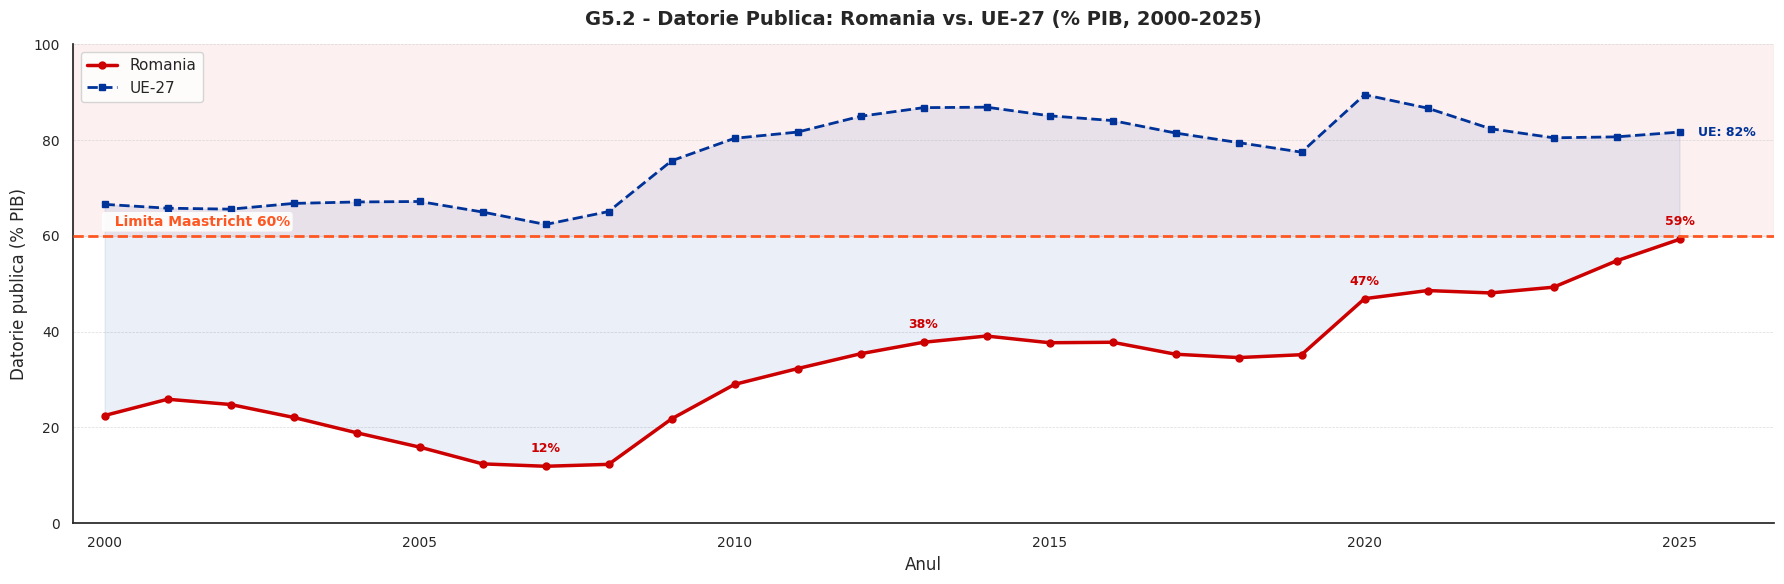

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_dat = df_datorie.copy()

# Zona de depasire Maastricht (peste 60%) - fundal rosu pal
ax.axhspan(60, 105, alpha=0.06, color=CUL['ro'], zorder=0)

# Grid orizontal subtil
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Fill intre cele doua linii - arata convergenta
ax.fill_between(df_dat['an'], df_dat['datorie_ro_pct'], df_dat['datorie_ue_pct'],
                alpha=0.08, color=CUL['ue'], label='_nolegend_')

ax.plot(df_dat['an'], df_dat['datorie_ro_pct'], color=CUL['ro'], linewidth=2.5,
        marker='o', markersize=5, label='Romania', zorder=4)
ax.plot(df_dat['an'], df_dat['datorie_ue_pct'], color=CUL['ue'], linewidth=2,
        linestyle='--', marker='s', markersize=4, label='UE-27', zorder=3)

# Linia Maastricht
ax.axhline(y=60, color='#FF5722', linewidth=2, linestyle='--', zorder=5)
ax.text(df_dat['an'].min(), 61.5, '  Limita Maastricht 60%',
        ha='left', va='bottom', fontsize=10, color='#FF5722', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# Etichete Romania la ani cheie
for an_ref in [2007, 2013, 2020, 2025]:
    val = df_dat[df_dat['an']==an_ref]['datorie_ro_pct'].values
    if len(val) > 0:
        ax.annotate(f'{val[0]:.0f}%', xy=(an_ref, val[0]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color=CUL['ro'], fontweight='bold')

# Eticheta UE-27 la final
val_ue_last = df_dat['datorie_ue_pct'].iloc[-1]
ax.text(df_dat['an'].iloc[-1] + 0.3, val_ue_last,
        f"UE: {val_ue_last:.0f}%", fontsize=9, color=CUL['ue'],
        va='center', fontweight='bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Anul', fontsize=12)
ax.set_ylabel('Datorie publica (% PIB)', fontsize=12)
ax.set_title('G5.2 - Datorie Publica: Romania vs. UE-27 (% PIB, 2000-2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(df_dat['an'].min() - 0.5, df_dat['an'].max() + 1.5)
ax.set_ylim(0, 100)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G5.2 – Datorie Publică: România vs. UE-27 (% PIB, 2000–2025)

Complementar graficului G5.1 (fluxul deficitului), acesta arată **stocul acumulat
al datoriei** – efectul cumulativ al tuturor deficitelor și surplusurilor
istorice. Limita Maastricht de **60% din PIB** este linia de referință.

**2007–2008: cel mai scăzut nivel de datorie din UE (≈ 12–13%)**
România intra în criză cu o datorie publică remarcabil de mică – printre cele mai
reduse din toată Uniunea Europeană. Acest "spațiu fiscal" enorm reprezenta un
avantaj structural excepțional care, din păcate, nu a fost valorificat pentru
a construi stabilizatori contracicici, ci a fost erodat rapid.

**2009–2014: triparea datoriei în 5 ani (12% → 39%)**
Criza a transformat spațiul fiscal în datorie cu o viteză remarcabilă.
Deficitele masive (G5.1) s-au transpus direct în împrumuturi externe, România
apelând la FMI și UE pentru un pachet de asistență financiară în 2009.
Totuși, chiar la vârful acestei acumulări, România rămânea **sub 40% din PIB** –
mult sub limita Maastricht și mult sub UE-27.

**UE-27: structural deasupra limitei Maastricht**
Linia albastră a stat **permanent deasupra pragului de 60%** pe tot parcursul
perioadei analizate – inclusiv în anii de relativă prosperitate pre-criză.
Această realitate evidențiază că Pactul de Stabilitate și Creștere a funcționat
mai degrabă ca aspirație decât ca regulă respectată de statele mari ale blocului.

**2015–2019: stabilizare, dar fără consolidare**
Datoria României s-a stabilizat la ≈ 35–38% din PIB – o poziție confortabilă.
Aceasta era fereastra ideală pentru reformă fiscală și reducere structurală a
deficitului. În schimb, politicile pro-ciclice din 2016–2019 au menținut datoria
ridicând-o ușor, consumând spațiul fiscal fără a-l reconstrui.

**2020 (COVID): salt la 47% – al doilea șoc major**
Pandemia a adăugat ≈ 12 puncte procentuale de datorie într-un singur an.
UE-27 a atins simultan maximul de ≈ 90%, dar a început imediat consolidarea.
România nu a urmat același traseu de reducere.

**2021–2025: convergența spre limita Maastricht (59% în 2025)**
Cea mai îngrijorătoare dinamică din grafic: România se apropie rapid de pragul
de 60% – o limită pe care nu a depășit-o niciodată în istoria sa post-comunistă.
Dat fiind deficitul structural de ≈ 7–9% din PIB (G5.1), **depășirea pragului
Maastricht în 2026 pare inevitabilă** în absența unor măsuri de consolidare
fiscală semnificative.

**Concluzie – o simetrie inversă:**
România și UE-27 descriu traiectorii opuse: UE pornea de sus și a coborât parțial;
România pornea de jos și urcă accelerat. Paradoxul: tocmai țara cu cel mai mic
spațiu fiscal la intrarea în UE riscă să devină una dintre cele mai vulnerabile
la șocuri viitoare, dacă tendința actuală nu este inversată.

#### G5.3 - Randament Obligațiuni Stat 10Y + Rezerve BNR (ax dual)
**Tipul graficului:** Linie randamente (stânga) + linie rezerve (dreapta)  
**Mesajul:** Spread-ul RO față de UE crește - semnalând percepție de risc în creștere. Rezervele BNR tampoanizează.


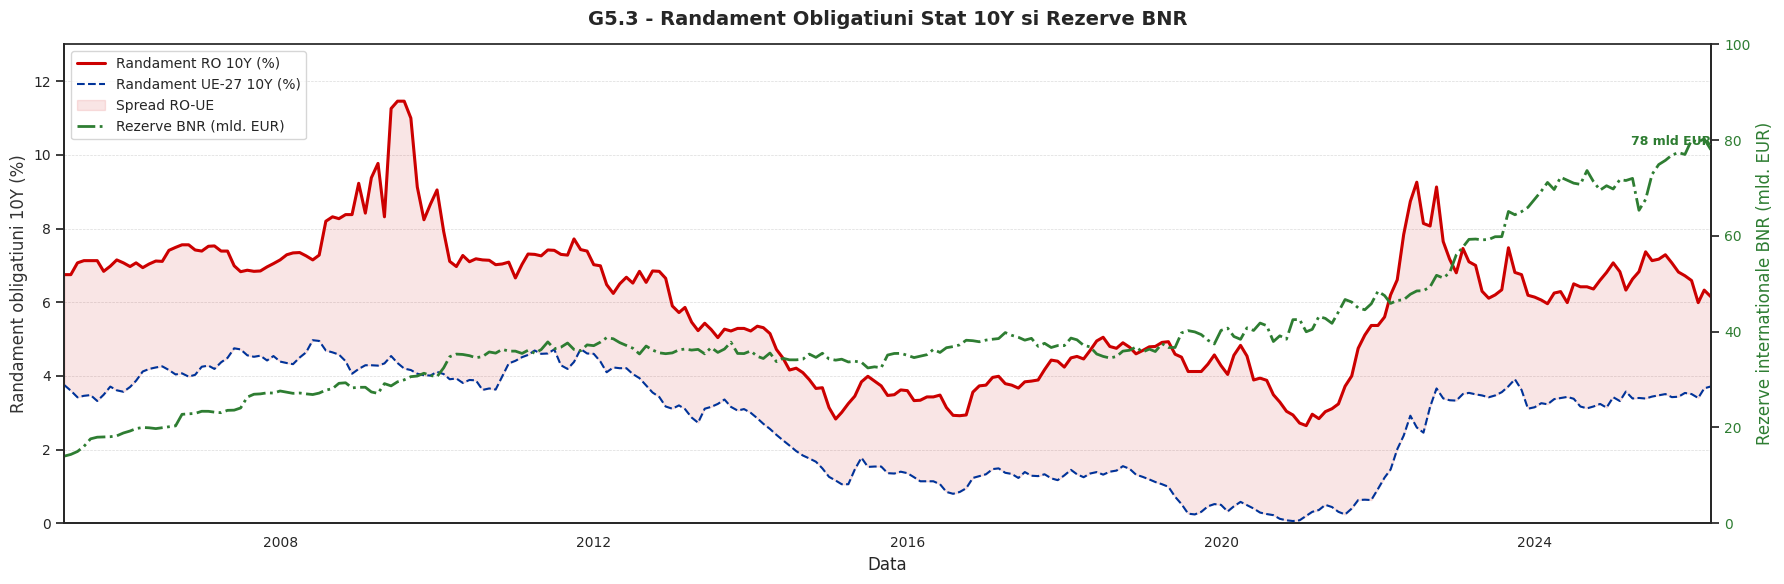

In [ ]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_r = df_rand_rez.dropna(subset=['rand_ro_pct']).copy()

# Grid orizontal subtil doar pe ax1
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.plot(df_r['data'], df_r['rand_ro_pct'],
         color=CUL['ro'], linewidth=2.2, label='Randament RO 10Y (%)', zorder=4)
ax1.plot(df_r['data'], df_r['rand_ue_pct'],
         color=CUL['ue'], linewidth=1.5, linestyle='--',
         label='Randament UE-27 10Y (%)', zorder=3)

# Spread - mai subtil
ax1.fill_between(df_r['data'], df_r['rand_ro_pct'], df_r['rand_ue_pct'],
                 where=df_r['rand_ro_pct'] > df_r['rand_ue_pct'],
                 alpha=0.10, color=CUL['ro'], label='Spread RO-UE')

ax1.set_ylabel('Randament obligatiuni 10Y (%)', color='#333333', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_ylim(0, 13)

ax2 = ax1.twinx()
df_rez_plot = df_rand_rez.dropna(subset=['rezerve_mld_eur'])

# Rezerve - doar linia, fara fill
ax2.plot(df_rez_plot['data'], df_rez_plot['rezerve_mld_eur'],
         color=CUL['verde'], linewidth=2, linestyle='-.',
         label='Rezerve BNR (mld. EUR)', zorder=2)

# Eticheta finala pe linie
ax2.text(df_rez_plot['data'].iloc[-1], df_rez_plot['rezerve_mld_eur'].iloc[-1] + 1,
         f"{df_rez_plot['rezerve_mld_eur'].iloc[-1]:.0f} mld EUR",
         fontsize=9, color=CUL['verde'], fontweight='bold', ha='right')

ax2.set_ylabel('Rezerve internationale BNR (mld. EUR)', color=CUL['verde'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['verde'], labelsize=10)
ax2.yaxis.grid(False)
ax2.set_ylim(0, 100)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.set_xlabel('Data', fontsize=12)
ax1.set_title('G5.3 - Randament Obligatiuni Stat 10Y si Rezerve BNR',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(df_r['data'].min(), df_r['data'].max())
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G5.3 – Randament Obligațiuni Stat 10Y și Rezerve BNR

Graficul combină trei serii interdependente: **randamentul obligațiunilor
românești** (costul finanțării statului), **randamentul mediu UE-27** (referința
externă) și **rezervele internaționale BNR** (capacitatea de reziliență).
Zona roz reprezintă **spread-ul RO–UE** – prima de risc pe care România o
plătește față de media europeană.

**2009: vârful crizei de finanțare (≈ 11.5%)**
Cel mai dramatic moment din serie. Randamentele au explodat pe fondul pierderii
de încredere a investitorilor, deficitului uriaș și vulnerabilităților externe.
La acel moment, România plătea cu ≈ 7–8 puncte procentuale *mai mult* decât
media UE – o primă de risc de urgență, nu de echilibru.
Acordul stand-by cu FMI din 2009 a stabilizat situația și a contribuit la
reancorarea așteptărilor.

**2013–2019: cea mai bună perioadă de finanțare**
Spread-ul s-a îngust dramatic – la ≈ 1.5–2 puncte procentuale față de UE-27 –
reflectând consolidarea fiscală, inflația scăzută și mediul global de dobânzi
reduse impus de BCE. Randamentul românesc a coborât la ≈ 3%, cel mai mic nivel
din serie. Această fereastră reprezenta momentul optim pentru refinanțarea
datoriei pe termen lung la costuri minime – o oportunitate valorificată doar parțial.

**2015–2020: divergența randamentelor UE-27**
Politica de dobânzi zero/negative a BCE a împins randamentele europene spre
0–1%, creând un efect de *bază* care a lărgit artificial spread-ul RO–UE chiar
și când România performa rezonabil. Este important de interpretat spread-ul
cu prudență în această perioadă: o diferență de 3 pp față de randamente de 0%
nu are același sens ca o diferență de 3 pp față de randamente de 4–5%.

**2021–2022: reaccelerarea costurilor de finanțare (≈ 9%)**
Concomitent cu creșterea globală a dobânzilor (Fed, BCE), deteriorarea fiscală
internă a amplificat creșterea randamentelor românești. Statul român plătea din
nou ≈ 9% pe datoria pe 10 ani – niveluri comparabile cu episodul de criză din
2009, dar de data aceasta fără un pachet extern de salvare.

**Rezervele BNR: de la 20 la 78 mld. EUR – un scut în expansiune**
Linia verde arată o creștere aproape continuă a rezervelor internaționale, cu
o accelerare notabilă post-2020 (de la ≈ 40 la **78 mld. EUR** în 2025).
Rezervele mari oferă BNR capacitatea de a interveni pe piața valutară și
conferă credibilitate externă. Paradoxul: rezervele record coexistă cu deficite
fiscale record – sugerând că soliditatea externă a BNR *maschează* fragilitatea
fiscală a statului.

**Concluzie – două povești paralele:**
Graficul ilustrează o tensiune structurală: BNR construiește un scut extern
din ce în ce mai solid (rezerve), în timp ce Ministerul Finanțelor acumulează
vulnerabilități fiscale crescânde (deficite, datorie). Pe termen lung, niciun
nivel de rezerve nu poate substitui disciplina fiscală – piețele vor prețui
riscul suveran al României în funcție de traiectoria bugetară, nu de rezervele BNR.

#### G5.4 - România vs. UE pe 5 indicatori (2024)

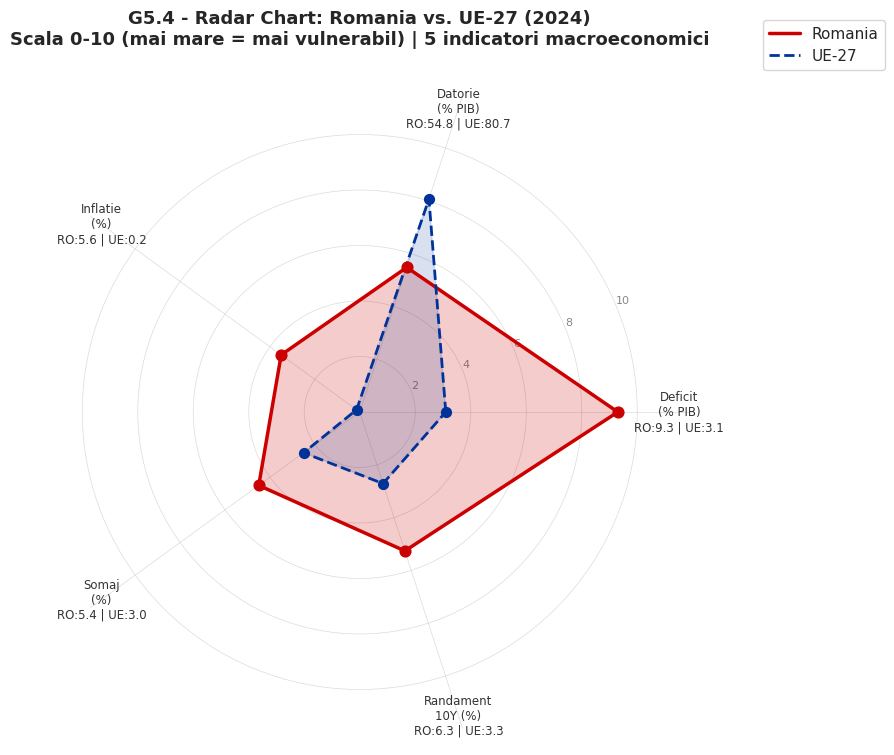

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(polar=True))
sns.set(style='white')

# Cei 5 indicatori pentru 2024 (sau cel mai recent an disponibil)
indicatori = ['Deficit\n(% PIB)', 'Datorie\n(% PIB)', 'Inflatie\n(%)',
              'Somaj\n(%)', 'Randament\n10Y (%)']

def get_val(df, col, an):
    r = df[df['an'] == an][col].values
    return float(r[0]) if len(r) else None

an_ref = 2024

ro_vals_raw = [
    abs(get_val(df_deficit,  'deficit_ro_pct', an_ref) or 0),
    get_val(df_datorie,  'datorie_ro_pct', an_ref) or 0,
    get_val(df_inflatie, 'rata_inflatie_pct', an_ref) or 0,
    get_val(df_somaj_an, 'somaj_pct', an_ref) or 0,
    df_rand[df_rand['data'].dt.year == an_ref]['rand_ro_pct'].mean()
]

ue_vals_raw = [
    abs(get_val(df_deficit, 'deficit_ue_pct', an_ref) or 0),
    get_val(df_datorie, 'datorie_ue_pct', an_ref) or 0,
    get_val(df_hicp[df_hicp['data'].dt.year == an_ref],
            'hicp_ue', an_ref) if False else
        df_hicp[df_hicp['data'].dt.year == an_ref]['hicp_ue'].mean(),
    3.0,  # somaj UE aproximativ 2024
    df_rand[df_rand['data'].dt.year == an_ref]['rand_ue_pct'].mean()
]

# Normalizare 0-10 (mai mare = mai rau pentru toti indicatorii)
maxime = [10, 100, 16, 12, 12]

ro_norm = [min(v/m*10, 10) for v, m in zip(ro_vals_raw, maxime)]
ue_norm = [min(v/m*10, 10) for v, m in zip(ue_vals_raw, maxime)]

N = len(indicatori)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ro_norm += ro_norm[:1]
ue_norm += ue_norm[:1]

ax.plot(angles, ro_norm, color=CUL['ro'], linewidth=2.5,
        linestyle='-', label='Romania')
ax.fill(angles, ro_norm, color=CUL['ro'], alpha=0.2)

ax.plot(angles, ue_norm, color=CUL['ue'], linewidth=2,
        linestyle='--', label='UE-27')
ax.fill(angles, ue_norm, color=CUL['ue'], alpha=0.15)

# Puncte pe fiecare vertex
ax.scatter(angles[:-1], ro_norm[:-1], color=CUL['ro'], s=60, zorder=5)
ax.scatter(angles[:-1], ue_norm[:-1], color=CUL['ue'], s=50, zorder=5)

# Etichete cu valorile reale
for i, (angle, ind, rv, uv) in enumerate(
        zip(angles[:-1], indicatori, ro_vals_raw, ue_vals_raw)):
    ax.text(angle, 11.5, f'{ind}\nRO:{rv:.1f} | UE:{uv:.1f}',
            ha='center', va='center', fontsize=8.5,
            color='#333333')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([''] * N)
ax.set_ylim(0, 12)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'],
                   fontsize=8, color='#888888')
ax.grid(color='#cccccc', linewidth=0.5, alpha=0.7)
ax.spines['polar'].set_visible(False)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title(f'G5.4 - Radar Chart: Romania vs. UE-27 ({an_ref})\n'
             'Scala 0-10 (mai mare = mai vulnerabil) | 5 indicatori macroeconomici',
             fontsize=13, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

### Interpretare G5.4 – Radar Chart: România vs. UE-27 (2024)

Graficul radar sintetizează **profilul de vulnerabilitate macroeconomică** al
României față de media UE-27 în 2024, pe 5 dimensiuni normalizate la o scală
0–10 (valoare mai mare = vulnerabilitate mai mare). Este, în esență, un rezumat
vizual al tuturor graficelor G5.1–G5.3.

**Singura dimensiune favorabilă României: Datoria publică**
UE-27 are un scor de vulnerabilitate semnificativ mai mare la datorie
(80.7% PIB vs. 54.8% PIB pentru România). Aceasta este *singura* axă pe care
poligonul albastru depășește cel roșu – și, după cum arată G5.2, acest avantaj
se erodează rapid prin acumularea deficitelor.

**Cele 4 dimensiuni în care România este mai vulnerabilă:**

- **Deficit (RO: 9.3% vs. UE: 3.1%)** – diferența cea mai drastică din grafic.
  România are un deficit de aproape *3 ori* mai mare decât media UE, plasând-o
  în procedură de deficit excesiv și limitând capacitatea de răspuns la șocuri viitoare.

- **Randament 10Y (RO: 6.3% vs. UE: 3.3%)** – costul finanțării datoriei publice
  este aproape dublu față de media europeană. Această diferență reflectă prima
  de risc suveran pe care investitorii o cer pentru expunerea la România,
  amplificând efectul de bulgăre de zăpadă al datoriei.

- **Inflație (RO: 5.6% vs. UE: 0.2%)** – în 2024, România era practic *singura*
  economie europeană cu inflație semnificativă, în timp ce zona euro revenise
  aproape la deflație. Persistența inflației interne indică dezechilibre structurale
  (cerere internă excesivă, indexări salariale) pe care politica monetară singură
  nu le poate corecta.

- **Șomaj (RO: 5.4% vs. UE: 3.0%)** – diferența este mai mică decât la celelalte
  dimensiuni, dar semnificativă în context: un șomaj mai ridicat decât media UE
  în condițiile unei piețe a muncii tensionate sugerează probleme de *potrivire*
  (mismatch) structurală, nu doar de ciclu economic.

**Citirea integrată a radarului:**
Poligonul roșu (România) este mai mare în 4 din 5 dimensiuni, dar asimetric:
punctul de maximă vulnerabilitate este **deficitul** (braț lung spre dreapta),
în timp ce datoria rămâne singurul scut. Problema este că cele două sunt
conectate: deficitul de azi este datoria de mâine.

**Concluzie:** Radarui confirmă că România intră în a doua jumătate a deceniului
cu un **profil macroeconomic dezechilibrat** față de partenerii europeni –
nu catastrofic, dar cu vulnerabilități care se auto-amplifică dacă nu sunt
adresate printr-o consolidare fiscală credibilă și susținută.

#### G5.5 - Ani cu deficit peste limita Maastricht

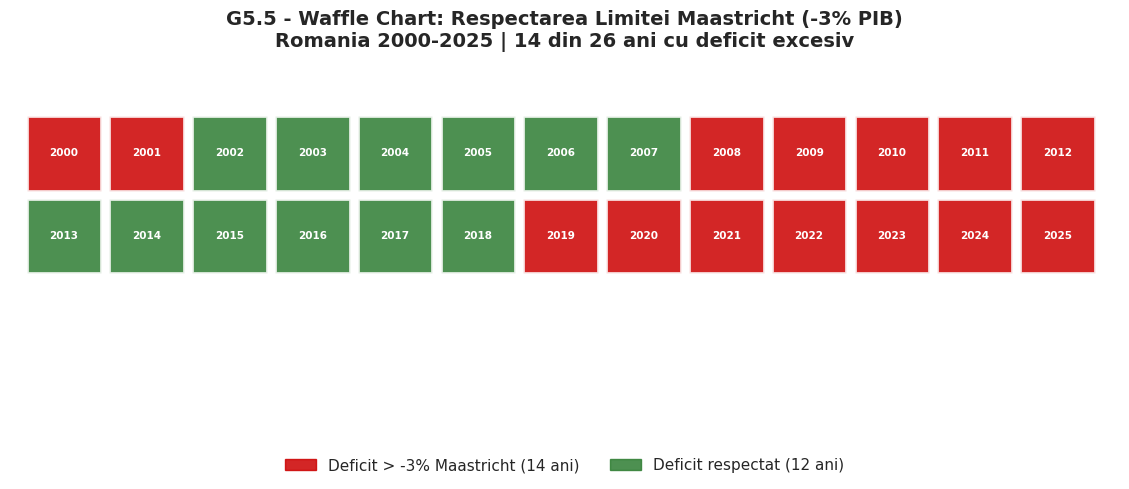

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.set(style='white')
ax.set_aspect('equal')
ax.axis('off')

ani_deficit = df_deficit.sort_values('an').copy()
total_ani = len(ani_deficit)
cols = 13

for idx, (_, row) in enumerate(ani_deficit.iterrows()):
    col = idx % cols
    lin = idx // cols
    depasit = row['deficit_ro_pct'] < -3
    culoare = CUL['ro'] if depasit else CUL['verde']
    an = int(row['an'])

    rect = plt.Rectangle((col, -lin), 0.9, 0.9,
                          facecolor=culoare, alpha=0.85,
                          edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + 0.45, -lin + 0.45, str(an),
            ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')

ax.set_xlim(-0.2, cols + 0.2)
ax.set_ylim(-total_ani//cols - 1.2, 1.5)

ani_dep = (ani_deficit['deficit_ro_pct'] < -3).sum()
ani_ok  = total_ani - ani_dep

import matplotlib.patches as mpatches
p_r = mpatches.Patch(color=CUL['ro'],    alpha=0.85,
                     label=f'Deficit > -3% Maastricht ({ani_dep} ani)')
p_v = mpatches.Patch(color=CUL['verde'], alpha=0.85,
                     label=f'Deficit respectat ({ani_ok} ani)')
ax.legend(handles=[p_r, p_v], loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=11,
          ncol=2, frameon=False)

ax.set_title(f'G5.5 - Waffle Chart: Respectarea Limitei Maastricht (-3% PIB)\n'
             f'Romania 2000-2025 | {ani_dep} din {total_ani} ani cu deficit excesiv',
             fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

### Interpretare G5.5 – Waffle Chart: Respectarea Limitei Maastricht (-3% PIB)

Simplitatea vizuală a acestui grafic este înșelătoare – în spatele celor 26 de
pătrate se ascunde o **narațiune despre disciplina fiscală structurală** a României.

**Scorul: 12 ani conformi vs. 14 ani cu deficit excesiv**
România a respectat limita Maastricht în mai puțin de jumătate din anii analizați –
o rată de conformitate de **46%**, semnificativ sub așteptările unui stat membru UE
cu angajamente clare asumate prin Tratatul de la Maastricht.

**Două "insule verzi" și trei "zone roșii":**

- **2000–2001 (roșu):** Deficite moștenite din perioada de tranziție, înainte ca
  disciplina pre-aderare să producă efecte.

- **2002–2007 (verde – prima insulă):** Cea mai lungă perioadă consecutivă de
  conformitate – **6 ani**. Presiunea externă a procesului de aderare la UE a
  funcționat ca ancora fiscală. România și-a dovedit că poate respecta regulile
  atunci când există un stimulent extern puternic.

- **2008–2012 (roșu):** Criza financiară globală și cheltuielile electorale
  pre-criză au rupt șirul verde. 5 ani consecutivi de deficit excesiv, cu vârful
  în 2009 (-9.5% PIB).

- **2013–2018 (verde – a doua insulă):** A doua perioadă de conformitate,
  obținută prin austeritate dureroasă și condiționată de angajamentele față de
  FMI și Comisia Europeană. Din nou, disciplina a venit *din exterior*, nu
  dintr-un consens intern privind sustenabilitatea fiscală.

- **2019–2025 (roșu – zona actuală):** Cea mai lungă perioadă de non-conformitate
  consecutivă din serie – **7 ani și în creștere**. Spre deosebire de episodul
  2008–2012 (generat de un șoc extern), această perioadă a început *în plină
  expansiune economică* (2019), ceea ce o face structural mai îngrijorătoare.

**Concluzia graficului:**
Cele două insule verzi au un numitor comun: **constrângere externă** (aderare UE,
respectiv program FMI). În absența acesteia, România a revenit invariabil la
deficite excesive. Întrebarea pentru următorii ani este dacă Procedura de Deficit
Excesiv activă și condiționalitățile asociate fondurilor europene pot constitui
un al treilea ancoraj extern suficient de puternic – sau dacă România are nevoie
de o reformă fiscală internă autentică pentru a ieși din acest tipar.

---
### 📊 Capitol 6 - Piața de Capital și Clima Economică

BVB a crescut de ~6× în 15 ani. PMI-ul Eurozonei anticipează ciclul economic global - România e sincronizată cu acesta.


#### G6.1 - Indicele BET (2010–2026) cu crize adnotate
**Tipul graficului:** Linie cu adnotări și fill  
**Mesajul:** BET a pierdut 50% în COVID, a recuperat în 18 luni și a atins maximul istoric în 2026.


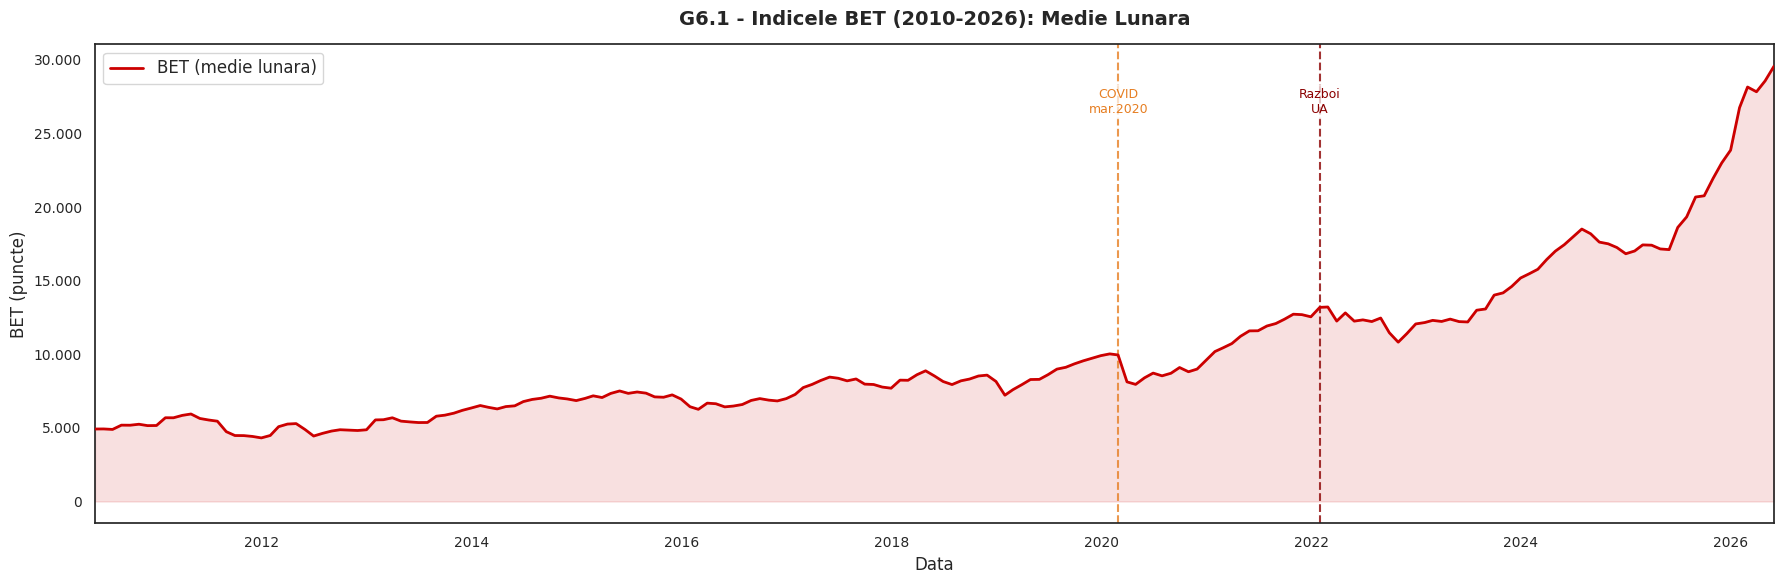

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_b = df_bet_lunar.copy()
ax.plot(df_b['data'], df_b['bet_pret'], color=CUL['ro'], linewidth=2, zorder=4, label='BET (medie lunara)')
ax.fill_between(df_b['data'], df_b['bet_pret'], alpha=0.12, color=CUL['ro'])

# Marcare simpla cu linii verticale si text - fara sageti
events = [
    (pd.Timestamp('2020-03'), 'COVID\nmar.2020', CUL['portoc']),
    (pd.Timestamp('2022-02'), 'Razboi\nUA', '#8B0000'),
]
for data_ev, label, culoare in events:
    ax.axvline(x=data_ev, color=culoare, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(data_ev, df_b['bet_pret'].max() * 0.95, label,
            ha='center', va='top', fontsize=9, color=culoare,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('BET (puncte)', fontsize=12)
ax.set_title('G6.1 - Indicele BET (2010-2026): Medie Lunara', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.set_xlim(df_b['data'].min(), df_b['data'].max())
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G6.1 – Indicele BET (2010–2026): Medie Lunară

Indicele BET – cei mai lichizi 20 de emitenți de la Bursa de Valori București –
a parcurs în 16 ani o transformare de la o piață de frontieră neglijată la un
indice emergent în accelerare. Graficul surprinde **trei faze distincte de evoluție**.

**Faza 1 (2010–2019): creștere lentă pe o piață subdezvoltată**
Timp de aproape un deceniu, BET a crescut modest, de la ≈ 5.000 la ≈ 8.000–9.000
de puncte – o apreciere anualizată de ≈ 5–6%, cu volatilitate redusă și lichiditate
scăzută. BVB era clasificată ca **piață de frontieră** (Frontier Market), ceea ce
o excludea din indecșii majori MSCI și FTSE urmăriți de fondurile internaționale mari.
Investitorii instituționali globali aveau acces limitat sau nu aveau deloc expunere
structurală pe România.

**Faza 2 (2020–2022): catalizatorul structural – promovarea la Emerging Market**
COVID a produs o corecție scurtă și relativ limitată (≈ -20% în martie 2020) –
remarcabil de mică față de alte burse globale, reflectând lichiditatea redusă
și baza restrânsă de investitori. Recuperarea a fost însă rapidă și viguroasă.
Evenimentul structural major: **promovarea BVB la statutul de Piață Emergentă**
de către FTSE Russell (efectivă 2020) și, ulterior, de MSCI, a atras pentru prima
dată fluxuri sistematice de capital indexat internațional. BET a atins ≈ 13.000
de puncte la începutul lui 2022 – aproape triplu față de baza din 2010.

**Războiul din Ucraina (feb. 2022)** a generat o corecție de ≈ 15–20%, rapid
absorbită – semn că noua bază de investitori instituționali a oferit suport
structural, nu doar speculativ.

**Faza 3 (2023–2026): accelerarea fără precedent**
Cea mai spectaculoasă perioadă din istoria BET: de la ≈ 13.000 la **≈ 30.000
de puncte** în aproximativ 3 ani – o apreciere de ≈ 130%. Factorii combinați:
- Intrări continue de capital indexat (fonduri MSCI Emerging Markets)
- Dividende atractive ale companiilor listate (Romgaz, OMV Petrom, bănci)
- Inflație ridicată care a crescut profiturile nominale ale emitenților
- Apetit crescut pentru active din Europa Centrală și de Est

**Notă de prudență:** O parte din creșterea nominală a BET reflectă **inflația
și deprecierea leului** – în termeni reali și în EUR, câștigul este mai modest.
BET este un indice denominat în RON, fără ajustare pentru dividende în varianta
de preț (există și BET-TR, care include reinvestirea dividendelor, cu performanță
chiar mai ridicată).

#### G6.2 - Capitalizare BVB anuală (mld. RON) + PMI Eurozonă (ax dual)
**Tipul graficului:** Bare capitalizare + linie PMI pe ax dual  
**Mesajul:** Capitalizarea BVB crește accelerat după 2020 - parțial corelată cu PMI-ul Eurozonei.


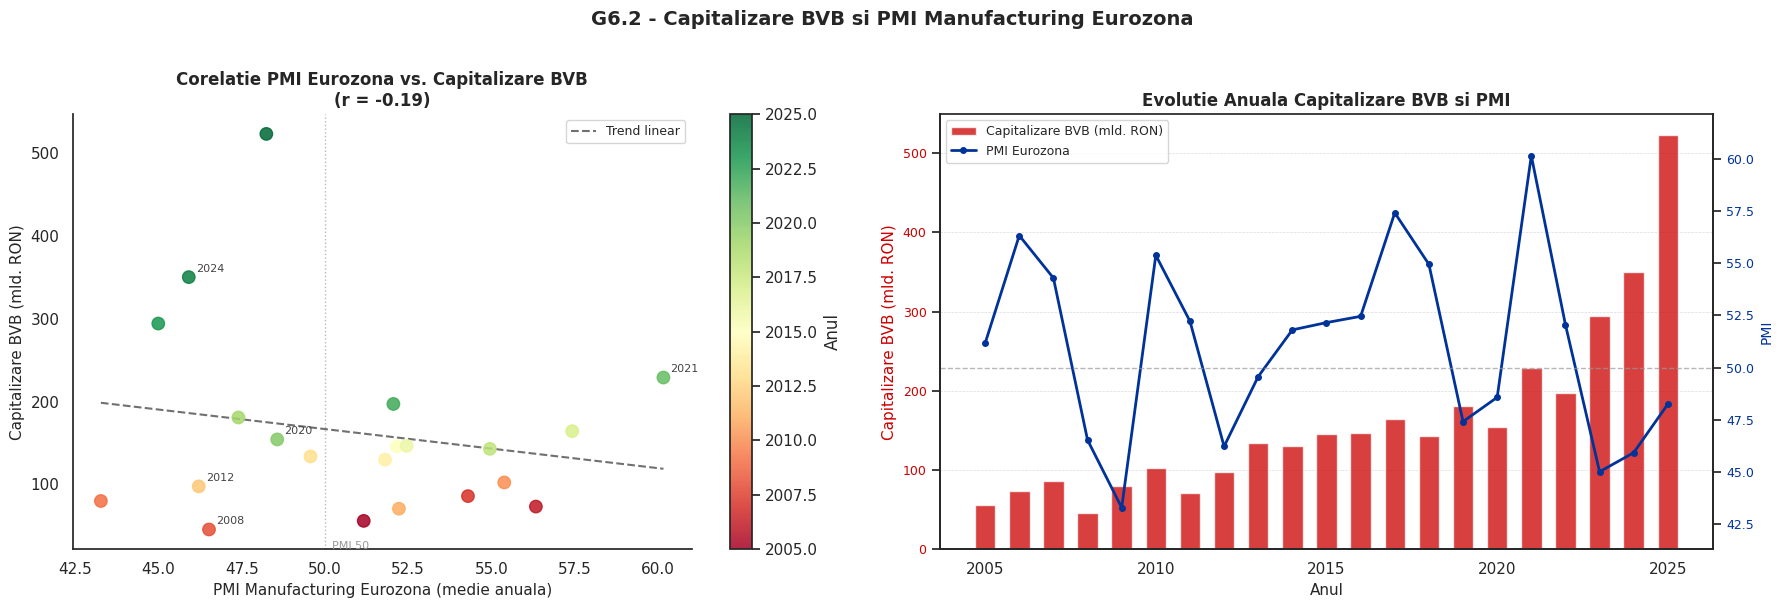

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set(style='white')

df_bp = df_bvb_pmi.dropna(subset=['capitalizare_mld_ron','pmi_eurozona']).copy()

# --- Stânga: Scatter PMI vs Capitalizare cu regresie ---
ax1 = axes[0]

scatter = ax1.scatter(df_bp['pmi_eurozona'], df_bp['capitalizare_mld_ron'],
                      c=df_bp['an'], cmap='RdYlGn', s=80, zorder=5, alpha=0.85)

# Linie regresie
import numpy as np
z = np.polyfit(df_bp['pmi_eurozona'], df_bp['capitalizare_mld_ron'], 1)
p = np.poly1d(z)
x_reg = np.linspace(df_bp['pmi_eurozona'].min(), df_bp['pmi_eurozona'].max(), 100)
ax1.plot(x_reg, p(x_reg), color='#333333', linewidth=1.5,
         linestyle='--', alpha=0.7, label='Trend linear')

# Etichete ani
for _, row in df_bp[df_bp['an'].isin([2008,2012,2020,2021,2024])].iterrows():
    ax1.annotate(str(int(row['an'])),
                 xy=(row['pmi_eurozona'], row['capitalizare_mld_ron']),
                 xytext=(5, 4), textcoords='offset points',
                 fontsize=8, color='#444444')

plt.colorbar(scatter, ax=ax1, label='Anul')
ax1.axvline(x=50, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax1.text(50.2, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 5,
         'PMI 50', fontsize=8, color='#999999')

# CalculeR²
from numpy.polynomial.polynomial import polyfit as npfit
corr = df_bp['pmi_eurozona'].corr(df_bp['capitalizare_mld_ron'])
ax1.set_title(f'Corelatie PMI Eurozona vs. Capitalizare BVB\n(r = {corr:.2f})',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('PMI Manufacturing Eurozona (medie anuala)', fontsize=11)
ax1.set_ylabel('Capitalizare BVB (mld. RON)', fontsize=11)
ax1.legend(fontsize=9)
for spine in ['top','right']:
    ax1.spines[spine].set_visible(False)

# --- Dreapta: Evolutie anuala (line simplu) ---
ax2 = axes[1]
ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax2.xaxis.grid(False)
ax2.set_axisbelow(True)

ax2.bar(df_bp['an'], df_bp['capitalizare_mld_ron'],
        color=CUL['ro'], alpha=0.75, width=0.6, label='Capitalizare BVB (mld. RON)')
ax2_twin = ax2.twinx()
ax2_twin.plot(df_bp['an'], df_bp['pmi_eurozona'],
              color=CUL['ue'], linewidth=2, marker='o', markersize=4,
              label='PMI Eurozona')
ax2_twin.axhline(y=50, color='#999999', linewidth=1, linestyle='--', alpha=0.7)
ax2_twin.set_ylim(df_bp['pmi_eurozona'].min()-2, df_bp['pmi_eurozona'].max()+2)
ax2_twin.set_ylabel('PMI', color=CUL['ue'], fontsize=10)
ax2_twin.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=9)
ax2_twin.yaxis.grid(False)

ax2.set_xlabel('Anul', fontsize=11)
ax2.set_ylabel('Capitalizare BVB (mld. RON)', color=CUL['ro'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=CUL['ro'], labelsize=9)
ax2.set_title('Evolutie Anuala Capitalizare BVB si PMI', fontsize=12, fontweight='bold')
for spine in ['top']:
    ax2.spines[spine].set_visible(False)

lines1, l1 = ax2.get_legend_handles_labels()
lines2, l2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, l1+l2, fontsize=9, loc='upper left')

fig.suptitle('G6.2 - Capitalizare BVB si PMI Manufacturing Eurozona',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretare G6.2 – Capitalizare BVB și PMI Manufacturing Eurozonă

Graficul testează o ipoteză intuitivă: *bursa românească crește când economia
europeană merge bine*. Răspunsul, vizualizat în ambele panouri, este surprinzător.

**Panoul stâng – corelația r = -0.19: practic inexistentă**
Un coeficient de corelație de -0.19 înseamnă că PMI Manufacturing al Eurozonei
**nu explică** evoluția capitalizării BVB. Trendul liniar descendent este mai
degrabă un artefact statistic decât o relație cauzală. Cele 26 de observații
sunt dispersate aleatoriu în jurul liniei de tendință.

**Decodarea scatterplot-ului pe culori (ani):**
- **Roșu/portocaliu (2005–2012):** capitalizare mică, PMI variabil.
  Punctele **2008** și **2012** apar jos–stânga: PMI scăzut (sub 50, contracție
  industrială) și BVB la minime – singurul moment când corelația ar fi funcționat.
- **Verde deschis (2020–2021):** 2021 apare sus-dreapta (PMI ≈ 60 + capitalizare
  în creștere) – o coincidență favorabilă, nu o regulă.
- **Verde intens (2024–2025):** cel mai paradoxal cluster – **capitalizare record
  (350–520 mld. RON) cu PMI sub 50** (industria europeană în contracție).
  Exact opusul a ceea ce corelația pozitivă ar prezice.

**Panoul drept – evoluția temporală confirmă decuplarea**
Barele roșii (BVB) și linia albastră (PMI) evoluează tot mai independent în
ultimii ani. Între 2023 și 2025, PMI Eurozonă oscilează în zona de contracție
(44–47), în timp ce capitalizarea BVB se triplează. Această **decuplare structurală**
are câteva explicații plauzibile:

1. **Compoziția BVB** – dominată de energie (Romgaz, OMV Petrom), financiare
   (BRD, TLV) și utilități – sectoare cu ciclicitate redusă față de industria
   manufacturieră care intră în PMI.
2. **Efectul de promovare la Emerging Market** – fluxurile de capital indexat
   (MSCI, FTSE) sunt determinate de rebalansările periodice ale fondurilor,
   nu de ciclul industrial european.
3. **Câștiguri nominale inflate** – BVB este denominată în RON; inflația ridicată
   din România umflă profiturile și capitalizarea în termeni nominali.
4. **Creșterea investitorului local** – fondurile de pensii și investitorii retail
   români au crescut ca bază, reducând dependența de sentimentul european.

**Concluzie:** BVB nu este o "piață satelit" a ciclului industrial european.
Evoluția sa recentă este mai bine explicată de factori structurali interni și
de fluxuri de capital indexat decât de indicatori de conjunctură ai Eurozonei.
Această independență poate fi un avantaj în perioadele de slăbiciune europeană,
dar și un risc în cazul unei corecții bruște a fluxurilor de capital emergent.

---
### 👥 Capitol 7 - Demografie: Bomba cu Ceas

Convergența economică se construiește pe un fundament care se surpă. România pierde simultan prin natalitate scăzută și emigrație masivă - un declin demografic structural.


#### G7.1 - Piramida Vârstelor: 2003 vs. 2024
**Tipul graficului:** Barh back-to-back (masculin stânga, feminin dreapta)  
**Mesajul:** Piramida s-a transformat dintr-o formă clasică în una de 'urnă' - baza s-a îngust semnificativ, vârful s-a lărgit.


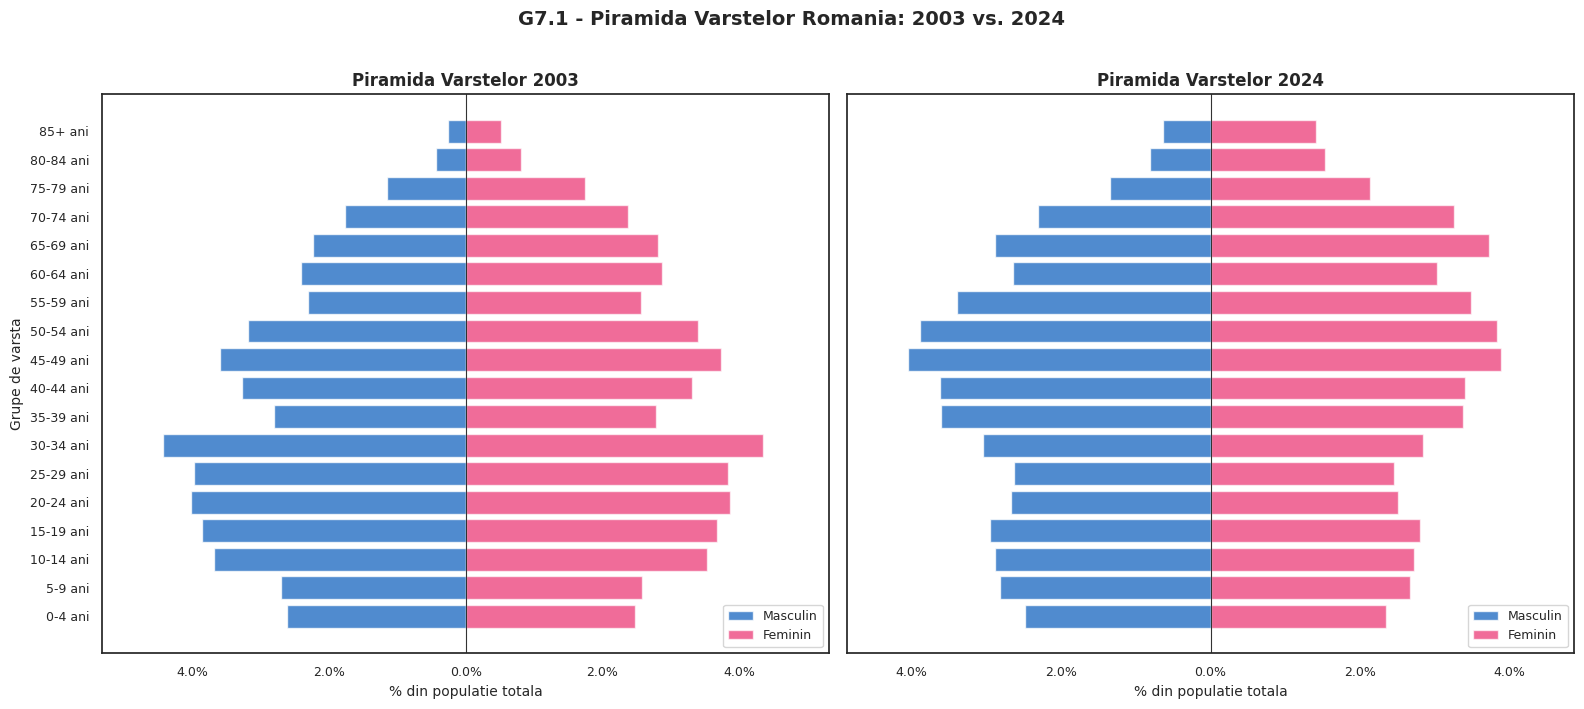

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set(style='white')

for idx, an_ref in enumerate([2003, 2024]):
    ax = axes[idx]
    df_an = df_pop[df_pop['an'] == an_ref].copy()

    total = df_an['populatie'].sum()
    grupe_ordonate = [g for g in ORDINE_GRUPE if g in df_an['grupa_varsta'].values]

    masc_vals, fem_vals, grupe_label = [], [], []
    for g in grupe_ordonate:
        m_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Masculin')]['populatie'].sum()
        f_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Feminin')]['populatie'].sum()
        masc_vals.append(-m_val / total * 100)
        fem_vals.append(f_val / total * 100)
        g_label = g.replace('sipeste','+').replace('_','-')
        grupe_label.append(g_label + ' ani')

    ax.barh(grupe_label, masc_vals, color='#1565C0', alpha=0.75, label='Masculin')
    ax.barh(grupe_label, fem_vals, color='#E91E63', alpha=0.65, label='Feminin')
    ax.axvline(x=0, color='#333333', linewidth=0.8)

    max_val = max(abs(min(masc_vals)), max(fem_vals)) * 1.2
    ax.set_xlim(-max_val, max_val)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x):.1f}%'))
    ax.set_title(f'Piramida Varstelor {an_ref}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% din populatie totala', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.legend(fontsize=9, loc='lower right')

    if idx == 0:
        ax.set_ylabel('Grupe de varsta', fontsize=10)

fig.suptitle('G7.1 - Piramida Varstelor Romania: 2003 vs. 2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretare G7.1 – Piramida Vârstelor România: 2003 vs. 2024

Comparația celor două piramide demografice, la distanță de 21 de ani, ilustrează
una dintre cele mai profunde transformări structurale ale României – o schimbare
care condiționează toate celelalte evoluții economice analizate anterior.

**Forma generală: de la "glonț" la "dreptunghi"**
În 2003, piramida avea o formă mai tradițională – bază relativ largă (populație
tânără), mijloc voluminos, vârf îngust. În 2024, forma tinde spre **dreptunghi
cu bază îngustă** – caracteristică societăților îmbătrânite, cu natalitate scăzută
și speranță de viață în creștere.

**"Decretei" – cohorta vizibilă în ambele piramide**
Generația născută după **Decretul 770/1966** (care interzicea avortul) a produs
un baby-boom în 1967–1973, vizibil ca cea mai voluminoasă cohortă din piramida
2003 la **grupele 30–34 ani**. În 2024, aceeași cohortă (acum **50–59 ani**)
creează proeminența din mijlocul piramidei drepte – un "val" demografic care
se va deplasa spre grupele de vârstă pensionabilă în următorii 10–15 ani,
cu implicații directe pentru sistemul de pensii.

**Baza piramidei: alarmant de îngustă în 2024**
Grupele 0–14 ani din 2024 sunt vizibil mai mici decât cele echivalente din 2003.
Rata natalității a scăzut constant, iar România se confruntă cu un **deficit
de înlocuire** a generațiilor – fiecare cohortă nouă este mai mică decât cea
precedentă. Această tendință comprimă pe termen lung baza de contribuabili la
sistemul de asigurări sociale.

**Asimetria de gen la vârste înaintate**
În ambele piramide, barele roz (feminin) depășesc barele albastre (masculin)
la grupele 65+, reflectând **speranța de viață mai ridicată** a femeilor.
Diferența se accentuează în 2024, pe măsură ce mai mulți bărbați din cohortele
mari supraviețuiesc până la vârste mai înaintate, dar femeile rămân majoritare
în grupele 75+.

**Emigrația – un semnal subtil în piramida 2024**
La grupele de vârstă activă (25–44 ani), barele masculine tind să fie ușor
mai scurte relativ la cele feminine – un efect posibil al **emigrației selective**
(bărbații emigrează mai frecvent pentru muncă). Efectul este greu de izolat
vizual, dar este consistent cu datele de emigrație nete.

**Implicații macroeconomice:**
Piramida din 2024 prefigurează presiuni structurale inevitabile: un raport
de dependență demografică în deteriorare, o bază fiscală în contracție și
o cerere de servicii de sănătate și pensii în creștere – exact contextul în
care deficitele bugetare ridicate (G5.1, G5.5) devin cel mai costisitoare
și mai greu de corectat.

#### G7.2 - Rata Natalității (‰) și Migrație Netă anuală (ax dual)
**Tipul graficului:** Linie ax dual  
**Mesajul:** Natalitatea a scăzut de la 10.3‰ (2000) la 7.2‰ (2024). Migrația netă a intrat în teritoriu pozitiv abia din 2022 - posibil influx din Ucraina.


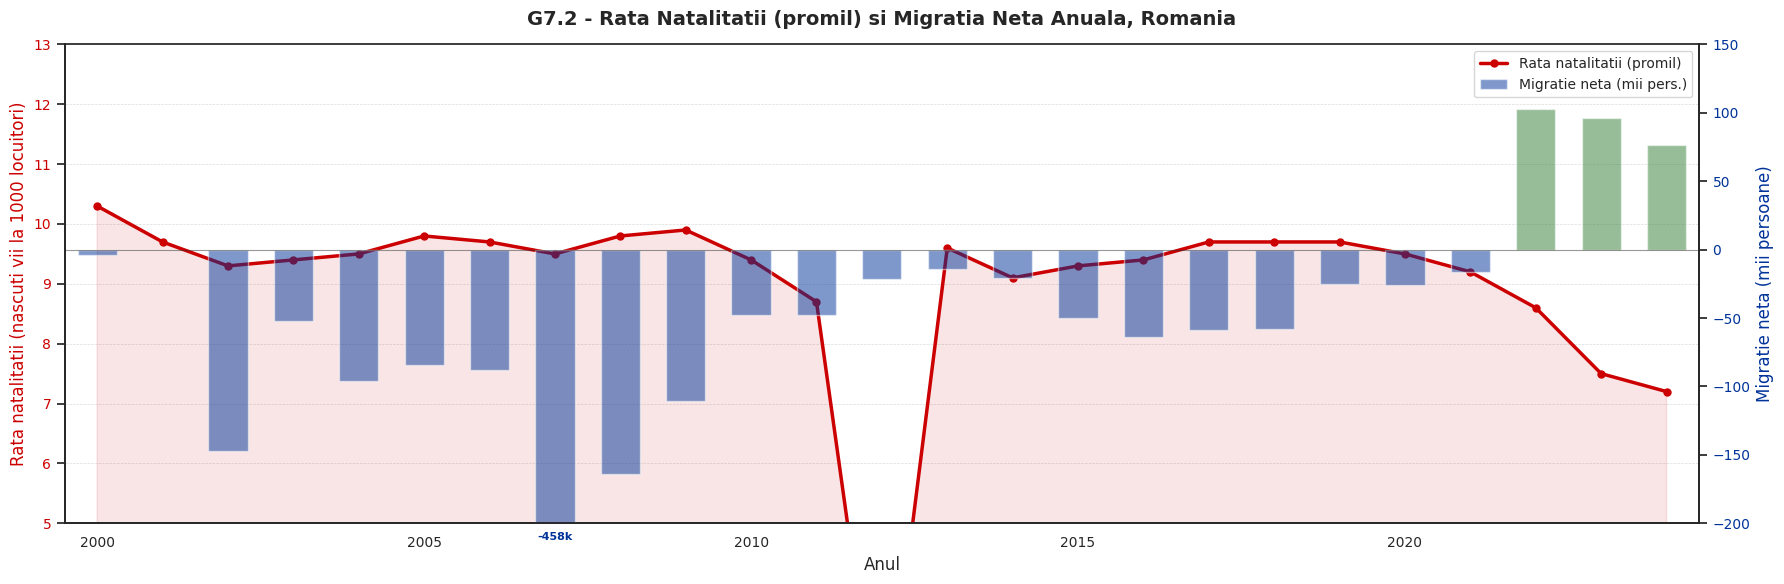

In [ ]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='white')

df_dm = df_demo.dropna(subset=['rata_natalitate_promil']).copy()
df_mig_clean = df_dm[df_dm['an'] != 2001].dropna(subset=['migratie_neta'])

ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.7)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

ax1.plot(df_dm['an'], df_dm['rata_natalitate_promil'],
         color=CUL['ro'], linewidth=2.5, marker='o', markersize=5,
         label='Rata natalitatii (promil)', zorder=4)
ax1.fill_between(df_dm['an'], df_dm['rata_natalitate_promil'],
                 alpha=0.10, color=CUL['ro'])
ax1.set_ylabel('Rata natalitatii (nascuti vii la 1000 locuitori)',
               color=CUL['ro'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=CUL['ro'], labelsize=10)
ax1.set_ylim(5, 13)

ax2 = ax1.twinx()

mig_vals = df_mig_clean['migratie_neta'] / 1000
culori_mig = [CUL['verde'] if v > 0 else CUL['ue'] for v in df_mig_clean['migratie_neta']]

# Clip valorile pentru afisare, pastrandu-le reale in date
mig_clip = mig_vals.clip(lower=-200)
ax2.bar(df_mig_clean['an'], mig_clip,
        color=culori_mig, alpha=0.50, width=0.6,
        label='Migratie neta (mii pers.)', zorder=2)

# Annotam barele taiate cu valoarea reala
for an, val_real, val_clip in zip(df_mig_clean['an'], mig_vals, mig_clip):
    if val_real < -200:
        ax2.annotate(f'{val_real:.0f}k',
                     xy=(an, -200),
                     xytext=(0, -12), textcoords='offset points',
                     ha='center', fontsize=8, color=CUL['ue'],
                     fontweight='bold')

ax2.axhline(y=0, color='#333333', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Migratie neta (mii persoane)', color=CUL['ue'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=CUL['ue'], labelsize=10)
ax2.set_ylim(-200, 150)
ax2.yaxis.grid(False)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
ax1.set_xlabel('Anul', fontsize=12)
ax1.set_title('G7.2 - Rata Natalitatii (promil) si Migratia Neta Anuala, Romania',
              fontsize=14, fontweight='bold', pad=14)
ax1.set_xlim(df_dm['an'].min() - 0.5, df_dm['an'].max() + 0.5)
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

### Interpretare G7.2 – Rata Natalității (promil) și Migrația Netă Anuală, România

Ultimul grafic al seriei demografice combină două forțe care modelează simultan
populația României: **câți oameni se nasc** și **câți pleacă sau vin**.
Împreună, ele explică de ce piramida vârstelor din G7.1 arată cum arată.

**Rata natalității: declin lent, apoi accelerat**
De la ≈ 10.3‰ în 2000, rata a oscilat relativ stabil în jurul a 9.5‰ timp de
aproape două decenii – un nivel deja sub pragul de înlocuire a generațiilor
(≈ 14‰ necesar pentru populație stabilă). Declinul dramatic apare **post-2020**:
rata coboară la **7.1‰ în 2023**, cel mai scăzut nivel din istoria modernă a
României. Factorii combinați: îmbătrânirea generațiilor fertile, emigrația femeilor
tinere, amânarea maternității și efectele economice ale pandemiei.

**Migrația netă negativă: sângerarea continuă (2000–2021)**
Barele albastre sunt aproape uniform sub zero pe toată perioada – România a
pierdut populație prin emigrație în fiecare an din ultimele două decenii.
**Vârful emigrației** se înregistrează în jurul aderării la UE și al crizei
financiare: eticheta **-458k** marchează cel mai sever an de pierdere netă
de populație prin migrație – aproape **jumătate de milion de persoane** într-un
singur an, un exod fără precedent în Europa postbelică.

**Ruptura din 2011–2013: efectul recensământului**
Căderea dramatică a liniei roșii în jurul anului 2011 reflectă parțial
**recalibrarea statistică** produsă de recensământul din 2011, care a evidențiat
că populația reală a României era cu ≈ 1.5–2 milioane mai mică decât estimările
oficiale anterioare – emigranții plecați nu fuseseră scoși din evidențe.
Rata natalității calculată la un numitor mai mic a produs o ajustare vizibilă în grafic.

**2022–2024: prima migrație netă pozitivă din serie (barele verzi)**
O premieră istorică: România devine pentru prima dată destinație netă de migrație.
Explicația principală – **refugiații ucraineni** după invazia din februarie 2022,
dar și imigrația economică din Asia de Sud-Est și Africa, atrasă de piața muncii
tensionată și de salariile în creștere. Această schimbare de semn nu compensează
deceniile de pierderi demografice, dar modifică structura populației.

**Concluzie – o criză demografică cu două motoare:**
România se confruntă simultan cu **natalitate în prăbușire** și **emigrație
structurală** – o combinație care explică pensionarea viitoare a sistemelor de
protecție socială și presiunea fiscală ireversibilă evidențiată în graficele G5.1–G5.5.
Inversarea recentă a migrației nete este încurajatoare, dar insuficientă pentru
a contrabalansa tendința demografică pe termen lung fără politici pro-natalitate
și de integrare a imigranților la scară mult mai mare decât în prezent.

#### G7.3 - Structura populației pe grupe de vârstă: 2003 vs. 2024

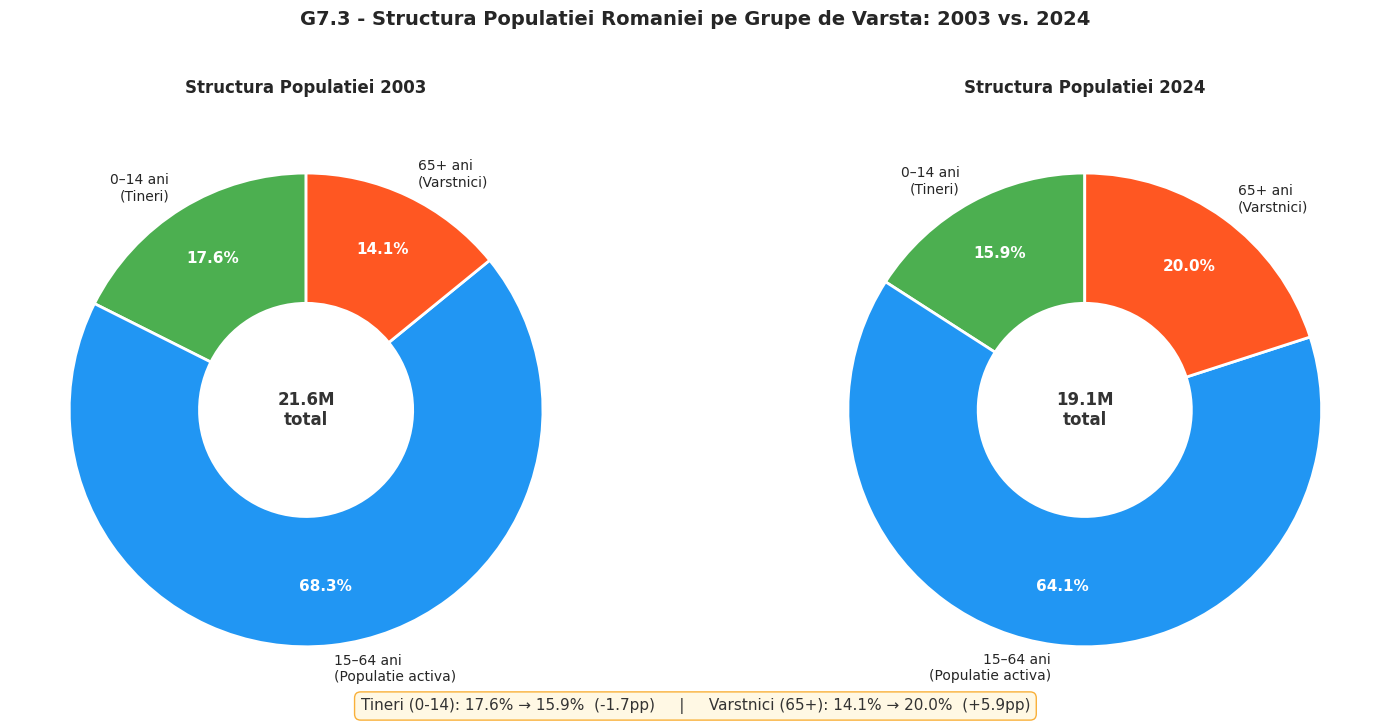

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set(style='white')

def grupeaza_varste(df_pop, an):
    df_an = df_pop[df_pop['an'] == an].copy()
    total = df_an['populatie'].sum()

    tineri = df_an[df_an['grupa_varsta'].isin(
        ['0-4','5-9','10-14'])]['populatie'].sum()
    activi = df_an[df_an['grupa_varsta'].isin(
        ['15-19','20-24','25-29','30-34','35-39',
         '40-44','45-49','50-54','55-59','60-64'])]['populatie'].sum()
    varstnici = df_an[df_an['grupa_varsta'].isin(
        ['65-69','70-74','75-79','80-84','85sipeste'])]['populatie'].sum()

    return [tineri/total*100, activi/total*100, varstnici/total*100]

culori_pie = ['#4CAF50', '#2196F3', '#FF5722']
etichete   = ['0–14 ani\n(Tineri)', '15–64 ani\n(Populatie activa)', '65+ ani\n(Varstnici)']

for idx, an_ref in enumerate([2003, 2024]):
    ax = axes[idx]
    valori = grupeaza_varste(df_pop, an_ref)

    wedges, texts, autotexts = ax.pie(
        valori,
        labels=etichete,
        colors=culori_pie,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10)
    )

    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    # FIX: eliminat // 2
    pop_total = df_pop[df_pop['an']==an_ref]['populatie'].sum()
    ax.text(0, 0, f'{pop_total/1e6:.1f}M\ntotal',
            ha='center', va='center', fontsize=12,
            fontweight='bold', color='#333333')

    ax.set_title(f'Structura Populatiei {an_ref}',
                 fontsize=12, fontweight='bold', pad=15)

val_2003 = grupeaza_varste(df_pop, 2003)
val_2024 = grupeaza_varste(df_pop, 2024)
delta_tineri    = val_2024[0] - val_2003[0]
delta_varstnici = val_2024[2] - val_2003[2]

fig.text(0.5, 0.02,
         f'Tineri (0-14): {val_2003[0]:.1f}% → {val_2024[0]:.1f}%  '
         f'({delta_tineri:+.1f}pp)     |     '
         f'Varstnici (65+): {val_2003[2]:.1f}% → {val_2024[2]:.1f}%  '
         f'({delta_varstnici:+.1f}pp)',
         ha='center', fontsize=11, color='#333333',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E1',
                   edgecolor='#F9A825', alpha=0.9))

fig.suptitle('G7.3 - Structura Populatiei Romaniei pe Grupe de Varsta: 2003 vs. 2024',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretare G7.3 – Structura Populației României pe Grupe de Vârstă: 2003 vs. 2024

Graficul sintetizează în format donut schimbările demografice structurale
surprinse în detaliu de G7.1 și G7.2 – reducând complexitatea piramidelor la
**trei cifre esențiale** per an, comparabile direct.

**România a pierdut 2.5 milioane de locuitori în 21 de ani**
De la **21.6M** (2003) la **19.1M** (2024) – o contracție de **≈ 11.6%** a
populației totale, un fenomen rar în Europa în timp de pace. Această pierdere
se datorează cumulat natalității sub pragul de înlocuire și emigrației nete
masive documentate în G7.2.

**"Foarfecele demografic" – tinerii scad, vârstnicii cresc:**

| Segment | 2003 | 2024 | Variație |
|---|---|---|---|
| Tineri (0–14 ani) | 17.6% | 15.9% | **-1.7 pp** |
| Populație activă (15–64 ani) | 68.3% | 64.1% | **-4.2 pp** |
| Vârstnici (65+ ani) | 14.1% | 20.0% | **+5.9 pp** |

Segmentul portocaliu (vârstnici) a crescut cu aproape **6 puncte procentuale**
– echivalentul a sute de mii de persoane în plus față de baza activă,
care ea însăși s-a redus. Segmentul verde (tineri) s-a contractat, confirmând
că baza de înlocuire a forței de muncă se erodează.

**Pragul de 20% vârstnici – un reper european**
Atingerea a **20% populație de 65+ ani** plasează România în categoria
societăților **oficial îmbătrânite** conform standardelor demografice internaționale,
aliniindu-se cu media UE (~21%). Spre deosebire de țările din Europa de Vest
care au ajuns la acest prag gradual pe parcursul a 50–70 de ani, România l-a
atins în ≈ 30 de ani – un ritm de îmbătrânire accelerat, cu mai puțin timp
pentru adaptarea instituțională.

**Raportul de dependență demografică: deteriorare semnificativă**
- 2003: ≈ **46 dependenți** la 100 persoane de vârstă activă
- 2024: ≈ **56 dependenți** la 100 persoane de vârstă activă

Această creștere de 10 puncte în 21 de ani înseamnă că fiecare persoană activă
susține o povară fiscală și socială mai mare – prin contribuții la pensii,
sănătate și servicii sociale – cu implicații directe asupra sustenabilității
deficitelor bugetare analizate în G5.1–G5.5.

**Concluzie – conexiunea macro-demografică:**
Graficele G7.1–G7.3 nu sunt un capitol separat, ci **cheia de interpretare**
a tuturor celorlalte. Deficitele fiscale mari, presiunea pe randamentele
obligațiunilor, cheltuielile sociale în creștere și dificultatea reformelor
structurale sunt toate amplificate de această realitate demografică: o populație
mai mică, mai bătrână și cu o bază activă în scădere relativă.

---
## 📌 PUNCTUL 4 - Dashboard Interactiv cu `ipywidgets` *(2p)*

Dashboard-ul permite explorarea a 6 indicatori macroeconomici cu control complet al perioadei, tipului de afișare și evidențierii erelor istorice.

**Controale disponibile:**
- `Dropdown` - Selectează indicatorul din 6 opțiuni
- `IntRangeSlider` - Interval de ani
- `RadioButtons` - Valori absolute vs. variație anuală (YoY)
- `ToggleButton` - Afișează / ascunde erele istorice
- `Button` + `Output` - Generează graficul


In [ ]:
# ── Configurare dashboard ────────────────────────────────────────
INDICATORI = {
    'Rata Inflației Anuale (%)': {
        'df': 'inflatie_anuala', 'col': 'rata_inflatie_pct',
        'xcol': 'an', 'ylabel': 'Rata inflației (%)',
        'tip': 'anual', 'culoare': CUL['ro']
    },
    'EUR/RON - Curs Zilnic': {
        'df': 'curs_valutar', 'col': 'eur_ron',
        'xcol': 'data', 'ylabel': 'EUR/RON',
        'tip': 'zilnic', 'culoare': CUL['ro']
    },
    'Deficit Bugetar România (% PIB)': {
        'df': 'deficit_bugetar', 'col': 'deficit_ro_pct',
        'xcol': 'an', 'ylabel': 'Deficit (% PIB)',
        'tip': 'anual', 'culoare': CUL['rosu']
    },
    'Datorie Publică România (% PIB)': {
        'df': 'datorie_publica', 'col': 'datorie_ro_pct',
        'xcol': 'an', 'ylabel': 'Datorie (% PIB)',
        'tip': 'anual', 'culoare': CUL['portoc']
    },
    'Randament Obligațiuni 10Y România (%)': {
        'df': 'randament_10y', 'col': 'rand_ro_pct',
        'xcol': 'data', 'ylabel': 'Randament 10Y (%)',
        'tip': 'lunar', 'culoare': CUL['ue']
    },
    'PMI Manufacturing Eurozonă': {
        'df': 'pmi_lunar', 'col': 'pmi_eurozona',
        'xcol': 'data', 'ylabel': 'PMI (indice)',
        'tip': 'lunar', 'culoare': CUL['gri']
    },
}

# Map nume df → variabilă Python
DF_MAP = {
    'inflatie_anuala': df_inflatie,
    'curs_valutar':    df_curs,
    'deficit_bugetar': df_deficit,
    'datorie_publica': df_datorie,
    'randament_10y':   df_rand,
    'pmi_lunar':       df_pmi,
}

print("✓ Dashboard configurat cu", len(INDICATORI), "indicatori.")

✓ Dashboard configurat cu 6 indicatori.


In [ ]:
# ── Construcție widget-uri ───────────────────────────────────────
st = {'description_width': 'initial'}
layout_w = pyw.Layout(width='420px')
layout_m = pyw.Layout(width='250px')

w_indicator = pyw.Dropdown(
    options=list(INDICATORI.keys()),
    description='📊 Indicator:',
    style=st, layout=layout_w
)

w_interval = pyw.IntRangeSlider(
    value=[2005, 2025],
    min=2000, max=2026, step=1,
    description='📅 Interval ani:',
    continuous_update=False,
    style=st, layout=layout_w
)

w_tip = pyw.RadioButtons(
    options=['Valori absolute', 'Variație YoY (%)'],
    description='📈 Tip afișare:',
    style=st, layout=layout_m
)

w_ere = pyw.ToggleButton(
    value=True,
    description='Afișează ere istorice',
    button_style='info',
    icon='check',
    layout=pyw.Layout(width='200px')
)

w_btn = pyw.Button(
    description='🔄 Generează grafic',
    button_style='primary',
    layout=pyw.Layout(width='200px')
)

w_err = pyw.Label(value='', style={'text_color': 'red'})
w_out = pyw.Output(layout={'border': '1px solid #e0e0e0', 'padding': '8px'})

# ── Funcție de afișare ───────────────────────────────────────────
def afisare_grafic(b=None):
    w_err.value = ''
    with w_out:
        w_out.clear_output(wait=True)

        cfg = INDICATORI[w_indicator.value]
        df_base = DF_MAP[cfg['df']].copy()
        xcol = cfg['xcol']
        col  = cfg['col']
        an_i, an_f = w_interval.value

        # Filtrare perioadă
        if xcol == 'an':
            df_f = df_base[(df_base['an'] >= an_i) & (df_base['an'] <= an_f)].dropna(subset=[col])
            x_vals = df_f['an']
        else:
            if xcol == 'data' and df_base[xcol].dtype == 'object':
                df_base[xcol] = pd.to_datetime(df_base[xcol])
            df_f = df_base[
                (df_base[xcol].dt.year >= an_i) & (df_base[xcol].dt.year <= an_f)
            ].dropna(subset=[col])
            x_vals = df_f[xcol]

        if len(df_f) < 2:
            w_err.value = '⚠ Date insuficiente pentru perioada selectată.'
            return

        y_vals = df_f[col].copy()
        ylabel = cfg['ylabel']

        # Variație YoY
        if w_tip.value == 'Variație YoY (%)':
            if xcol == 'an':
                y_vals = y_vals.pct_change() * 100
            else:
                y_vals = y_vals.pct_change(12) * 100
            ylabel = 'Variație anuală (%)'

        # Grafic
        fig, ax = plt.subplots(figsize=(15, 5))
        sns.set(style='whitegrid')

        ax.plot(x_vals, y_vals, color=cfg['culoare'], linewidth=2, zorder=4)
        ax.fill_between(x_vals, y_vals, alpha=0.12, color=cfg['culoare'])

        # Ere istorice
        if w_ere.value and xcol == 'an':
            for start, end, culoare, label in ERE:
                if end >= an_i and start <= an_f:
                    ax.axvspan(max(start, an_i), min(end, an_f), alpha=0.2, color=culoare, zorder=0)
                    mid = (max(start, an_i) + min(end, an_f)) / 2
                    ax.text(mid, ax.get_ylim()[1], label, ha='center', va='top',
                            fontsize=7, color='#666666', style='italic')

        # Linie zero
        if y_vals.min() < 0 < y_vals.max():
            ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.5)

        ax.set_xlabel('Perioada', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{w_indicator.value} ({an_i}–{an_f})', fontsize=13, fontweight='bold', pad=12)

        # Statistici în titlu secundar
        ax.set_xlabel(f'Min: {y_vals.min():.2f} | Max: {y_vals.max():.2f} | Medie: {y_vals.mean():.2f}', fontsize=9)

        plt.tight_layout()
        plt.show()

w_btn.on_click(afisare_grafic)
w_indicator.observe(afisare_grafic, names='value')

# ── Layout dashboard ──────────────────────────────────────────────
rand1 = pyw.HBox([w_indicator])
rand2 = pyw.HBox([w_interval])
rand3 = pyw.HBox([w_tip, pyw.VBox([w_ere, w_btn])])
rand4 = pyw.HBox([w_err])

dashboard = pyw.VBox([
    pyw.HTML('<h3 style="color:#CC0000">📊 Dashboard Macroeconomic România</h3>'),
    rand1, rand2, rand3, rand4, w_out
])
display(dashboard)
afisare_grafic()

## 📌 PUNCTUL 5 — Concluzii și Interpretări

### 5.1 Sinteza celor 4 acte narative

**Actul I (2000–2007) — Tranziția și ancora europeană**
România a demarat deceniul cu o inflație de 45.7%, un PIB nominal sub 40 mld. USD
și o datorie publică de ≈ 22% din PIB — paradoxal, cel mai solid indicator
fiscal al întregii perioade. Dezinflația structurală (-30 pp în 7 ani) și
disciplina fiscală impusă de procesul de aderare la UE au reprezentat cele
mai mari realizări ale perioadei. Aderarea din 2007 a declanșat convergența
accelerată, dar și dependența de capitaluri externe și primul val masiv de emigrație.

**Actul II (2008–2012) — Boom, criză și ajustare dureroasă**
Cheltuielile pro-ciclice pre-electorale din 2008 au amplificat șocul crizei
globale: deficitul a explodat la -9.5% din PIB în 2009, EUR/RON a sărit de la
3.35 la 4.25 în mai puțin de doi ani, iar PIB-ul real s-a contractat cu ≈ 7%.
România a trăit criza mai dur decât media europeană — vizibil în G1.2 prin
decalajul față de traiectoria Euro Area. Ajustarea a venit prin austeritate
impusă extern (FMI), nu printr-un consens intern privind sustenabilitatea fiscală.

**Actul III (2013–2020) — Consolidare fragilă și dividendul irosit**
Revenirea la creștere economică, reducerea inflației spre deflație (2015–2016),
șomajul la minimul istoric de 3.9% în 2019 și BET în expansiune continuă au
creat impresia unei stabilizări structurale. În realitate, fereastra fiscală
din 2013–2018 — singura perioadă de conformitate cu Maastricht din ultimul
deceniu — a fost irosită: majorările salariale din sectorul public post-2016
au generat un deficit structural de ≈ -3% chiar și în ani de boom,
România intrând în criza COVID fără niciun tampon fiscal.

**Actul IV (2021–2026) — Presiune maximă și vulnerabilitate acumulată**
Inflație record de 13.8% în 2022, dobândă BNR urcată la 7%, deficit bugetar
de -9.3% din PIB în 2024 (cel mai mare din UE), datorie publică apropiindu-se
de pragul Maastricht de 60% și natalitate prăbușită la 7.1‰. În contrast aparent
paradoxal: BET atinge 30.000 de puncte, rezervele BNR ajung la 78 mld. EUR,
salariul minim depășește 4.000 RON, iar PIB-ul nominal depășește 400 mld. USD.
România prezintă simultan indicatori de prosperitate nominală și vulnerabilități
structurale profunde — o tensiune care definește provocarea fundamentală a
următorului deceniu.

---

### 5.2 Top 8 Insights derivate direct din grafice

**1. Convergența PIB — reală, dar asimetrică** *(G1.2)*
România a ajuns de la ≈ 50% din indicele de volum al Euro Area în 2000 la ≈ 113%
în 2025 — o convergență remarcabilă în termeni absoluți. Însă graficul trimestrial
arată că România coboară mai abrupt în crize decât urcă în perioade de creștere —
semnul unei economii pro-ciclice, cu stabilizatori automați insuficienți și
fără marjă fiscală pentru politici contraciclic.

**2. Dezinflația — cea mai rapidă din Europa Centrală, urmată de recidivă** *(G2.1, G2.2, G2.3)*
De la 45.7% în 2000 la deflație (-1.5%) în 2016 — în doar 16 ani. Graficul KDE
*(G2.3)* revelează că această călătorie a transformat distribuția inflației
dintr-una larg asimetrică (cozi groase spre dreapta) într-una aproape normală,
concentrată în jurul lui zero. Șocul post-2021 a reîngroșat parțial cozile —
confirmând că dezinflația structurală nu este ireversibilă în absența
disciplinei fiscale și a independenței monetare depline.

**3. EUR/RON — ancoră artificială cu cost crescând** *(G3.1, G3.2)*
În timp ce EUR/HUF s-a depreciat cu ≈ 60% față de baza din 2005 și EUR/PLN
cu ≈ 7%, EUR/RON a depășit pragul de 5.0 abia în 2025 — o depreciere graduală
de ≈ 42% realizată aproape liniar. Box plot-ul anual confirmă că această
stabilitate excepțională este construită, nu naturală: cutiile din 2019–2025
sunt aproape invizibil de înguste, semn al intervenției permanente a BNR din
rezerve — al căror nivel record de 78 mld. EUR nu trebuie interpretat ca
dovadă de forță, ci și ca dimensiune a costului acestei politici.

**4. Piața muncii — transformare structurală cu doi motori opuși** *(G4.1–G4.4)*
Șomajul a scăzut de la 10.2% (2001) la 3.9% (2019) — partial prin crearea
de locuri de muncă, parțial prin emigrația a 3–4 milioane de români.
Jointplot-ul *(G4.4)* arată că relația inversă șomaj–salarii (r = -0.69)
începe să se decupleze în 2024: salarii record coexistă cu șomaj în creștere,
sugerând că piața muncii intră într-o fază de ajustare structurală, nu ciclică.

**5. Deficitul — problemă structurală, nu conjuncturală** *(G5.1, G5.5)*
Din cei 26 de ani analizați, România a respectat limita Maastricht de -3%
în doar **12 ani** — și de fiecare dată sub presiune externă (aderare UE sau
program FMI), nu dintr-un consens intern privind sustenabilitatea. Waffle chart-ul
*(G5.5)* vizualizează concis această realitate: două insule verzi separate de
zone roșii extinse, cu cea mai lungă perioadă de non-conformitate consecutivă
(2019–2025) tocmai în curs. Cauza profundă: cheltuieli sociale structurale
(pensii, salarii publice) neacoperite de venituri fiscale printre cele mai
scăzute din UE ca procent din PIB.

**6. Datoria publică — avantajul care se evaporă** *(G5.2, G5.4)*
România a intrat în criză cu datoria de 12% din PIB — cel mai mic nivel
din UE la acel moment. În 2025, se apropie de 60% (pragul Maastricht) cu
un deficit anual de ≈ 8–9%, ceea ce face depășirea pragului în 2026
aproape certă în absența corecțiilor. Radarql vulnerabilității *(G5.4)*
sintetizează paradoxul: singurul indicator favorabil față de UE-27 (datoria)
este și cel mai rapid în deteriorare.

**7. BVB — decuplare de ciclul european, ancorare în fluxuri structurale** *(G6.1, G6.2)*
Corelația practic nulă r = -0.19 între PMI Manufacturing Eurozonă și capitalizarea
BVB, combinată cu triplarea indicelui BET în condițiile unui PMI sub 50,
confirmă că BVB nu mai este un barometru al ciclului industrial european.
Promovarea la statutul de Emerging Market (FTSE, MSCI) a atras fluxuri de
capital indexat independente de conjunctură — o schimbare structurală cu
efecte pe termen lung, dar și cu risc de reversare bruscă în cazul unui
episod global de risk-off în piețele emergente.

**8. Criza demografică — multiplicatorul tuturor celorlalte vulnerabilități** *(G7.1–G7.3)*
Piramida vârstelor 2003 vs. 2024 și graficul donut arată o transformare
accelerată: populația totală -2.5 milioane, vârstnicii urcă de la 14.1% la
20.0%, tinerii scad de la 17.6% la 15.9%, iar natalitatea se prăbușește
la 7.1‰. Raportul de dependență demografică a crescut de la ≈ 46 la ≈ 56
dependenți per 100 activi în numai 21 de ani. Aceasta nu este o problemă
demografică izolată — este multiplicatorul care amplifică toate celelalte
vulnerabilități fiscale, salariale și de creștere identificate în analiză.

---

### 5.3 Limitele analizei

- Seria EUR/RON pornește din 2005 (disponibilitate date BCE), excluzând
  perioada de volatilitate maximă 2000–2004
- Câștigul salarial acoperă totalul economiei — diferențele sectoriale
  (IT vs. agricultură vs. construcții) rămân invizibile în G4.3
- Piramida vârstelor pornește din 2003 (limita datelor INS disponibile);
  decalajul față de datele recensământului 2011 introduce o discontinuitate
  statistică vizibilă în G7.2
- BET pornește din 2010 — criza bursieră din 2008–2009, când indicele a
  pierdut ≈ 70% din valoare, nu apare în graficul G6.1
- Corelația PMI–BVB *(G6.2)* este calculată pe medii anuale (≈ 20–21 puncte)
  — interval insuficient pentru concluzii statistice robuste; r = -0.19
  nu poate fi testat semnificativ la acest număr de observații
- Toți indicatorii nominali (PIB, salarii, BET) conțin efectul inflației și
  al deprecierii leului — comparațiile în termeni reali sau în EUR ar modifica
  parțial concluziile

---

### 5.4 Întrebări deschise generate de date

- Când va atinge EUR/RON pragul de 5.5 RON și cât va costa BNR menținerea
  sub el în condițiile unui deficit structural persistent?
- Poate România reduce deficitul bugetar la -3% fără tăieri sociale majore,
  în contextul presiunilor demografice ireversibile și al angajamentelor
  de pensii indexate?
- Va deveni BVB un barometru credibil al economiei românești pe măsură ce
  capitalizarea depășește 50% din PIB — sau rămâne o piață dominată de
  câteva companii de stat și fluxuri indexate?
- Inversarea recentă a migrației nete (2022–2024) este un trend structural
  sau un efect temporar al refugiaților ucraineni? Poate România deveni
  destinație de imigrație economică la scară semnificativă?
- Generația "Decretei" (acum 55–58 ani) va ieși la pensie în masă în
  2027–2032 — în ce măsură sistemul de pensii poate absorbi acest șoc
  fără o reformă fundamentală a parametrilor de eligibilitate?